# Charging analysis based on trajectory data

In [20]:
import cudf
import cupy as cp
import pandas as pd
import numpy as np
import os
from pathlib import Path
from scipy.spatial import cKDTree
from heapq import heappush, heappop
import pyarrow.parquet as pq
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm import tqdm
import logging
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium.plugins import MarkerCluster
import pickle
from sklearn.cluster import DBSCAN
import contextily as ctx
import geopandas as gpd

logging.basicConfig(level=logging.INFO, format="%(asctime)s | %(levelname)s | %(message)s")


In [21]:
# Haversine distance
def haversine_distance(lon1, lat1, lon2, lat2):
    lon1 = cp.asarray(lon1.values if hasattr(lon1, 'values') else lon1)
    lat1 = cp.asarray(lat1.values if hasattr(lat1, 'values') else lat1)
    lon2 = cp.asarray(lon2.values if hasattr(lon2, 'values') else lon2)
    lat2 = cp.asarray(lat2.values if hasattr(lat2, 'values') else lat2)

    lon1_rad = cp.radians(lon1.astype(cp.float64))
    lat1_rad = cp.radians(lat1.astype(cp.float64))
    lon2_rad = cp.radians(lon2.astype(cp.float64))
    lat2_rad = cp.radians(lat2.astype(cp.float64))

    dlon = lon2_rad - lon1_rad
    dlat = lat2_rad - lat1_rad
    a = cp.sin(dlat / 2)**2 + cp.cos(lat1_rad) * cp.cos(lat2_rad) * cp.sin(dlon / 2)**2
    c = 2 * cp.arcsin(cp.sqrt(a))
    R = 6371000
    return c * R


## Parameters


In [22]:
# parameters about identifying charing
R_STATION = 200          # distance to station (m）
T_STAY = 600             # min stay duration (second)
T_GAP = 300              # max time interval (seconds) between consecutive points in range of a station
PASSENGER_THR = 0        # idle

# parameters about energy
CAP_KWH = 82           # battery capacity（kWh）
CONS_KWH_PER_KM = 0.2   # consumption rate（kWh/km）
AVG_SPEED_KMH = 20       # （km/h）, used for lost data estimation
CHG_EFFICIENCY = 1.0     # actual charging percentage

MAX_GAP_SECONDS = 300   #The data loss time (seconds) is 10 minutes, otherwise ignore energy consumption

OUTPUT_DIR = 'output_v6'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# file path
TRACKS_DIR = '../data/taxi_trajectories.parquet'  # trajectory dict
STATION_CSV = 'station_information.csv'           # non-commercial station
COM_STATION_CSV = 'cent_stat_merge.csv'       # commercial station
PILE_CSV = 'pile_rated_power.csv'                 # piles
VEH_FILE =  f'{OUTPUT_DIR}/validid_filter.pkl'   #vehicle file

# output path
DIST_CHARGING_EVENTS_FILE = f'{OUTPUT_DIR}/distributed_charging_events.parquet'
CHAR_QUEUE_FILE = f'{OUTPUT_DIR}/char_queue.parquet'
ENERGY_CONS_FILE = f'{OUTPUT_DIR}/energy_consumption.parquet'
BATTERY_TRACE_FILE = f'{OUTPUT_DIR}/battery_trace.parquet'
CENT_CHARGING_EVENTS_FILE = f'{OUTPUT_DIR}/centralized_charging_events.parquet'
LOSS_EVENTS_FILE = f'{OUTPUT_DIR}/loss_events.parquet'
DISCOUNT_BATTERY_TRACE_FILE = f'{OUTPUT_DIR}/discount_battery_trace.parquet'
NEW_ENERGY_CONS_FILE = f'{OUTPUT_DIR}/new_energy_consumption.parquet'
HOME_CHARGING_EVENTS_FILE = f'{OUTPUT_DIR}/home_charging_events.parquet'

MAX_WORKERS = 8   # parallel processing


## non-commercial station data


In [23]:
stations_df = pd.read_csv(STATION_CSV, dtype={'station_id': np.int32})
piles_df = pd.read_csv(PILE_CSV, dtype={'station_id': np.int32, 'pile_id': np.int32})
# filter valid piles and stations
max_power = 60
valid_piles_df = piles_df[(piles_df['power'] > 0) & (piles_df['power'] <= max_power)].copy()

stat_pile_df = valid_piles_df.groupby('station_id').agg(
    num_piles=('power', 'count'),
    avg_power=('power', 'mean'),
    max_power=('power', 'max'),
    min_power=('power', 'min')
).reset_index()

# aggregation
stations_df = stations_df.merge(stat_pile_df, on='station_id', how='inner')
stations_df = stations_df[stations_df['num_piles'] > 0].copy()

print(f"there are {len(stations_df)} valid stations")


there are 1478 valid stations


In [5]:
len(stations_df)

1478

In [6]:
stations_df.to_csv('social public stations.csv', index=False)

In [7]:
stations_df.head(10)

,station_id,longitude,latitude,slow_count,fast_count,charge_count,TAZID,num_piles,avg_power,max_power,min_power
0,1001,113.784724,22.714121,20,0,20,559,20,7.000000,7.0,7.0
1,1002,113.785002,22.725900,22,0,22,558,22,7.000000,7.0,7.0
2,1003,113.787971,22.735538,6,0,6,558,6,7.000000,7.0,7.0
3,1004,113.788126,22.693449,6,5,11,596,11,31.090909,60.0,7.0
4,1006,113.790987,22.731351,10,0,10,594,20,7.000000,7.0,7.0
5,1008,113.791756,22.698816,38,6,44,596,44,14.227273,60.0,7.0
6,1013,113.796557,22.728199,28,0,28,594,28,7.000000,7.0,7.0
7,1014,113.802875,22.689785,12,0,12,598,12,7.000000,7.0,7.0
8,1015,113.804285,22.743436,12,0,12,587,12,7.000000,7.0,7.0
9,1016,113.806076,22.673562,22,0,22,553,22,7.000000,7.0,7.0


In [24]:

# KDTree of stations
station_coords = stations_df[['longitude', 'latitude']].to_numpy()
station_tree = cKDTree(station_coords)
station_id_lookup = stations_df['station_id'].to_numpy()


# All taxis to process

In [25]:
with open(VEH_FILE , 'rb') as f:
    all_taxiids = pickle.load(f)
logging.info(f"find {len(all_taxiids)} taxis")

2026-03-12 11:34:39,996 | INFO | find 15853 taxis


# commercial station

In [17]:
merged_stations = pd.read_csv(COM_STATION_CSV)
len(merged_stations)

695

# all station distribution

sz cent station: 695 sz dist stations: 1478


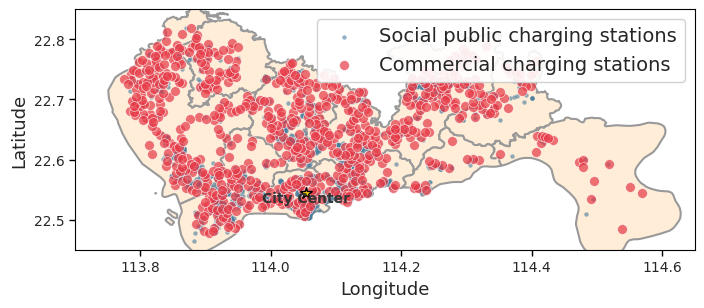

In [26]:
import matplotlib.ticker as ticker

sz_stations_df = merged_stations.copy()
print('sz cent station:', len(sz_stations_df),'sz dist stations:', len(stations_df))

def get_cols(df):
    lon = [c for c in df.columns if 'lon' in c.lower() or '经度' in c][0]
    lat = [c for c in df.columns if 'lat' in c.lower() or '纬度' in c][0]
    return lon, lat

s_lon, s_lat = get_cols(stations_df)
sz_lon, sz_lat = get_cols(sz_stations_df)

boundary_file = 'shenzhen_full.json'
url = 'https://geo.datav.aliyun.com/areas_v3/bound/440300_full.json'

if not os.path.exists(boundary_file):
    try:
        r = requests.get(url, timeout=15)
        if r.status_code == 200:
            with open(boundary_file, 'wb') as f:
                f.write(r.content)
    except:
        pass

roads_coords = [
    [(113.88, 22.54), (114.15, 22.54), (114.25, 22.55)],
    [(113.90, 22.57), (114.10, 22.58)],
    [(113.80, 22.68), (114.35, 22.72)],
    [(113.92, 22.50), (113.85, 22.75)],
    [(114.05, 22.53), (114.04, 22.75)],
    [(114.12, 22.55), (114.12, 22.65)],
    [(114.22, 22.55), (114.30, 22.75)],
    [(113.80, 22.60), (114.00, 22.62)],
]
#main_roads = gpd.GeoDataFrame(geometry=[LineString(r) for r in roads_coords])

aspect = np.cos(np.radians(22.65))
fig, ax = plt.subplots(figsize=(8, 8 * aspect)) # 宽16，高自动适应

# (A) base
if os.path.exists(boundary_file):
    sz_map = gpd.read_file(boundary_file)

    sz_map.plot(ax=ax, color='#FFEDD8', edgecolor='#999999', linewidth=1.5, zorder=1)
else:
    print("fail to find, replace with rectangle")
    ax.set_facecolor('#FFEDD8')

# (B) plot main roads
#main_roads.plot(ax=ax, color='#888888', linewidth=2, alpha=0.6, zorder=2)

# (C) plot stations
# commercial
ax.scatter(stations_df[s_lon], stations_df[s_lat],
           c='#457B9D', s=10, alpha=0.6,
           edgecolors='white', linewidths=0.01,zorder=1,
           label='Social public charging stations')

# non-commercial
ax.scatter(sz_stations_df[sz_lon], sz_stations_df[sz_lat],
           c='#E63946', s=50, alpha=0.7,
           edgecolors='white', linewidths=0.5,
           label='Commercial charging stations', zorder=4)

# (D) City Center
ax.text(114.055, 22.53, 'City Center', fontsize=10, fontweight='bold',
        ha='center', color='#333333', zorder=5)
ax.plot(114.055, 22.545, marker='*', color='gold', markersize=9, markeredgecolor='black', zorder=4)

# (E) scale setting
ax.set_xlim(113.70, 114.65)
ax.set_ylim(22.45, 22.85)
ax.set_aspect(aspect)


for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')

ax.tick_params(axis='both', which='major', labelsize=10, direction='out', length=4, width=1, color='black',bottom=True, left=True, labelbottom=True, labelleft=True)
ax.set_xlabel('Longitude', fontsize=13)
ax.set_ylabel('Latitude', fontsize=13)
# (F) decoration
#ax.set_title('Distribution of Taxi Charging Stations in Shenzhen', fontsize=18, pad=20)
ax.legend(loc='upper right', fontsize=14, frameon=True, facecolor='white', framealpha=0.9)
ax.axis('on')
ax.grid(False)
ax.set_facecolor('white')

plt.show()

sz cent station: 695 sz dist stations: 1478


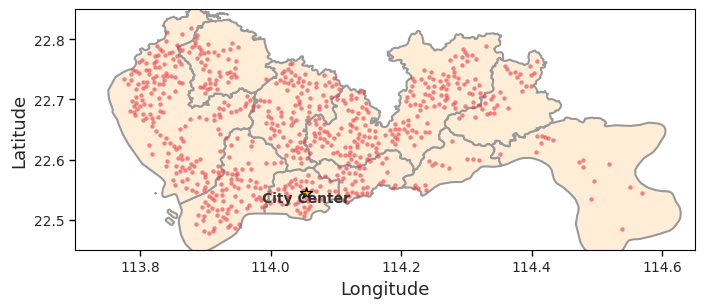

In [27]:
import matplotlib.ticker as ticker

sz_stations_df = merged_stations.copy()
print('sz cent station:', len(sz_stations_df),'sz dist stations:', len(stations_df))

def get_cols(df):
    lon = [c for c in df.columns if 'lon' in c.lower() or '经度' in c][0]
    lat = [c for c in df.columns if 'lat' in c.lower() or '纬度' in c][0]
    return lon, lat

s_lon, s_lat = get_cols(stations_df)
sz_lon, sz_lat = get_cols(sz_stations_df)

boundary_file = 'shenzhen_full.json'
url = 'https://geo.datav.aliyun.com/areas_v3/bound/440300_full.json'

if not os.path.exists(boundary_file):
    try:
        r = requests.get(url, timeout=15)
        if r.status_code == 200:
            with open(boundary_file, 'wb') as f:
                f.write(r.content)
    except:
        pass

roads_coords = [
    [(113.88, 22.54), (114.15, 22.54), (114.25, 22.55)],
    [(113.90, 22.57), (114.10, 22.58)],
    [(113.80, 22.68), (114.35, 22.72)],
    [(113.92, 22.50), (113.85, 22.75)],
    [(114.05, 22.53), (114.04, 22.75)],
    [(114.12, 22.55), (114.12, 22.65)],
    [(114.22, 22.55), (114.30, 22.75)],
    [(113.80, 22.60), (114.00, 22.62)],
]
#main_roads = gpd.GeoDataFrame(geometry=[LineString(r) for r in roads_coords])

aspect = np.cos(np.radians(22.65))
fig, ax = plt.subplots(figsize=(8, 8 * aspect)) # 宽16，高自动适应

# (A) base
if os.path.exists(boundary_file):
    sz_map = gpd.read_file(boundary_file)

    sz_map.plot(ax=ax, color='#FFEDD8', edgecolor='#999999', linewidth=1.5, zorder=1)
else:
    print("fail to find, replace with rectangle")
    ax.set_facecolor('#FFEDD8')

# (B) plot main roads
#main_roads.plot(ax=ax, color='#888888', linewidth=2, alpha=0.6, zorder=2)

# (C) plot stations
# commercial
# ax.scatter(stations_df[s_lon], stations_df[s_lat],
#            c='#457B9D', s=50, alpha=0.7,
#            edgecolors='white', linewidths=0.5,
#            label='Social public charging stations', zorder=3)

# non-commercial
ax.scatter(sz_stations_df[sz_lon], sz_stations_df[sz_lat],
           c='#E63946', s=10, alpha=0.6,
           edgecolors='white', linewidths=0.01, zorder=1)
           #label='Commercial charging stations',)

# (D) City Center
ax.text(114.055, 22.53, 'City Center', fontsize=10, fontweight='bold',
        ha='center', color='#333333', zorder=5)
ax.plot(114.055, 22.545, marker='*', color='gold', markersize=9, markeredgecolor='black', zorder=4)

# (E) scale setting
ax.set_xlim(113.70, 114.65)
ax.set_ylim(22.45, 22.85)
ax.set_aspect(aspect)


for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')

ax.tick_params(axis='both', which='major', labelsize=10, direction='out', length=4, width=1, color='black',bottom=True, left=True, labelbottom=True, labelleft=True)
ax.set_xlabel('Longitude', fontsize=13)
ax.set_ylabel('Latitude', fontsize=13)
# (F) decoration
#ax.set_title('Distribution of Taxi Charging Stations in Shenzhen', fontsize=18, pad=20)
#ax.legend(loc='upper right', fontsize=14, frameon=True, facecolor='white', framealpha=0.9)
ax.axis('on')
ax.grid(False)
ax.set_facecolor('white')

plt.show()

# Potential charging at centralized station

# GPS loss events

In [28]:
def detect_GPS_loss(taxiid, tracks_dir, gap_threshold=1800):
    try:
        # read trajectory data
        track_path = os.path.join(tracks_dir, f'taxiid={taxiid}')
        if not os.path.exists(track_path):
            return pd.DataFrame()

        track_files = list(Path(track_path).glob('*.parquet'))
        if not track_files:
            return pd.DataFrame()

        track = pd.concat([pd.read_parquet(f) for f in track_files], ignore_index=True)
        track = track.sort_values('time').reset_index(drop=True)

        if track.empty or len(track) < 2:
            return pd.DataFrame()

        # gap duration
        track['prev_time'] = track['time'].shift()
        track['prev_lon'] = track['lon'].shift()
        track['prev_lat'] = track['lat'].shift()
        track['dt'] = (track['time'] - track['prev_time']).dt.total_seconds()

        #gap duration  >= gap_threshold
        long_gaps = track[track['dt'] >= gap_threshold].copy()

        if long_gaps.empty:
            return pd.DataFrame()

        loss_events = []
        for idx, row in long_gaps.iterrows():
            loss_events.append({
                'taxiid': taxiid,
                'start_time': row['prev_time'],
                'end_time': row['time'],
                'duration_s': row['dt'],
                'start_lon': row['prev_lon'],
                'start_lat': row['prev_lat']
            })

        return pd.DataFrame(loss_events)

    except Exception as e:
        logging.error(f"erroe;{e} for {taxiid}")
        return pd.DataFrame()


def batch_detect_loss_events(all_taxiids, tracks_dir, output_file, gap_threshold=1800, max_workers=8):
    """

    """
    if os.path.exists(output_file):
        logging.info(f"{output_file} already exists")
        return pd.read_parquet(output_file)

    from concurrent.futures import ThreadPoolExecutor, as_completed

    all_loss_events = []

    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        futures = {
            executor.submit(detect_GPS_loss, tid, tracks_dir, gap_threshold): tid
            for tid in all_taxiids
        }

        for future in tqdm(as_completed(futures), total=len(futures), desc="检测专用站充电事件"):
            taxiid = futures[future]
            try:
                result = future.result()
                if not result.empty:
                    all_loss_events.append(result)
            except Exception as e:
                logging.error(f"车辆 {taxiid} 处理失败: {e}")

    if all_loss_events:
        loss_events_df = pd.concat(all_loss_events, ignore_index=True)
        loss_events_df = loss_events_df.sort_values(['taxiid', 'start_time']).reset_index(drop=True)
        loss_events_df.to_parquet(output_file, index=False)
        logging.info(f"find {len(loss_events_df)} GPS loss enents, \
        covering {loss_events_df['taxiid'].nunique()} taxis,saved to {output_file}")
    else:
        logging.warning("No GPS loss events found")
        loss_events_df = pd.DataFrame()

    return loss_events_df

In [29]:
# get GPS loss events
if os.path.exists(LOSS_EVENTS_FILE):
    loss_events_df = pd.read_parquet(LOSS_EVENTS_FILE)
    loss_events_df = loss_events_df[loss_events_df['taxiid'].isin(all_taxiids)].copy()
    logging.info(f"find {len(loss_events_df)} GPS loss events,covering {loss_events_df['taxiid'].nunique()} taxis")

else:
    GAP_THRESHOLD = 1800
    loss_events_df = batch_detect_loss_events(
        all_taxiids,
        TRACKS_DIR,
        LOSS_EVENTS_FILE,
        gap_threshold=GAP_THRESHOLD
    )
    loss_events_df = loss_events_df[loss_events_df['taxiid'].isin(all_taxiids)].copy()
    if not loss_events_df.empty:
        logging.info(f"find {len(loss_events_df)} GPS loss events, \
        covering {loss_events_df['taxiid'].nunique()} taxis")


2026-03-12 11:35:11,954 | INFO | find 315906 GPS loss events,covering 15853 taxis


# Identify charging events at commercial(centralized) stations

# pre-process

In [30]:
# Define Shenzhen bounding box
SZ_BBOX = {
    'lon_min': 113.7,
    'lon_max': 114.7,
    'lat_min': 22.45,
    'lat_max': 22.85
}

# Filter vehicles - keep only those with all events within Shenzhen
loss_events_df['in_sz'] = (
    loss_events_df['start_lon'].between(SZ_BBOX['lon_min'], SZ_BBOX['lon_max']) &
    loss_events_df['start_lat'].between(SZ_BBOX['lat_min'], SZ_BBOX['lat_max']))

vehicles_with_outside_events = loss_events_df[~loss_events_df['in_sz']]['taxiid'].unique().tolist()
filtered_loss_events  = loss_events_df[~loss_events_df['taxiid'].isin(vehicles_with_outside_events)]
valid_vehicles = filtered_loss_events['taxiid'].unique().tolist()
print(f"Filtered vehicles: {len(valid_vehicles)}")
print(f"Filtered loss events: {len(filtered_loss_events)}")

# process stations
sz_stations_df = pd.read_csv('matched_stations_info.csv')
sz_station_coords = sz_stations_df[['lon','lat']].values
sz_station_tree = cKDTree(sz_station_coords)
sz_station_ids =  sz_stations_df['station_id'].values


Filtered vehicles: 15853
Filtered loss events: 315906


In [15]:
# all_taxiids = valid_vehicles.copy()

# features of GPS loss events in Shenzhen

In [ ]:
def haversine_np(lon1, lat1, lon2, lat2):
    """Calculate distance in meters for inputs in DEGREES"""
    R = 6371000
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    return R * 2 * np.arcsin(np.sqrt(a))

# 1. Load & Prep Data
loss_events_df = filtered_loss_events.copy()
# Ensure input to DBSCAN is [lat, lon]
coords_lat_lon = loss_events_df[['start_lat', 'start_lon']].values

BATCH_SIZE = 50000
EPS_RAD = 500 / 6371000
MIN_SAMPLES = 3

# Shenzhen Boundary
SZ_BBOX = {'lon_min': 113.7, 'lon_max': 114.7, 'lat_min': 22.4, 'lat_max': 22.9}

batch_cluster_centers = []
total_noise = 0

# 2. Batch Clustering
n_batches = (len(coords_lat_lon) + BATCH_SIZE - 1) // BATCH_SIZE
print(f"Processing {len(coords_lat_lon)} events in {n_batches} batches...")

for i in range(n_batches):
    start = i * BATCH_SIZE
    end = min((i + 1) * BATCH_SIZE, len(coords_lat_lon))
    batch_coords = coords_lat_lon[start:end] # [lat, lon]

    # DBSCAN (metric='haversine' expects [lat, lon] in radians)
    db = DBSCAN(eps=EPS_RAD, min_samples=MIN_SAMPLES, metric='haversine', algorithm='ball_tree')
    labels = db.fit_predict(np.radians(batch_coords))

    total_noise += (labels == -1).sum()

    # Calculate centers for this batch
    unique_labels = set(labels)
    unique_labels.discard(-1)

    for label in unique_labels:
        mask = (labels == label)
        points = batch_coords[mask] # [lat, lon]

        mean_lat = points[:, 0].mean()
        mean_lon = points[:, 1].mean()

        # Filter: Keep only centers within Shenzhen
        if (SZ_BBOX['lon_min'] <= mean_lon <= SZ_BBOX['lon_max'] and
            SZ_BBOX['lat_min'] <= mean_lat <= SZ_BBOX['lat_max']):

            # Store as [lon, lat] for consistency
            batch_cluster_centers.append([mean_lon, mean_lat])

print(f"Found {len(batch_cluster_centers)} valid cluster centers in Shenzhen.")



In [61]:
# 3. Merge Nearby Centers (Global)
if len(batch_cluster_centers) > 0:
    batch_centers_arr = np.array(batch_cluster_centers) # [lon, lat]

    # Convert to [lat, lon] radians for merging
    centers_rad = np.radians(batch_centers_arr[:, [1, 0]])

    # Merge centers within 200m
    MERGE_EPS = 200 / 6371000
    db_merge = DBSCAN(eps=MERGE_EPS, min_samples=1, metric='haversine', algorithm='ball_tree')
    merge_labels = db_merge.fit_predict(centers_rad)

    final_centers = []
    unique_merge_labels = set(merge_labels)

    for label in unique_merge_labels:
        mask = (merge_labels == label)
        points = batch_centers_arr[mask] # [lon, lat]

        mean_lon = points[:, 0].mean()
        mean_lat = points[:, 1].mean()
        final_centers.append([mean_lon, mean_lat])

    cluster_centers = np.array(final_centers)
    print(f"Final merged cluster centers: {len(cluster_centers)}")

else:
    cluster_centers = np.array([])
    print("No valid clusters found.")

Final merged cluster centers: 821


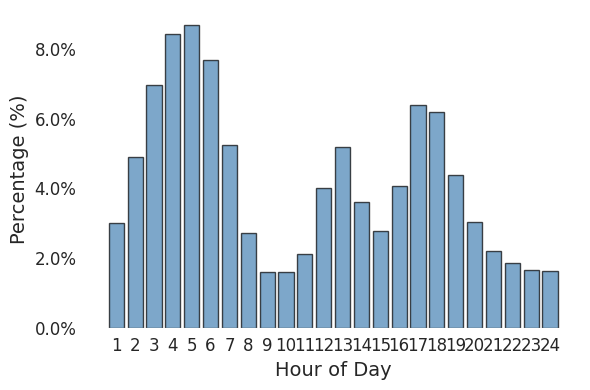

In [129]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

# 1. Load Data
df = pd.read_parquet(LOSS_EVENTS_FILE)

# 2. Process Data
# Convert to datetime and extract hour
df['hour'] = pd.to_datetime(df['start_time']).dt.hour
# Count and sort
hourly_counts = df['hour'].value_counts().sort_index()
# Calculate Percentage
hourly_pct = (hourly_counts / len(df)) * 100

# Shift index from 0-23 to 1-24
hourly_pct.index = hourly_pct.index + 1

# === Font Size Settings ===
TITLE_SIZE = 14
LABEL_SIZE = 14
TICK_SIZE  = 12
# ==========================

# 3. Plot setup (Force white background)
fig, ax = plt.subplots(figsize=(6, 4), facecolor='white')
ax.set_facecolor('white')

# 4. Draw Bars
ax.bar(hourly_pct.index, hourly_pct.values, color='steelblue', edgecolor='black', alpha=0.7)

# 5. Formatting
#ax.set_title('Temporal Distribution of GPS Loss Events (24h)', fontsize=TITLE_SIZE)
ax.set_xlabel('Hour of Day', fontsize=LABEL_SIZE)
ax.set_ylabel('Percentage (%)', fontsize=LABEL_SIZE)

# X-axis settings: 1 to 24
ax.set_xticks(range(1, 25))
ax.tick_params(axis='both', labelsize=TICK_SIZE)

# Y-axis settings: Percentage format
ax.yaxis.set_major_formatter(PercentFormatter(decimals=1))

# Remove grid for pure white, or keep light grid if preferred (comment out next line to remove grid completely)
#ax.grid(axis='y', linestyle='--', alpha=0.3, color='gray')

# Remove top and right spines for cleaner look
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

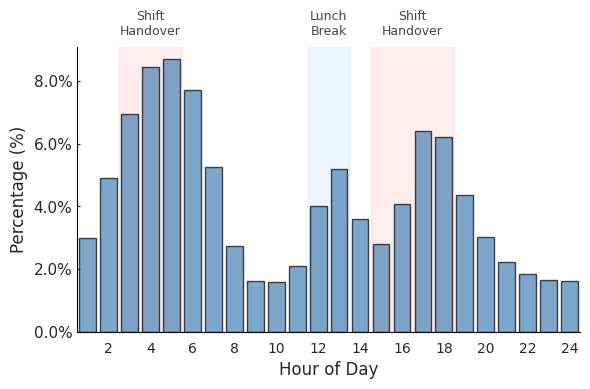

In [131]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

# 1. Load Data
df = pd.read_parquet(LOSS_EVENTS_FILE)

# 2. Process Data
df['hour'] = pd.to_datetime(df['start_time']).dt.hour
hourly_counts = df['hour'].value_counts().sort_index()
hourly_pct = (hourly_counts / len(df)) * 100
hourly_pct.index = hourly_pct.index + 1

# === Font Size Settings ===
TITLE_SIZE = 12
LABEL_SIZE = 12
TICK_SIZE  = 11
# ==========================

# 3. Plot setup
fig, ax = plt.subplots(figsize=(6, 4), facecolor='white')
ax.set_facecolor('white')

# 4. Highlight time periods (draw first so bars sit on top)
periods = [
    (2.5, 5.5,  '#ffcccc', 'Shift\nHandover'),
    (11.5, 13.5, '#cce5ff', 'Lunch\nBreak'),
    (14.5, 18.5, '#ffcccc', 'Shift\nHandover'),
]
y_top = hourly_pct.max() * 1.08
for x0, x1, color, label in periods:
    ax.axvspan(x0, x1, color=color, alpha=0.35, zorder=0)
    ax.text((x0 + x1) / 2, y_top, label,
            ha='center', va='bottom', fontsize=9, color='#444444')

# 5. Draw Bars
ax.bar(hourly_pct.index, hourly_pct.values,
       color='steelblue', edgecolor='black', alpha=0.7, zorder=2)

# 6. Formatting
ax.set_xlabel('Hour of Day', fontsize=LABEL_SIZE)
ax.set_ylabel('Percentage (%)', fontsize=LABEL_SIZE)

ax.set_xticks(range(2, 25, 2))
ax.set_xlim(0.5, 24.5)
#ax.tick_params(axis='both', labelsize=TICK_SIZE)
ax.tick_params(axis='y', which='both', direction='in', length=2, width=0.8, labelsize=TICK_SIZE, left = True)
ax.yaxis.set_major_formatter(PercentFormatter(decimals=1))

ax.spines['top'].set_visible(True)
ax.spines['right'].set_visible(True)
ax.spines['left'].set_linewidth(0.8)
ax.spines['bottom'].set_linewidth(0.8)
ax.spines['left'].set_color('black')
ax.spines['bottom'].set_color('black')
ax.grid(False)

plt.tight_layout()
plt.show()

In [102]:
import folium

# Create map
m = folium.Map(location=[22.6, 114.2], zoom_start=11, tiles='OpenStreetMap')

# 1. Draw Bounding Box (Blue Rectangle)
bounds = [[SZ_BBOX['lat_min'], SZ_BBOX['lon_min']],
          [SZ_BBOX['lat_max'], SZ_BBOX['lon_max']]]
folium.Rectangle(
    bounds=bounds,
    color="blue",
    weight=2,
    fill=False,
    popup="Valid Range"
).add_to(m)

# 2. Draw Stations (Green Circles, Hollow)
for _, row in merged_stations.iterrows():
    folium.CircleMarker(
        location=[row['lat'], row['lon']],
        radius=4,
        color='green',
        fill=False,  # Hollow
        weight=2,
        popup=f"Station {row.get('station_id', 'N/A')}"
    ).add_to(m)

# 3. Draw Cluster Centers (Red Circles, Hollow)
for i, center in enumerate(cluster_centers):
    folium.CircleMarker(
        location=[center[1], center[0]], # [lat, lon]
        radius=4,
        color='red',
        fill=False,  # Hollow
        weight=2,
        popup=f"Cluster {i+1}"
    ).add_to(m)

print(f"Map contains: {len(cluster_centers)} clusters, {len(merged_stations)} stations")
m

Map contains: 821 clusters, 695 stations


Stations: 695 -> 695 (inside SZ)
Clusters: 821 -> 779 (inside SZ)


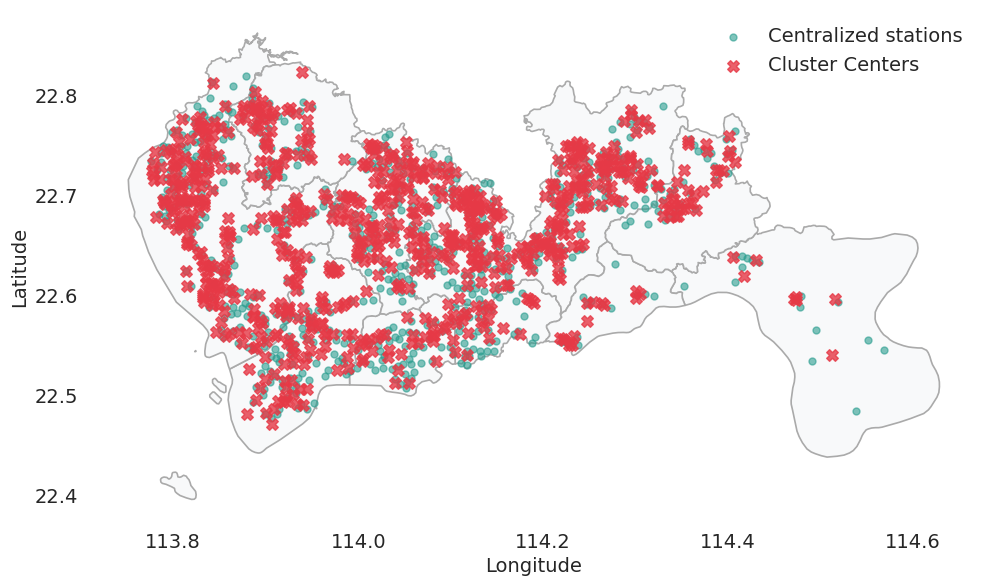

In [131]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import geopandas as gpd
import requests
import os
from shapely.geometry import Point

# 1. Get Shenzhen Boundary
boundary_file = 'shenzhen_full.json'
url = 'https://geo.datav.aliyun.com/areas_v3/bound/440300_full.json'

if not os.path.exists(boundary_file):
    try:
        print("Downloading Shenzhen boundary...")
        r = requests.get(url, timeout=15)
        if r.status_code == 200:
            with open(boundary_file, 'wb') as f:
                f.write(r.content)
    except:
        pass

# Load map
if os.path.exists(boundary_file):
    sz_map = gpd.read_file(boundary_file)
else:
    print("Error: Boundary file not found.")
    # Create a dummy map if download fails (optional fallback)
    # sz_map = gpd.GeoDataFrame(...)

# 2. Prepare Data & Filter Points Inside Shenzhen
# Convert Stations to GeoDataFrame
stations_gdf = gpd.GeoDataFrame(
    merged_stations,
    geometry=gpd.points_from_xy(merged_stations.lon, merged_stations.lat),
    crs="EPSG:4326"
)

# Convert Cluster Centers to GeoDataFrame
# Ensure cluster_centers is a DataFrame with 'lon', 'lat'
if isinstance(cluster_centers, np.ndarray):
    cluster_df = pd.DataFrame(cluster_centers, columns=['lon', 'lat'])
else:
    cluster_df = pd.DataFrame(cluster_centers, columns=['lon', 'lat'])

clusters_gdf = gpd.GeoDataFrame(
    cluster_df,
    geometry=gpd.points_from_xy(cluster_df.lon, cluster_df.lat),
    crs="EPSG:4326"
)

# --- KEY STEP: Spatial Join to Filter Points ---
# Only keep points that are within the Shenzhen polygon
stations_in_sz = gpd.clip(stations_gdf, sz_map)
clusters_in_sz = gpd.clip(clusters_gdf, sz_map)

print(f"Stations: {len(stations_gdf)} -> {len(stations_in_sz)} (inside SZ)")
print(f"Clusters: {len(clusters_gdf)} -> {len(clusters_in_sz)} (inside SZ)")

# 3. Plotting
aspect = np.cos(np.radians(22.65))
fig, ax = plt.subplots(figsize=(10, 10 * aspect), facecolor='white')

# Draw Map Background (White/Light)
sz_map.plot(ax=ax, color='#f8f9fa', edgecolor='#aaaaaa', linewidth=1.2, zorder=1)

# Draw Stations (Teal dots)
ax.scatter(stations_in_sz.geometry.x, stations_in_sz.geometry.y,
           c='#2a9d8f', s=25, alpha=0.6,
           label=f'Centralized stations',
           zorder=2)

# Draw Cluster Centers (Red X)
ax.scatter(clusters_in_sz.geometry.x, clusters_in_sz.geometry.y,
           c='#e63946', s=70, alpha=0.8, marker='X',
           label=f'Cluster Centers',
           zorder=3)

# 4. Formatting
#ax.set_title('Clusters vs. Stations in Shenzhen', fontsize=16, fontweight='bold', pad=15)
ax.legend(loc='upper right', fontsize=14, frameon=False, facecolor='white', framealpha=0, shadow=False)

# Clean axis
ax.set_xlabel('Longitude',fontsize=14)
ax.set_ylabel('Latitude',fontsize=14)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_facecolor('white')
ax.tick_params(axis='both', which='major', labelsize=14)
# Remove grid
ax.grid(False)

plt.tight_layout()
plt.show()

Stations: 695 -> 695 (inside SZ)
Clusters: 821 -> 779 (inside SZ)
Zoom center (Futian CBD): (113.81, 22.69)
Window: 5×5 km
Zoom region — Stations: 21, Clusters: 36
Cluster→Station distance: mean=464m, range=, 888m]


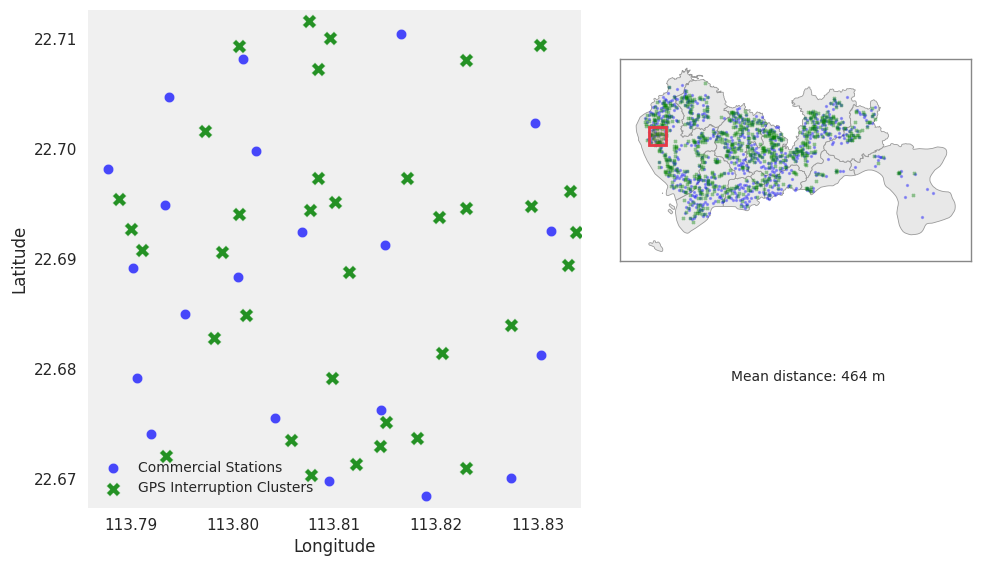

In [120]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import geopandas as gpd
import requests
import os
from shapely.geometry import Point
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.patches import Rectangle
from scipy.spatial import cKDTree

# 1. Get Shenzhen Boundary
boundary_file = 'shenzhen_full.json'
url = 'https://geo.datav.aliyun.com/areas_v3/bound/440300_full.json'

if not os.path.exists(boundary_file):
    try:
        print("Downloading Shenzhen boundary...")
        r = requests.get(url, timeout=15)
        if r.status_code == 200:
            with open(boundary_file, 'wb') as f:
                f.write(r.content)
    except:
        pass

if os.path.exists(boundary_file):
    sz_map = gpd.read_file(boundary_file)
else:
    raise FileNotFoundError("Boundary file not found.")

# 2. Prepare Data & Filter Points Inside Shenzhen
stations_gdf = gpd.GeoDataFrame(
    merged_stations,
    geometry=gpd.points_from_xy(merged_stations.lon, merged_stations.lat),
    crs="EPSG:4326"
)

if isinstance(cluster_centers, np.ndarray):
    cluster_df = pd.DataFrame(cluster_centers, columns=['lon', 'lat'])
else:
    cluster_df = pd.DataFrame(cluster_centers, columns=['lon', 'lat'])

clusters_gdf = gpd.GeoDataFrame(
    cluster_df,
    geometry=gpd.points_from_xy(cluster_df.lon, cluster_df.lat),
    crs="EPSG:4326"
)

stations_in_sz = gpd.clip(stations_gdf, sz_map)
clusters_in_sz = gpd.clip(clusters_gdf, sz_map)

print(f"Stations: {len(stations_gdf)} -> {len(stations_in_sz)} (inside SZ)")
print(f"Clusters: {len(clusters_gdf)} -> {len(clusters_in_sz)} (inside SZ)")

# ============================================================
# 3. Fixed zoom: Shenzhen city center (Futian CBD), 5×5 km
# ============================================================
SZ_LAT = np.radians(22.6)
half_lon = 2500 / (111320 * np.cos(SZ_LAT))  # 2.5 km -> degrees lon
half_lat = 2500 / 110574                       # 2.5 km -> degrees lat

cx, cy = 113.81, 22.69  # Futian CBD / Civic Center

zoom_lon_min, zoom_lon_max = cx - half_lon, cx + half_lon
zoom_lat_min, zoom_lat_max = cy - half_lat, cy + half_lat

stations_zoom = stations_in_sz.cx[zoom_lon_min:zoom_lon_max, zoom_lat_min:zoom_lat_max]
clusters_zoom = clusters_in_sz.cx[zoom_lon_min:zoom_lon_max, zoom_lat_min:zoom_lat_max]

print(f"Zoom center (Futian CBD): ({cx}, {cy})")
print(f"Window: 5×5 km")
print(f"Zoom region — Stations: {len(stations_zoom)}, Clusters: {len(clusters_zoom)}")

# ============================================================
# 3.5 Compute distances (meters) between each zoom cluster
#     and its nearest zoom station using Haversine
# ============================================================
def haversine_np(lon1, lat1, lon2, lat2):
    R = 6371000
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    return R * 2 * np.arcsin(np.sqrt(a))

zoom_st_coords = np.column_stack([stations_zoom.geometry.x, stations_zoom.geometry.y])
zoom_cl_coords = np.column_stack([clusters_zoom.geometry.x, clusters_zoom.geometry.y])

tree_zoom = cKDTree(zoom_st_coords)
_, nearest_idx = tree_zoom.query(zoom_cl_coords, k=1)

dist_meters = haversine_np(
    zoom_cl_coords[:, 0], zoom_cl_coords[:, 1],
    zoom_st_coords[nearest_idx, 0], zoom_st_coords[nearest_idx, 1]
)

d_mean = np.mean(dist_meters)
d_min  = np.min(dist_meters)
d_max  = np.max(dist_meters)

print(f"Cluster→Station distance: mean={d_mean:.0f}m, range=[{d_min:.0f}m, {d_max:.0f}m]")

# ============================================================
# 4. Plotting
# ============================================================
fig = plt.figure(figsize=(13, 6), facecolor='white')

# Main axes takes the left ~65%, leaving right margin for inset & text
ax_main = fig.add_axes([0.08, 0.12, 0.60, 0.83])

sz_map.plot(ax=ax_main, color='#f0f0f0', edgecolor='#bbbbbb', linewidth=0.8, zorder=1)

ax_main.scatter(stations_zoom.geometry.x, stations_zoom.geometry.y,
                c='blue', s=55, alpha=0.7, edgecolors='white', linewidths=0.3,
                label='Commercial Stations', zorder=3)

ax_main.scatter(clusters_zoom.geometry.x, clusters_zoom.geometry.y,
                c='green', s=100, alpha=0.85, marker='X', edgecolors='white', linewidths=0.3,
                label='GPS Interruption Clusters', zorder=4)

ax_main.set_xlim(zoom_lon_min, zoom_lon_max)
ax_main.set_ylim(zoom_lat_min, zoom_lat_max)
ax_main.set_xlabel('Longitude', fontsize=12)
ax_main.set_ylabel('Latitude', fontsize=12)
ax_main.tick_params(axis='both', labelsize=11)
ax_main.spines['top'].set_visible(False)
ax_main.spines['right'].set_visible(False)
ax_main.set_facecolor('white')
ax_main.grid(False)

ax_main.legend(loc='lower left', fontsize=10, frameon=False)

# --- Inset: right side of figure, not overlapping main axes ---
ax_inset = fig.add_axes([0.6, 0.45, 0.27, 0.50])

sz_map.plot(ax=ax_inset, color='#e8e8e8', edgecolor='#999999', linewidth=0.6, zorder=1)
ax_inset.scatter(stations_in_sz.geometry.x, stations_in_sz.geometry.y,
                 c='blue', s=2, alpha=0.3, zorder=2)
ax_inset.scatter(clusters_in_sz.geometry.x, clusters_in_sz.geometry.y,
                 c='green', s=4, alpha=0.4, marker='x', zorder=3)

rect = Rectangle((zoom_lon_min, zoom_lat_min),
                  zoom_lon_max - zoom_lon_min, zoom_lat_max - zoom_lat_min,
                  linewidth=2, edgecolor='#e63946', facecolor='#e63946', alpha=0.15, zorder=5)
ax_inset.add_patch(rect)
rect_border = Rectangle((zoom_lon_min, zoom_lat_min),
                         zoom_lon_max - zoom_lon_min, zoom_lat_max - zoom_lat_min,
                         linewidth=2, edgecolor='#e63946', facecolor='none', zorder=6)
ax_inset.add_patch(rect_border)

ax_inset.set_xticks([])
ax_inset.set_yticks([])
for spine in ax_inset.spines.values():
    spine.set_edgecolor('#888888')
    spine.set_linewidth(1.0)
ax_inset.set_facecolor('white')

# --- Distance text: right side, below inset ---
dist_text = f"Mean distance: {d_mean:.0f} m"
fig.text(0.745, 0.35, dist_text, fontsize=10,
         ha='center', va='top')

plt.show()

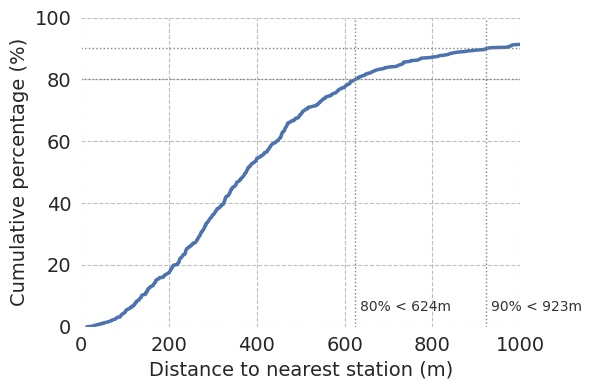

In [128]:
# ... (Distance calculation part remains same) ...

# 1. Prepare Data for CDF
sorted_data = np.sort(distances_m)
yvals = np.arange(len(sorted_data)) / float(len(sorted_data) - 1) * 100  # Percent

# 2. Plot
fig, ax = plt.subplots(figsize=(6, 4), facecolor='white')
ax.set_facecolor('white')

# Plot CDF line
ax.plot(sorted_data, yvals, color='#4c72b0', linewidth=2.5, label='CDF')

# 3. Formatting
plt.xlabel('Distance to nearest station (m)', fontsize=14)
plt.ylabel('Cumulative percentage (%)', fontsize=14)
plt.tick_params(axis='both', which='major', labelsize=14)

# Limit x-axis to focus on relevant range (e.g., 0-1000m or slightly more)
plt.xlim(0, 1000) # Adjust as needed
plt.ylim(0, 100)

# Add Grid
plt.grid(True, linestyle='--', alpha=0.5, color='gray')

# Optional: Mark 80% or 90% line
for pct in [80, 90]:
    idx = np.searchsorted(yvals, pct)
    val = sorted_data[idx]
    plt.axhline(pct, color='gray', linestyle=':', linewidth=1)
    plt.axvline(val, color='gray', linestyle=':', linewidth=1)
    plt.text(val + 10, 5, f'{pct}% < {val:.0f}m', fontsize=10, color='#333333')

# Remove spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

# centralized station charging

In [31]:
if os.path.exists(CENT_CHARGING_EVENTS_FILE):
    cent_charging_events = pd.read_parquet(CENT_CHARGING_EVENTS_FILE)
    cent_charging_events = cent_charging_events[cent_charging_events['taxiid'].isin(all_taxiids)].copy()
    print(f"exist {CENT_CHARGING_EVENTS_FILE}, covering {len(cent_charging_events)} events,{cent_charging_events['taxiid'].nunique()} taxis, and {cent_charging_events['nearest_station_id'].nunique()} stations")
else:
    event_coords = filtered_loss_events[['start_lon', 'start_lat']].values
    distances_deg, nearest_indices = sz_station_tree.query(event_coords, k=1)

    nearest_station_ids = sz_station_ids[nearest_indices]
    nearest_station_coords = sz_station_coords[nearest_indices]

    # Calculate actual distances in meters
    distances_m = haversine_distance(
        filtered_loss_events['start_lon'].values,
        filtered_loss_events['start_lat'].values,
        nearest_station_coords[:, 0],
        nearest_station_coords[:, 1]
    )

    filtered_loss_events['nearest_station_id'] = nearest_station_ids
    filtered_loss_events['distance_to_station_m'] = distances_m.get()

    # Identify centralized charging events (distance < DIST_THRESHOLD(m))
    DIST_THRESHOLD = 500
    filtered_loss_events['is_cent_char'] = filtered_loss_events['distance_to_station_m'] <= DIST_THRESHOLD
    cent_charging_events = filtered_loss_events[filtered_loss_events['is_cent_char']].copy()

    home_charging_events = filtered_loss_events[~filtered_loss_events['is_cent_char']].copy()

    print(f"  Events within {DIST_THRESHOLD}m: {len(cent_charging_events)} ({len(cent_charging_events)/len(filtered_loss_events)*100:.2f}%)")

    # Save results
    cent_charging_events.to_parquet(CENT_CHARGING_EVENTS_FILE, index=False)
    home_charging_events.to_parquet(HOME_CHARGING_EVENTS_FILE, index=False)
    print(f"\nSaved centralized charging events to: {CENT_CHARGING_EVENTS_FILE}, covering {cent_charging_events['taxiid'].nunique()} taxis, and {cent_charging_events['nearest_station_id'].nunique()} stations")
    print(f"\nSaved home charging events to: {HOME_CHARGING_EVENTS_FILE}, covering {home_charging_events['taxiid'].nunique()} taxis, and {home_charging_events['nearest_station_id'].nunique()} stations")

exist output_v6/centralized_charging_events.parquet, covering 267013 events,15805 taxis, and 1742 stations


In [18]:
# analysis to be done and visualization: gap loss events temporal-spatio features to determine possible charging, and after matching,
# we keep about 90% loss events that are close to a station (distribution of distance to station).

## Identify charging at distributed public stations

In [32]:
def detect_charging_for_one_taxi(taxiid, tracks_dir, station_tree, station_id_lookup, stations_df):

    try:
        # 读取轨迹数据
        track_path = os.path.join(tracks_dir, f'taxiid={taxiid}')
        if not os.path.exists(track_path):
            return pd.DataFrame()

        # 读取parquet文件（可能有多个分区文件）
        track_files = list(Path(track_path).glob('*.parquet'))
        if not track_files:
            return pd.DataFrame()

        # 读取并合并所有分区
        track = pd.concat([pd.read_parquet(f) for f in track_files], ignore_index=True)

        if track.empty:
            return pd.DataFrame()

        # 按时间排序
        track = track.sort_values('time').reset_index(drop=True)

        # 筛选空载点
        track = track[track['passenger'] == PASSENGER_THR].copy()

        if track.empty:
            return pd.DataFrame()

        # 查询最近充电站（CPU）
        track_coords = track[['lon', 'lat']].to_numpy()
        distances_deg, indices = station_tree.query(track_coords, k=1)
        distances_m = distances_deg * 111320  # 转换为米

        # 筛选在充电站半径内的点
        mask_in_station = distances_m <= R_STATION
        track_in_station = track[mask_in_station].copy()

        if track_in_station.empty:
            return pd.DataFrame()

        # 添加站点ID和距离信息
        track_in_station['nearest_station_id'] = station_id_lookup[indices[mask_in_station]]
        track_in_station['distance_to_station'] = distances_m[mask_in_station]

        # 按站点ID和时间排序
        track_in_station = track_in_station.sort_values(['nearest_station_id', 'time']).reset_index(drop=True)

        # 分段：同一站点内连续的点为一组
        # 如果时间间隔 > T_GAP 或站点ID变化，则断开
        track_in_station['prev_time'] = track_in_station.groupby('nearest_station_id')['time'].shift()
        track_in_station['prev_station'] = track_in_station['nearest_station_id'].shift()

        track_in_station['dt'] = (track_in_station['time'] - track_in_station['prev_time']).dt.total_seconds()
        track_in_station['station_changed'] = (track_in_station['nearest_station_id'] != track_in_station['prev_station'])

        # 标记段的开始（第一个点，或时间间隔过大，或站点变化）
        track_in_station['segment_start'] = (
            track_in_station['prev_time'].isna() |
            (track_in_station['dt'] > T_GAP) |
            track_in_station['station_changed']
        )

        # 分配段ID
        track_in_station['segment_id'] = track_in_station['segment_start'].cumsum()

        # 聚合每个段
        segments = track_in_station.groupby(['nearest_station_id', 'segment_id']).agg(
            start_time=('time', 'min'),
            end_time=('time', 'max'),
            stay_lon=('lon', 'mean'),
            stay_lat=('lat', 'mean'),
            num_points=('time', 'count'),
            avg_distance=('distance_to_station', 'mean')
        ).reset_index()

        # 计算持续时间
        segments['duration_s'] = (segments['end_time'] - segments['start_time']).dt.total_seconds()

        # 筛选满足最小停留时间的段
        charging_events = segments[segments['duration_s'] >= T_STAY].copy()

        # 添加taxiid
        charging_events['taxiid'] = taxiid

        # 选择输出列
        result = charging_events[['taxiid', 'nearest_station_id', 'start_time', 'end_time',
                                   'duration_s', 'stay_lon', 'stay_lat', 'num_points']].copy()

        return result

    except Exception as e:
        logging.error(f"处理车辆 {taxiid} 时出错: {e}")
        return pd.DataFrame()


In [33]:
# load or calculate
if os.path.exists(DIST_CHARGING_EVENTS_FILE):
    dist_charging_events = pd.read_parquet(DIST_CHARGING_EVENTS_FILE)
    dist_charging_events = dist_charging_events[dist_charging_events['taxiid'].isin(all_taxiids)].copy()
    logging.info(f"distributed charging event file exists, covering {len(dist_charging_events)} dist_events, {dist_charging_events['taxiid'].nunique()} vehicles, and {dist_charging_events['nearest_station_id'].nunique()} stations")
else:

    dist_charging_events = []

    with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
        futures = {
            executor.submit(detect_charging_for_one_taxi, tid, TRACKS_DIR,
                          station_tree, station_id_lookup, stations_df): tid
            for tid in all_taxiids
        }

        for future in tqdm(as_completed(futures), total=len(futures), desc="detecting.."):
            taxiid = futures[future]
            try:
                result = future.result()
                if not result.empty:
                    dist_charging_events.append(result)
            except Exception as e:
                logging.error(f" error when process {taxiid}: {e}")

    # mere results
    if dist_charging_events:
        dist_charging_events = pd.concat(dist_charging_events, ignore_index=True)
        dist_charging_events = dist_charging_events.sort_values(['taxiid', 'start_time']).reset_index(drop=True)
        dist_charging_events = dist_charging_events[dist_charging_events['taxiid'].isin(all_taxiids)].copy()
        # save
        dist_charging_events.to_parquet(DIST_CHARGING_EVENTS_FILE, index=False)
        logging.info(f" {len(dist_charging_events)} charging activities，covering {dist_charging_events['taxiid'].nunique()} vehicles, saved to {DIST_CHARGING_EVENTS_FILE}")
    else:
        logging.warning("no charging events detected")

2026-03-12 11:36:32,494 | INFO | distributed charging event file exists, covering 150038 dist_events, 15707 vehicles, and 1104 stations


In [21]:
dist_charging_events.head()

,taxiid,nearest_station_id,start_time,end_time,duration_s,stay_lon,stay_lat,num_points
0,UUUB0C0M7,2266,2020-01-02 01:21:09,2020-01-02 01:35:24,855.0,114.129456,22.547155,17
1,UUUB0C0M7,2205,2020-01-03 02:02:20,2020-01-03 02:13:40,680.0,114.121628,22.543396,20
2,UUUB0C0M7,2330,2020-01-04 04:33:45,2020-01-04 04:57:53,1448.0,114.142906,22.556120,57
3,UUUB0C0M7,2159,2020-01-05 02:24:03,2020-01-05 02:36:17,734.0,114.115372,22.558201,20
4,UUUB0C0M7,2161,2020-01-07 12:00:35,2020-01-07 12:40:05,2370.0,114.116241,22.580210,51


In [34]:
# combine two types of charging events, for SOC computation

if not dist_charging_events.empty:
    dist_charges_formatted = pd.DataFrame({
        'taxiid': dist_charging_events['taxiid'],
        'nearest_station_id': dist_charging_events['nearest_station_id'],
        'start_time': dist_charging_events['start_time'],
        'end_time': dist_charging_events['end_time'],
        'duration_s': dist_charging_events['duration_s'],
        'stay_lon': dist_charging_events['stay_lon'],
        'stay_lat': dist_charging_events['stay_lat'],
        'charge_type': 'distributed'
    })


if not cent_charging_events.empty:
    cent_charges_formatted = pd.DataFrame({
        'taxiid': cent_charging_events['taxiid'],
        'nearest_station_id': -1,  # 专用站充电标记为-1
        'start_time': cent_charging_events['start_time'],
        'end_time': cent_charging_events['end_time'],
        'duration_s': cent_charging_events['duration_s'],
        'stay_lon': cent_charging_events['start_lon'],
        'stay_lat': cent_charging_events['start_lat'],
        'charge_type': 'centralized'
    })


# if not home_charging_events.empty:
#     home_charges_formatted = pd.DataFrame({
#         'taxiid': cent_charging_events['taxiid'],
#         'nearest_station_id': -2,  # 充电标记为-2
#         'start_time': cent_charging_events['start_time'],
#         'end_time': cent_charging_events['end_time'],
#         'duration_s': cent_charging_events['duration_s'],
#         'stay_lon': cent_charging_events['start_lon'],
#         'stay_lat': cent_charging_events['start_lat'],
#         'charge_type': 'home'
#     })



if not dist_charges_formatted.empty and not cent_charges_formatted.empty:# and not home_charges_formatted.empty:
    all_charging_events = pd.concat([
        dist_charges_formatted,
        cent_charges_formatted
        #home_charges_formatted
    ], ignore_index=True)
    logging.info(f"all charging events: {len(all_charging_events)}")
else:
    logging.warning("error, no charging events")

if not all_charging_events.empty:
    all_charging_events = all_charging_events.sort_values(['taxiid', 'start_time']).reset_index(drop=True)
    print(f"all charging events: {len(all_charging_events)},over {all_charging_events['taxiid'].nunique()} taxis")


2026-03-12 11:36:36,591 | INFO | all charging events: 417051


all charging events: 417051,over 15853 taxis


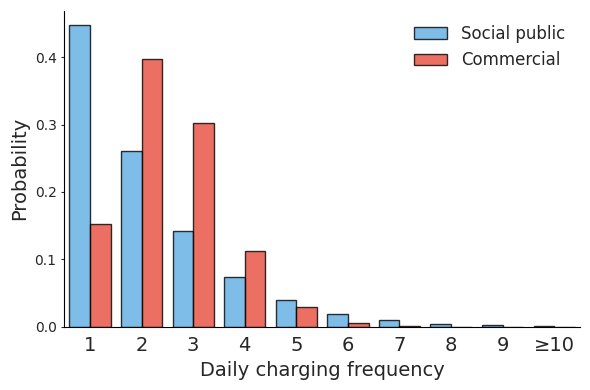

Average Daily Frequency:
charge_type
centralized    2.493794
distributed    2.138822
Name: freq, dtype: float64


In [35]:
#frequence of two types of charging

import pandas as pd
import matplotlib.pyplot as plt

# Assuming 'all_charging_events' is your merged DataFrame
# If it's not in memory, load it (or use the variable name you have)
# df = all_charging_events.copy()
df = all_charging_events.copy() # Use your variable name here

# 1. Preprocess
df['date'] = pd.to_datetime(df['start_time']).dt.date

# 2. Calculate Daily Frequency per Taxi per Type
# Count how many times each taxi charges per day for each type
daily_counts = df.groupby(['date', 'taxiid', 'charge_type']).size().reset_index(name='freq')
daily_counts['freq'] = daily_counts['freq'].clip(upper=10)
# 3. Calculate Probability Distribution
# We want to know: What % of taxi-days have 1 charge, 2 charges, etc.
dist_data = daily_counts.groupby(['charge_type', 'freq']).size().unstack(fill_value=0)
# Normalize to get probability (percentage)
dist_pct = dist_data.div(dist_data.sum(axis=1), axis=0)

# 4. Plot
fig, ax = plt.subplots(figsize=(6, 4), facecolor='white')

# Bar positions
x = dist_pct.columns
width = 0.4

# Plot Bars
if 'distributed' in dist_pct.index:
    ax.bar(x - width/2, dist_pct.loc['distributed'], width=width, label='Social public',
           color='#5DADE2', edgecolor='black', alpha=0.8)

if 'centralized' in dist_pct.index:
    ax.bar(x + width/2, dist_pct.loc['centralized'], width=width, label='Commercial',
           color='#E74C3C', edgecolor='black', alpha=0.8)

# 5. Formatting
ax.set_xticks(range(1, 11))
xlabels = [str(i) for i in range(1, 10)] + ['≥10']
ax.set_xticklabels(xlabels)
ax.set_xlim(0.5, 10.5)
ax.set_xlabel('Daily charging frequency', fontsize=14)
ax.set_ylabel('Probability', fontsize=14)
ax.tick_params(axis='both', which='major', labelsize=14)
ax.legend(fontsize=12,frameon=False)
ax.set_facecolor('white')
ax.tick_params(axis='y', which='both', direction='out', length=2, width=0.8, labelsize=10,left = True)
# Clean look
ax.spines['top'].set_visible(True)
ax.spines['right'].set_visible(True)
ax.spines['left'].set_linewidth(0.8)
ax.spines['bottom'].set_linewidth(0.8)
ax.spines['left'].set_color('black')
ax.spines['bottom'].set_color('black')
ax.grid(False)
plt.tight_layout()
plt.show()

# Print Average Frequency
avg_freq = daily_counts.groupby('charge_type')['freq'].mean()
print("Average Daily Frequency:")
print(avg_freq)

In [28]:
import pandas as pd

def avg_per_vehicle_day(df, taxi_col='taxiid', time_col='start_time'):
    df = df.copy()
    df['date'] = pd.to_datetime(df[time_col]).dt.date
    n_veh = df[taxi_col].nunique()
    n_days = (df['date'].max() - df['date'].min()).days + 1
    return len(df) / (n_veh * n_days), n_veh, n_days

# 商业充电
avg_cent, n_veh_cent, n_days_cent = avg_per_vehicle_day(cent_charging_events)
n_cent = len(cent_charging_events)

# 分布式充电
avg_dist, n_veh_dist, n_days_dist = avg_per_vehicle_day(dist_charging_events)
n_dist = len(dist_charging_events)

# 加权平均（按车-天加权）
vd_cent = n_veh_cent * n_days_cent
vd_dist = n_veh_dist * n_days_dist
avg_total = (avg_cent * vd_cent + avg_dist * vd_dist) / (vd_cent + vd_dist)

print(f"商业充电: {n_cent} 次, {n_veh_cent} 车, {n_days_cent} 天")
print(f"  平均 {avg_cent:.4f} 次/车/天")
print(f"分布式充电: {n_dist} 次, {n_veh_dist} 车, {n_days_dist} 天")
print(f"  平均 {avg_dist:.4f} 次/车/天")
print(f"加权总平均: {avg_total:.4f} 次/车/天")
print(f"  (权重: 商业 {vd_cent} 车-天, 分布式 {vd_dist} 车-天)")

商业充电: 267013 次, 15805 车, 7 天
  平均 2.4135 次/车/天
分布式充电: 150038 次, 15707 车, 8 天
  平均 1.1940 次/车/天
加权总平均: 1.7650 次/车/天
  (权重: 商业 110635 车-天, 分布式 125656 车-天)


In [27]:
all_events['date'].unique()

array([datetime.date(2020, 1, 1), datetime.date(2020, 1, 2),
       datetime.date(2020, 1, 3), datetime.date(2020, 1, 4),
       datetime.date(2020, 1, 5), datetime.date(2020, 1, 6),
       datetime.date(2020, 1, 7), datetime.date(2020, 1, 8)], dtype=object)

In [ ]:
# waiting time, charging time distribution, frequence

## Queue model


In [36]:
def simulate_queue(df):

    if df.empty:
        return pd.DataFrame()

    k = int(df['num_piles'].iloc[0])
    busy_chargers_heap = []
    results = []

    for _, row in df.iterrows():
        arrival_time = row['start_time']
        departure_time = row['end_time']


        while busy_chargers_heap and busy_chargers_heap[0] <= arrival_time:
            heappop(busy_chargers_heap)


        if len(busy_chargers_heap) < k:

            wait_seconds = 0
            charge_start_time = arrival_time
        else:

            earliest_free_time = heappop(busy_chargers_heap)
            wait_seconds = (earliest_free_time - arrival_time).total_seconds()
            charge_start_time = earliest_free_time


        stay_duration = (departure_time - arrival_time).total_seconds()
        gave_up = (wait_seconds >= stay_duration)


        if gave_up:
            actual_charge_seconds = 0

            if 'earliest_free_time' in locals() and wait_seconds > 0:
                heappush(busy_chargers_heap, earliest_free_time)
        else:
            actual_charge_seconds = (departure_time - charge_start_time).total_seconds()

            heappush(busy_chargers_heap, departure_time)

        results.append({
            'taxiid': row['taxiid'],
            'nearest_station_id': row['nearest_station_id'],
            'arrive_time': arrival_time,
            'leave_time': departure_time,
            'wait_dur': wait_seconds,
            'giveup': gave_up,
            'charge_dur': actual_charge_seconds
        })

    return pd.DataFrame(results)


In [37]:

if os.path.exists(CHAR_QUEUE_FILE):
    char_queue_df = pd.read_parquet(CHAR_QUEUE_FILE)
    char_queue_df = char_queue_df[char_queue_df['taxiid'].isin(all_taxiids)].copy()
    logging.info(f"load {len(char_queue_df)} queue results ")

elif not dist_charging_events.empty:
    dist_charging_events = dist_charging_events[dist_charging_events['taxiid'].isin(all_taxiids)].copy()
    queue_input = dist_charging_events.merge(
        stations_df[['station_id', 'num_piles']],
        left_on='nearest_station_id',
        right_on='station_id',
        how='left'
    )


    queue_input = queue_input.sort_values(['nearest_station_id', 'start_time'], kind='mergesort')


    all_queue_results = []
    for station_id, group in tqdm(queue_input.groupby('nearest_station_id'), desc="排队模拟"):
        result = simulate_queue(group)
        if not result.empty:
            all_queue_results.append(result)


    if all_queue_results:
        char_queue_df = pd.concat(all_queue_results, ignore_index=True)
        char_queue_df = char_queue_df.sort_values(['taxiid', 'arrive_time']).reset_index(drop=True)

        char_queue_df.to_parquet(CHAR_QUEUE_FILE, index=False)
        logging.info(f"排队模拟完成，结果已保存到 {CHAR_QUEUE_FILE}")


        avg_wait = char_queue_df['wait_dur'].mean()
        giveup_rate = char_queue_df['giveup'].mean()
        logging.info(f"average waiting time: {avg_wait:.2f} seconds ({avg_wait/60:.2f} min)")
        logging.info(f"giveup rate: {giveup_rate:.2%}")
    else:
        logging.warning("error: no results")
        char_queue_df = pd.DataFrame()
else:
    logging.warning("absence of distributed charging")


2026-03-12 11:36:48,629 | INFO | load 150038 queue results 


In [38]:
if 'char_queue_df' in locals() and not char_queue_df.empty:
    char_queue_df['charge_date'] = char_queue_df['arrive_time'].dt.date

    daily_charges = char_queue_df[char_queue_df['giveup'] == False].groupby(['taxiid', 'charge_date']).size().reset_index(name='daily_charge_count')

    avg_daily_per_taxi = daily_charges.groupby('taxiid')['daily_charge_count'].mean().reset_index(name='avg_daily_charges')

    overall_avg = avg_daily_per_taxi['avg_daily_charges'].mean()

    print(f"\naverage distributed charging times(per day, per veh): {overall_avg:.2f}")
    print(f"median distributed charging times(per day, per veh): {avg_daily_per_taxi['avg_daily_charges'].median():.2f}")


average distributed charging times(per day, per veh): 1.83
median distributed charging times(per day, per veh): 1.60


In [39]:
giveup = char_queue_df[char_queue_df['giveup'] == True].copy()
print('giveup ratio:', len(giveup)/len(char_queue_df))

giveup ratio: 0.07837347871872459


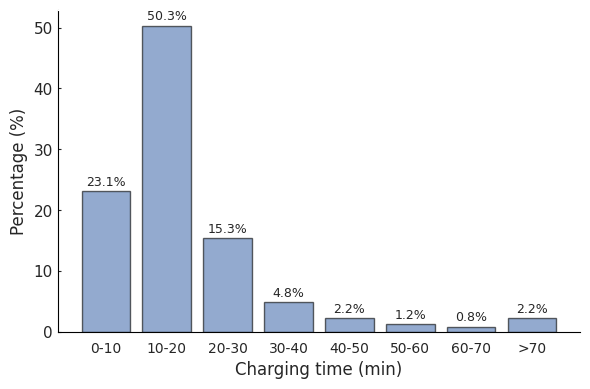

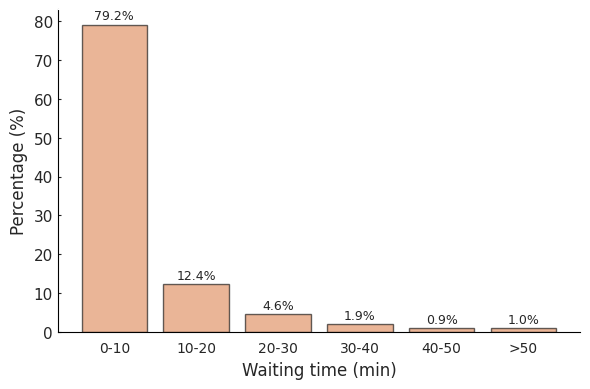

In [140]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Setup ---
# Assuming char_queue_df is already loaded
if 'charging_time_min' not in char_queue_df.columns:
    char_queue_df['charging_time_min'] = char_queue_df['charge_dur'] / 60
if 'waiting_time_min' not in char_queue_df.columns:
    char_queue_df['waiting_time_min'] = char_queue_df['wait_dur'] / 60

# Function to plot histogram
def plot_dist(data, max_thresh, bin_size, color, xlabel):
    bins = list(np.arange(0, max_thresh, bin_size)) + [np.inf]
    counts, edges = np.histogram(data, bins=bins)
    pcts = counts / len(data) * 100

    labels = [f"{int(edges[i])}-{int(edges[i+1])}" if edges[i+1] != np.inf else f">{int(edges[i])}"
              for i in range(len(counts))]

    # Plot
    fig, ax = plt.subplots(figsize=(6, 4), facecolor='white')
    bars = ax.bar(range(len(counts)), pcts, color=color, alpha=0.6, edgecolor='black', width=0.8)
    ax.set_facecolor('white')
    ax.set_xlabel(xlabel, fontsize=12)
    ax.set_ylabel('Percentage (%)', fontsize=12)
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=0, ha='center')
    ax.grid(False)

    # Remove spines
    ax.spines['top'].set_visible(True)
    ax.spines['right'].set_visible(True)
    ax.tick_params(axis='y', which='both', direction='in', length=2, width=0.8, labelsize=TICK_SIZE,left = True)
    ax.spines['left'].set_linewidth(0.8)
    ax.spines['bottom'].set_linewidth(0.8)
    ax.spines['left'].set_color('black')
    ax.spines['bottom'].set_color('black')
    # Add labels
    for bar, pct in zip(bars, pcts):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height + 0.5, f'{pct:.1f}%',
                ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.show()

# --- 2. Plot Charging Time ---
plot_dist(char_queue_df['charging_time_min'],
          max_thresh=80, bin_size=10,
          color='#4C72B0', xlabel='Charging time (min)') # Blue

# --- 3. Plot Waiting Time ---
plot_dist(char_queue_df['waiting_time_min'],
          max_thresh=60, bin_size=10,
          color='#DD8452', xlabel='Waiting time (min)') # Orange

## Energy consumption and SOC trajectory

### energy consumption


In [40]:

def calculate_energy_between_charges_v2(tracks_dir, charging_events_taxi):

    try:
        # 从充电事件中获取taxiid
        if charging_events_taxi.empty or len(charging_events_taxi) < 2:
            return pd.DataFrame()

        taxiid = charging_events_taxi.iloc[0]['taxiid']

        # 读取轨迹数据
        track_path = os.path.join(tracks_dir, f'taxiid={taxiid}')
        if not os.path.exists(track_path):
            return pd.DataFrame()

        track_files = list(Path(track_path).glob('*.parquet'))
        if not track_files:
            return pd.DataFrame()

        # 读取轨迹（使用cudf加速）
        track = cudf.concat([cudf.read_parquet(f) for f in track_files], ignore_index=True)

        # 过滤zoneid < 0的点
        track = track[track['zoneid'] >= 0].copy()
        if track.empty:
            return pd.DataFrame()

        track = track.sort_values('time').reset_index(drop=True)

        # 计算相邻点之间的距离和时间差（向量化操作）
        track['prev_lon'] = track['lon'].shift()
        track['prev_lat'] = track['lat'].shift()
        track['prev_time'] = track['time'].shift()

        # 填充第一行的NaN（用自身值填充）
        track['prev_lon'] = track['prev_lon'].fillna(track['lon'])
        track['prev_lat'] = track['prev_lat'].fillna(track['lat'])
        track['prev_time'] = track['prev_time'].fillna(track['time'])

        # 计算时间差和距离
        track['dt'] = (track['time'] - track['prev_time']).dt.total_seconds()
        track['dist'] = haversine_distance(
            track['lon'], track['lat'],
            track['prev_lon'], track['prev_lat']
        )

        # 过滤异常跳点（速度 > 25 m/s，约90 km/h，对于城市出租车来说异常）
        track = track[track['dist'] / track['dt'].clip(lower=1) <= 25].copy()

        # 标记怠速点（速度 <= 5 km/h）
        track['idle'] = (track['velocity'] <= 5).astype('int8')

        # 转换为pandas（只在需要时转换）
        track_pd = track[['time', 'dt', 'dist', 'idle']].to_pandas()

        # 释放GPU内存
        del track
        cp._default_memory_pool.free_all_blocks()

        # 对每对相邻充电事件计算能耗
        results = []
        charging_events_sorted = charging_events_taxi.sort_values('start_time').reset_index(drop=True)

        for i in range(1, len(charging_events_sorted)):
            prev_end = charging_events_sorted.iloc[i - 1]['end_time']
            curr_start = charging_events_sorted.iloc[i]['start_time']
            curr_charge_type = charging_events_sorted.iloc[i]['charge_type']

            # 提取两次充电之间的轨迹段（使用布尔索引，更高效）
            mask = (track_pd['time'] > prev_end) & (track_pd['time'] <= curr_start)
            segment = track_pd[mask].copy()

            if segment.empty:
                continue

            # 检查数据缺失（时间间隔过大）
            large_gaps_mask = segment['dt'] > MAX_GAP_SECONDS
            missing_s = segment.loc[large_gaps_mask, 'dt'].sum() if large_gaps_mask.any() else 0

            # 只计算有数据的部分
            valid_segment = segment[~large_gaps_mask]
            if valid_segment.empty:
                continue

            # 计算行驶和怠速时间（向量化操作）
            drive_s = int(valid_segment.loc[valid_segment['idle'] == 0, 'dt'].sum())
            idle_s = int(valid_segment.loc[valid_segment['idle'] == 1, 'dt'].sum())
            gap_s = drive_s + idle_s

            # 计算距离和能耗
            distance_km = valid_segment['dist'].sum() / 1000
            energy_used_kWh = distance_km * CONS_KWH_PER_KM

            results.append({
                'taxiid': taxiid,
                'charge_start': curr_start,
                'prev_end': prev_end,
                'gap_s': gap_s,
                'drive_s': drive_s,
                'idle_s': idle_s,
                'distance_km': distance_km,
                'energy_used_kWh': energy_used_kWh,
                'missing_s': missing_s,
                'charge_type': curr_charge_type
            })

        return pd.DataFrame(results)

    except Exception as e:
        logging.error(f"计算车辆 {taxiid if 'taxiid' in locals() else 'unknown'} 能耗时出错: {e}")
        import traceback
        logging.error(traceback.format_exc())
        return pd.DataFrame()



In [41]:

# ========== 批量计算所有车辆的能耗（使用合并后的完整充电事件） ==========

# 如果文件已存在，可以选择跳过或重新计算
if os.path.exists(ENERGY_CONS_FILE):
    energy_cons_df = pd.read_parquet(ENERGY_CONS_FILE)
    energy_cons_df = energy_cons_df[energy_cons_df['taxiid'].isin(all_taxiids)].copy()
    logging.info(f"能耗数据文件已存在: {ENERGY_CONS_FILE}")

else:
    all_energy_results = []
    all_charging_events =all_charging_events[all_charging_events['taxiid'].isin(all_taxiids)].copy()
    # 按车辆分组处理（使用groupby，更高效）
    grouped = all_charging_events.groupby('taxiid')

    for taxiid, ce_group in tqdm(grouped, total=grouped.ngroups, desc="计算能耗）"):
        if len(ce_group) < 2:  # 至少需要2次充电才能计算间隔
            continue

        result = calculate_energy_between_charges_v2(TRACKS_DIR, ce_group)
        if not result.empty:
            all_energy_results.append(result)

        # 每处理100辆车释放一次GPU内存（减少释放频率，提高效率）
        if len(all_energy_results) % 100 == 0:
            cp._default_memory_pool.free_all_blocks()

    # 最终释放GPU内存
    cp._default_memory_pool.free_all_blocks()

    if all_energy_results:
        energy_cons_df = pd.concat(all_energy_results, ignore_index=True)
        energy_cons_df = energy_cons_df.sort_values(['taxiid', 'charge_start']).reset_index(drop=True)

        # 保存结果
        energy_cons_df.to_parquet(ENERGY_CONS_FILE, index=False)
        logging.info(f"能耗计算完成，结果已保存到 {ENERGY_CONS_FILE}")
    else:
        logging.warning("未计算出任何能耗数据")



2026-03-12 11:38:28,986 | INFO | 能耗数据文件已存在: output_v6/energy_consumption.parquet


In [59]:
energy_cons_df.to_parquet(ENERGY_CONS_FILE, index=False)

In [43]:
energy_cons_df[energy_cons_df['taxiid']=='UUUB0C1Q1']

,taxiid,charge_start,prev_end,gap_s,drive_s,idle_s,distance_km,energy_used_kWh,missing_s,charge_type
89,UUUB0C1Q1,2020-01-01 12:36:39,2020-01-01 06:07:39,21066,14350,6716,168.416704,33.683341,1515.0,centralized
90,UUUB0C1Q1,2020-01-02 11:17:11,2020-01-01 14:00:18,66082,43553,22529,425.923392,85.184678,9428.0,centralized
91,UUUB0C1Q1,2020-01-02 14:43:15,2020-01-02 12:21:06,8529,5440,3089,50.329925,10.065985,0.0,distributed
92,UUUB0C1Q1,2020-01-03 05:54:43,2020-01-02 14:58:06,39332,26413,12919,280.578501,56.115700,14210.0,centralized
93,UUUB0C1Q1,2020-01-03 11:55:41,2020-01-03 07:06:41,17240,11197,6043,105.674245,21.134849,0.0,distributed
94,UUUB0C1Q1,2020-01-03 16:58:01,2020-01-03 12:59:37,14087,8569,5518,87.171494,17.434299,0.0,centralized
95,UUUB0C1Q1,2020-01-04 05:56:09,2020-01-03 17:44:33,37370,22755,14615,239.503817,47.900763,6522.0,centralized
96,UUUB0C1Q1,2020-01-04 08:14:11,2020-01-04 06:46:56,4798,2110,2688,26.912996,5.382599,0.0,centralized
97,UUUB0C1Q1,2020-01-04 10:59:04,2020-01-04 08:59:04,6600,3233,3367,34.714645,6.942929,0.0,centralized
98,UUUB0C1Q1,2020-01-04 16:26:41,2020-01-04 11:46:11,16755,10587,6168,100.911648,20.182330,0.0,centralized


# 6.2 SOC 轨迹

In [42]:
if os.path.exists(BATTERY_TRACE_FILE):
    battery_trace_output = pd.read_parquet(BATTERY_TRACE_FILE)
    battery_trace_output = battery_trace_output[battery_trace_output['taxiid'].isin(all_taxiids)].copy()
    logging.info(f"{BATTERY_TRACE_FILE} exists, covering {battery_trace_output['taxiid'].nunique()} vehicles")

else:
    battery_trace = all_charging_events.copy()

    # 2. 分离公共和专用站充电事件
    public_mask = battery_trace['charge_type'] == 'distributed'
    dedicated_mask = battery_trace['charge_type'] == 'centralized'

    battery_trace_public = battery_trace[public_mask].copy()
    battery_trace_dedicated = battery_trace[dedicated_mask].copy()

    # 3. 处理公共充电事件：合并排队结果和站点功率
    if not battery_trace_public.empty:
        battery_trace_public = battery_trace_public.merge(
            char_queue_df[['taxiid', 'arrive_time', 'charge_dur', 'wait_dur', 'giveup']],
            left_on=['taxiid', 'start_time'],
            right_on=['taxiid', 'arrive_time'],
            how='left'
        )
        battery_trace_public = battery_trace_public.merge(
            stations_df[['station_id', 'avg_power']],
            left_on='nearest_station_id',
            right_on='station_id',
            how='left'
        )
        battery_trace_public = battery_trace_public.drop(columns=['station_id'], errors='ignore')

    # 4. 处理专用站充电事件：设置默认值
    if not battery_trace_dedicated.empty:
        battery_trace_dedicated['arrive_time'] = battery_trace_dedicated['start_time']
        battery_trace_dedicated['charge_dur'] = battery_trace_dedicated['duration_s']
        battery_trace_dedicated['wait_dur'] = 0
        battery_trace_dedicated['giveup'] = False
        battery_trace_dedicated['avg_power'] = 43.0

    # 4.5 读取home充电事件
    battery_trace_home_prepared = pd.DataFrame()
    if os.path.exists(HOME_CHARGING_EVENTS_FILE):
        home_events = pd.read_parquet(HOME_CHARGING_EVENTS_FILE)
        home_events = home_events[home_events['taxiid'].isin(all_taxiids)].copy()
        if not home_events.empty:
            battery_trace_home_prepared = home_events.copy()
            battery_trace_home_prepared['arrive_time'] = battery_trace_home_prepared['start_time']
            battery_trace_home_prepared['charge_dur'] = battery_trace_home_prepared['duration_s']
            battery_trace_home_prepared['wait_dur'] = 0
            battery_trace_home_prepared['giveup'] = False
            battery_trace_home_prepared['avg_power'] = 43.0
            battery_trace_home_prepared['charge_type'] = 'home'
            logging.info(f"Loaded {len(battery_trace_home_prepared)} home charging events from {HOME_CHARGING_EVENTS_FILE}")

    # 5. 合并充电事件（只合并distributed和centralized）
    common_cols = ['taxiid', 'nearest_station_id', 'start_time', 'end_time',
                  'duration_s', 'stay_lon', 'stay_lat', 'charge_type',
                  'arrive_time', 'charge_dur', 'wait_dur', 'giveup', 'avg_power']

    battery_trace = pd.concat([
        battery_trace_public[common_cols] if not battery_trace_public.empty else pd.DataFrame(),
        battery_trace_dedicated[common_cols] if not battery_trace_dedicated.empty else pd.DataFrame()
    ], ignore_index=True)

    if battery_trace.empty:
        logging.warning("没有充电事件数据，无法计算SOC轨迹")
    else:
        # 6. 按车辆和时间排序
        battery_trace = battery_trace.sort_values(['taxiid', 'start_time']).reset_index(drop=True)
        battery_trace['prev_end'] = battery_trace.groupby('taxiid')['end_time'].shift()

        # 7. 合并能耗数据
        battery_trace = battery_trace.merge(
            energy_cons_df[['taxiid', 'charge_start', 'energy_used_kWh', 'missing_s',
                'gap_s', 'drive_s', 'idle_s', 'distance_km', 'charge_type']],
            left_on=['taxiid', 'start_time'],
            right_on=['taxiid', 'charge_start'],
            how='left',
            suffixes=('', '_from_energy')
        )

        battery_trace['charge_type'] = battery_trace['charge_type_from_energy'].fillna(battery_trace['charge_type'])
        battery_trace = battery_trace.drop(columns=['charge_type_from_energy', 'charge_start'], errors='ignore')

        # 8. 初始化能耗数据
        battery_trace['energy_used_kWh'] = battery_trace['energy_used_kWh'].fillna(0)
        battery_trace['distance_km'] = battery_trace['distance_km'].fillna(0)

        # 8.5 预处理home事件为dict
        home_dict = {}
        if not battery_trace_home_prepared.empty:
            for tid, sub in battery_trace_home_prepared.groupby('taxiid'):
                home_dict[tid] = sub.sort_values('start_time')

        # 9. 逐车递推SOC，当SOC=0时检查是否有home充电
        def calculate_soc_trace_v2(taxiid, group, home_all_dict):
            h_events = home_all_dict.get(taxiid, pd.DataFrame())

            new_rows = []
            soc_prev = CAP_KWH
            group = group.sort_values('start_time').reset_index(drop=True)

            for _, row in group.iterrows():
                energy_gap = row.get('energy_used_kWh', 0)
                dist_km = row.get('distance_km', 0)
                prev_end = row.get('prev_end', pd.NaT)
                curr_start = row['start_time']

                # 先按原逻辑计算 soc_before
                soc_before_initial = max(0, soc_prev - energy_gap)

                # 检查：如果 SOC 降到 0（或接近0，如 < 0.1 kWh），且存在 home 事件
                if soc_before_initial < 0.1 and pd.notna(prev_end) and not h_events.empty:
                    # 查找在这两次充电之间的home事件
                    mask = (h_events['start_time'] >= prev_end) & (h_events['end_time'] <= curr_start)
                    if mask.any():
                        h = h_events[mask].iloc[0].copy()

                        # 按时间线性拆分能耗
                        dt_total = (curr_start - prev_end).total_seconds()
                        dt_home = (h['start_time'] - prev_end).total_seconds()
                        p = 0.5 if dt_total <= 0 else min(max(dt_home / dt_total, 0), 1)

                        energy1 = energy_gap * p
                        energy2 = energy_gap - energy1
                        dist1 = dist_km * p
                        dist2 = dist_km - dist1

                        # 计算到达home前的SOC
                        soc_before_home = max(0, soc_prev - energy1)

                        # Home充电（43kW）
                        h_dur_h = h['charge_dur'] / 3600
                        h_energy_in = min(CAP_KWH - soc_before_home, h_dur_h * 43.0 * CHG_EFFICIENCY)
                        soc_after_home = soc_before_home + h_energy_in

                        # 创建home记录行
                        h_row = h.copy()
                        h_row['SOC_before_kWh'] = soc_before_home
                        h_row['SOC_after_kWh'] = soc_after_home
                        h_row['energy_in_kWh'] = h_energy_in
                        h_row['energy_used_kWh'] = energy1
                        h_row['distance_km'] = dist1
                        h_row['prev_end'] = prev_end
                        new_rows.append(h_row)

                        # 更新主事件前的SOC（扣除home之后的能耗energy2）
                        soc_before = max(0, soc_after_home - energy2)

                        # 更新当前行的能耗/里程
                        row['energy_used_kWh'] = energy2
                        row['distance_km'] = dist2
                        row['prev_end'] = h['end_time']
                    else:
                        # 没有匹配的home事件，使用初始计算的SOC
                        soc_before = soc_before_initial
                else:
                    # SOC 正常，使用初始计算的SOC
                    soc_before = soc_before_initial

                # 计算当前主充电事件的充入电量
                charge_dur_hours = row['charge_dur'] / 3600

                if row['giveup'] == True:
                    power_kw = 0
                else:
                    power_kw = row['avg_power'] if pd.notna(row['avg_power']) else 0

                energy_in_theoretical = charge_dur_hours * power_kw * CHG_EFFICIENCY
                max_energy_in = CAP_KWH - soc_before
                energy_in = min(energy_in_theoretical, max_energy_in)
                soc_after = min(CAP_KWH, soc_before + energy_in)

                row['SOC_before_kWh'] = soc_before
                row['SOC_after_kWh'] = soc_after
                row['energy_in_kWh'] = energy_in
                new_rows.append(row)

                soc_prev = soc_after

            return pd.DataFrame(new_rows)

        # 带进度条的分组计算
        battery_trace_list = []
        for tid, grp in tqdm(battery_trace.groupby('taxiid'), desc="计算SOC轨迹", total=battery_trace['taxiid'].nunique()):
            battery_trace_list.append(calculate_soc_trace_v2(tid, grp, home_dict))
        battery_trace = pd.concat(battery_trace_list, ignore_index=True)
        battery_trace = battery_trace.sort_values(['taxiid', 'start_time']).reset_index(drop=True)

        # 10. 计算百分比
        battery_trace['SOC_before_pct'] = battery_trace['SOC_before_kWh'] / CAP_KWH * 100
        battery_trace['SOC_after_pct'] = battery_trace['SOC_after_kWh'] / CAP_KWH * 100

        # 11. 选择输出列
        output_cols = [
            'taxiid', 'charge_type', 'nearest_station_id', 'start_time', 'end_time',
            'SOC_before_kWh', 'SOC_after_kWh', 'SOC_before_pct', 'SOC_after_pct',
            'energy_used_kWh', 'energy_in_kWh',
            'distance_km', 'drive_s', 'idle_s', 'gap_s', 'missing_s',
            'charge_dur', 'wait_dur', 'giveup'
        ]
        output_cols = [col for col in output_cols if col in battery_trace.columns]
        battery_trace_output = battery_trace[output_cols].copy()
        battery_trace_output.to_parquet(BATTERY_TRACE_FILE, index=False)
        logging.info(f"covering {battery_trace_output['taxiid'].nunique()} vehicles, saved to {BATTERY_TRACE_FILE}")

2026-03-12 11:38:38,526 | INFO | output_v6/battery_trace.parquet exists, covering 15853 vehicles


In [43]:
if os.path.exists(BATTERY_TRACE_FILE):
    battery_trace_output = pd.read_parquet(BATTERY_TRACE_FILE)
    battery_trace_output = battery_trace_output[battery_trace_output['taxiid'].isin(all_taxiids)].copy()
    logging.info(f"{BATTERY_TRACE_FILE} exists, covering {battery_trace_output['taxiid'].nunique()} vehicles")

else:
    battery_trace = all_charging_events.copy()

    # 2. 分离公共和专用站充电事件
    public_mask = battery_trace['charge_type'] == 'distributed'
    dedicated_mask = battery_trace['charge_type'] == 'centralized'


    battery_trace_public = battery_trace[public_mask].copy()
    battery_trace_dedicated = battery_trace[dedicated_mask].copy()

    # 3. 处理公共充电事件：合并排队结果和站点功率
    if not battery_trace_public.empty:
        battery_trace_public = battery_trace_public.merge(
            char_queue_df[['taxiid', 'arrive_time', 'charge_dur', 'wait_dur', 'giveup']],
            left_on=['taxiid', 'start_time'],
            right_on=['taxiid', 'arrive_time'],
            how='left'
        )

        # 合并站点平均功率
        battery_trace_public = battery_trace_public.merge(
            stations_df[['station_id', 'avg_power']],
            left_on='nearest_station_id',
            right_on='station_id',
            how='left'
        )
        battery_trace_public = battery_trace_public.drop(columns=['station_id'], errors='ignore')

    # 4. 处理专用站充电事件和在家充电：设置默认值
    if not battery_trace_dedicated.empty:
        battery_trace_dedicated['arrive_time'] = battery_trace_dedicated['start_time']
        battery_trace_dedicated['charge_dur'] = battery_trace_dedicated['duration_s']  # 全部都是充电时间
        battery_trace_dedicated['wait_dur'] = 0  # 专用站充电没有等待
        battery_trace_dedicated['giveup'] = False  # 专用站充电不放弃
        battery_trace_dedicated['avg_power'] = 43.0  # 专用站充电功率统一为43kW
    # if not battery_trace_home.empty:
    #     battery_trace_home['arrive_time'] = battery_trace_home['start_time']
    #     battery_trace_home['charge_dur'] = battery_trace_home['duration_s']  # 全部都是充电时间
    #     battery_trace_home['wait_dur'] = 0  # 没有等待
    #     battery_trace_home['giveup'] = False  # 不放弃
    #     battery_trace_home['avg_power'] = 43.0  # 专用站充电功率统一为43kW


    # 5. 合并充电事件
    if not battery_trace_public.empty and not battery_trace_dedicated.empty and not battery_trace_home.empty:
        # 统一列名
        common_cols = ['taxiid', 'nearest_station_id', 'start_time', 'end_time',
                      'duration_s', 'stay_lon', 'stay_lat', 'charge_type',
                      'arrive_time', 'charge_dur', 'wait_dur', 'giveup', 'avg_power']

        battery_trace = pd.concat([
            battery_trace_public[common_cols],
            battery_trace_dedicated[common_cols]
        ], ignore_index=True)


    if battery_trace.empty:
        logging.warning("没有充电事件数据，无法计算SOC轨迹")
    else:
        # 6. 按车辆和时间排序
        battery_trace = battery_trace.sort_values(['taxiid', 'start_time']).reset_index(drop=True)
        battery_trace['prev_end'] = battery_trace.groupby('taxiid')['end_time'].shift()

        # 7. 合并能耗数据（两次充电之间的能耗，包含charge_type）
        battery_trace = battery_trace.merge(
            energy_cons_df[['taxiid', 'charge_start', 'energy_used_kWh', 'missing_s',
                'gap_s', 'drive_s', 'idle_s', 'distance_km', 'charge_type']],
            left_on=['taxiid', 'start_time'],
            right_on=['taxiid', 'charge_start'],
            how='left',
            suffixes=('', '_from_energy')
        )

        # 使用能耗表中的charge_type（更准确，因为它标记的是当前充电事件的类型）
        battery_trace['charge_type'] = battery_trace['charge_type_from_energy'].fillna(battery_trace['charge_type'])
        battery_trace = battery_trace.drop(columns=['charge_type_from_energy', 'charge_start'], errors='ignore')

        # 8. 初始化能耗数据
        battery_trace['energy_used_kWh'] = battery_trace['energy_used_kWh'].fillna(0)

        # 9. 逐车递推SOC（先计算SOC_before，再计算充入电量）
        def calculate_soc_trace_v2(group):
            soc_before_list = []
            soc_after_list = []
            soc_prev = CAP_KWH  # 初始满电

            for _, row in group.iterrows():
                # 计算充电前SOC
                soc_before = max(0, soc_prev - row['energy_used_kWh'])
                soc_before_list.append(soc_before)

                # 计算充入电量（基于充电前SOC）
                charge_dur_hours = row['charge_dur'] / 3600

                # 公共充电：放弃充电的功率为0，否则使用站平均功率
                # 专用站充电：功率统一为43kW
                if row['giveup'] == True:
                    power_kw = 0
                else:
                    power_kw = row['avg_power'] if pd.notna(row['avg_power']) else 0

                # 计算理论充入电量
                energy_in_theoretical = charge_dur_hours * power_kw * CHG_EFFICIENCY

                # 限制充入电量：不能超过（满电量 - 充电前电量）
                max_energy_in = CAP_KWH - soc_before
                energy_in = min(energy_in_theoretical, max_energy_in)

                # 计算充电后SOC
                soc_after = min(CAP_KWH, soc_before + energy_in)
                soc_after_list.append(soc_after)

                soc_prev = soc_after

            group['SOC_before_kWh'] = soc_before_list
            group['SOC_after_kWh'] = soc_after_list
            group['energy_in_kWh'] = [soc_after_list[i] - soc_before_list[i] for i in range(len(soc_before_list))]
            return group

        battery_trace = battery_trace.groupby('taxiid', group_keys=False).apply(calculate_soc_trace_v2)

        # 10. 计算百分比
        battery_trace['SOC_before_pct'] = battery_trace['SOC_before_kWh'] / CAP_KWH * 100
        battery_trace['SOC_after_pct'] = battery_trace['SOC_after_kWh'] / CAP_KWH * 100

        # 11. 选择输出列（包含charge_type）
        output_cols = [
            'taxiid', 'charge_type', 'nearest_station_id', 'start_time', 'end_time',
            'SOC_before_kWh', 'SOC_after_kWh', 'SOC_before_pct', 'SOC_after_pct',
            'energy_used_kWh', 'energy_in_kWh',
            'distance_km', 'drive_s', 'idle_s', 'gap_s', 'missing_s',
            'charge_dur', 'wait_dur', 'giveup'
        ]
        output_cols = [col for col in output_cols if col in battery_trace.columns]
        battery_trace_output = battery_trace[output_cols].copy()
        battery_trace_output.to_parquet(BATTERY_TRACE_FILE, index=False)
        logging.info(f"covering {battery_trace_output['taxiid'].nunique()} vehicles, saved to {BATTERY_TRACE_FILE}")


2026-03-12 11:38:44,064 | INFO | output_v6/battery_trace.parquet exists, covering 15853 vehicles


In [74]:
battery_trace_output[battery_trace_output['taxiid']=='UUUB0C3M3'][20:]

,taxiid,charge_type,nearest_station_id,start_time,end_time,SOC_before_kWh,SOC_after_kWh,SOC_before_pct,SOC_after_pct,energy_used_kWh,energy_in_kWh,distance_km,drive_s,idle_s,gap_s,missing_s,charge_dur,wait_dur,giveup
325,UUUB0C3M3,distributed,1984,2020-01-06 06:42:37,2020-01-06 06:52:48,41.456314,42.644370,50.556481,52.005329,5.986669,1.188056,29.933343,2856.0,696.0,3552.0,0.0,611.0,0.0,False
326,UUUB0C3M3,centralized,-1,2020-01-06 15:29:08,2020-01-06 17:00:09,4.745364,69.973975,5.787029,85.334116,37.899006,65.228611,189.495029,19153.0,10129.0,29282.0,1491.0,5461.0,0.0,False
327,UUUB0C3M3,distributed,2316,2020-01-07 01:32:28,2020-01-07 01:45:32,34.587565,36.112009,42.179957,44.039036,35.386410,1.524444,176.932052,19307.0,11027.0,30334.0,405.0,784.0,0.0,False
328,UUUB0C3M3,distributed,2266,2020-01-07 05:09:49,2020-01-07 05:34:52,29.699231,32.621731,36.218575,39.782599,6.412778,2.922500,32.063890,3204.0,3078.0,6282.0,5931.0,1503.0,0.0,False
329,UUUB0C3M3,distributed,2194,2020-01-07 07:50:34,2020-01-07 08:00:40,21.908395,23.086728,26.717554,28.154546,10.713337,1.178333,53.566683,5813.0,2231.0,8044.0,0.0,606.0,0.0,False
330,UUUB0C3M3,centralized,-1,2020-01-07 16:04:12,2020-01-07 17:27:13,0.000000,59.495278,0.000000,72.555217,30.064052,59.495278,150.320259,18274.0,10130.0,28404.0,608.0,4981.0,0.0,False


In [62]:
# 假设 battery_trace_output 是你包含SOC轨迹的DataFrame

# 1. 找出所有存在 "充电前SOC < 1%" 记录的车辆ID (taxiid)
#    首先，筛选出所有不符合条件的记录
low_soc_events = battery_trace_output[battery_trace_output['SOC_before_pct'] < 0.1]

#    然后，获取这些记录对应的所有唯一的 taxiid
taxiids_to_exclude = low_soc_events['taxiid'].unique()

# 2. 从原始DataFrame中剔除这些车辆的所有记录
#    使用 .isin() 方法来判断每一行的 'taxiid' 是否在我们要排除的列表中
#    前面的 ~ 符号表示 "取反"，即保留那些 taxiid 不在排除列表中的行
filtered_df = battery_trace_output[~battery_trace_output['taxiid'].isin(taxiids_to_exclude)].copy()

# 3. 打印统计信息，验证筛选结果
original_taxi_count = battery_trace_output['taxiid'].nunique()
filtered_taxi_count = filtered_df['taxiid'].nunique()
removed_taxi_count = original_taxi_count - filtered_taxi_count

print("原始DataFrame信息：")
print(f"  总车辆数: {original_taxi_count}")
print(f"  总事件数: {len(battery_trace_output)}")

print(f"\n需要排除的车辆数: {len(taxiids_to_exclude)}")
print(f"  这些车辆是: {taxiids_to_exclude}")

print("\n筛选后DataFrame信息：")
print(f"  剩余车辆数: {filtered_taxi_count}")
print(f"  剩余事件数: {len(filtered_df)}")

print(f"\n共剔除了 {removed_taxi_count} 辆车的所有数据。")

# 新的DataFrame 'filtered_df' 现在可以用于后续分析
# 可以查看一下筛选后的结果
print("\n筛选后的DataFrame示例：")
print(filtered_df.head())

原始DataFrame信息：
  总车辆数: 15853
  总事件数: 419952

需要排除的车辆数: 2166
  这些车辆是: ['UUUB0C3M3' 'UUUB0C5Q1' 'UUUB0C5Q3' ... 'UUUBDY4242' 'UUUBDY5702'
 'UUUBDY6302']

筛选后DataFrame信息：
  剩余车辆数: 13687
  剩余事件数: 362655

共剔除了 2166 辆车的所有数据。

筛选后的DataFrame示例：
      taxiid  charge_type  nearest_station_id          start_time  \
0  UUUB0C0M7  centralized                  -1 2020-01-01 04:17:29   
1  UUUB0C0M7  centralized                  -1 2020-01-01 16:18:31   
2  UUUB0C0M7  distributed                2266 2020-01-02 01:21:09   
3  UUUB0C0M7  centralized                  -1 2020-01-02 04:16:24   
4  UUUB0C0M7  centralized                  -1 2020-01-02 16:09:34   

             end_time  SOC_before_kWh  SOC_after_kWh  SOC_before_pct  \
0 2020-01-01 05:48:13       82.000000       82.00000      100.000000   
1 2020-01-01 17:47:47       34.269497       82.00000       41.792070   
2 2020-01-02 01:35:24       52.236880       53.89938       63.703513   
3 2020-01-02 05:41:39       42.074553       82.00000       5

In [78]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

# 1. 读取数据
df = battery_trace_output.copy()

# 2. 抽样
sample_ids = np.random.choice(df['taxiid'].unique(), 15000, replace=False)
sample_df = df[df['taxiid'].isin(sample_ids)].copy().sort_values(['taxiid', 'start_time'])

all_hours = []
all_socs = []

print("Processing trajectories step-by-step...")

# 3. 逐车处理
for tid, group in sample_df.groupby('taxiid'):
    group = group.reset_index(drop=True)
    prev_end_time = None
    prev_end_soc = None

    for i, row in group.iterrows():
        curr_start = row['start_time']
        curr_end = row['end_time']
        soc_start = row['SOC_before_pct']
        soc_end = row['SOC_after_pct']

        # A. 放电段
        if prev_end_time is not None:
            if (curr_start - prev_end_time).total_seconds() < 24 * 3600:
                t_range = pd.date_range(prev_end_time, curr_start, freq='10min')
                if len(t_range) > 1:
                    soc_range = np.linspace(prev_end_soc, soc_start, len(t_range))
                    hours = t_range.hour + t_range.minute / 60.0
                    all_hours.extend(hours)
                    all_socs.extend(soc_range)

        # B. 充电段
        t_range_chg = pd.date_range(curr_start, curr_end, freq='10min')
        if len(t_range_chg) > 0:
            soc_range_chg = np.linspace(soc_start, soc_end, len(t_range_chg))
            hours_chg = t_range_chg.hour + t_range_chg.minute / 60.0
            all_hours.extend(hours_chg)
            all_socs.extend(soc_range_chg)

        prev_end_time = curr_end
        prev_end_soc = soc_end


Processing trajectories step-by-step...


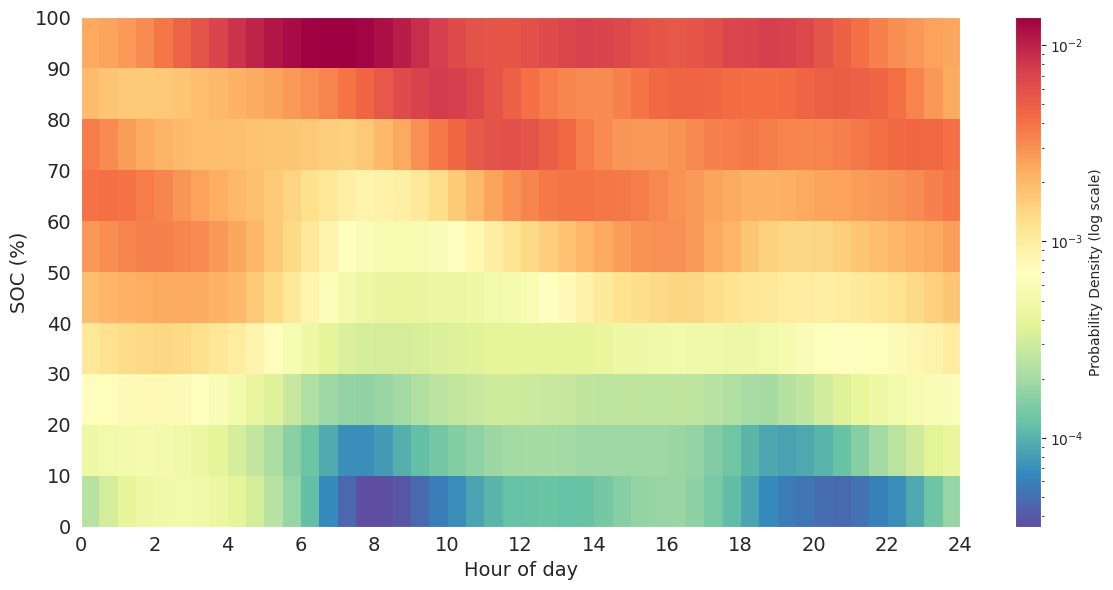

In [79]:
# 4. 计算直方图
if len(all_hours) > 0:
    H, xedges, yedges = np.histogram2d(all_hours, all_socs, bins=[48, 10],
                                        range=[[0, 24], [0, 100]])

    # 归一化为比例
    H_density = H / H.sum()

    # 关键：将 0 值替换为很小的值（比如最小非零值的 1%），这样空白区域也能显示浅色
    min_nonzero = H_density[H_density > 0].min()
    H_density[H_density == 0] = min_nonzero * 0.01 # 空白区域显示为很浅的颜色

    # 5. 绘图（使用 imshow 而不是 hist2d，可以更好地控制空白区域）
    plt.figure(figsize=(12, 6), facecolor='white')

    # 使用 imshow，extent 指定坐标范围
    h = plt.imshow(H_density.T, origin='lower', aspect='auto',
                   extent=[0, 24, 0, 100],
                   cmap='Spectral_r',
                   norm=LogNorm(vmin=H_density.min(), vmax=H_density.max()))

    plt.colorbar(h, label='Probability Density (log scale)')
    #plt.title('SOC Spectrum Density Heatmap (24h Profile)', fontsize=15)
    plt.xlabel('Hour of day', fontsize=14)
    plt.ylabel('SOC (%)', fontsize=14)
    plt.xticks(range(0, 25, 2),fontsize=14)
    plt.yticks(range(0, 110, 10),fontsize=14)
    plt.axis
    plt.grid(False)

    plt.tight_layout()
    plt.show()
else:
    print("No data points generated.")

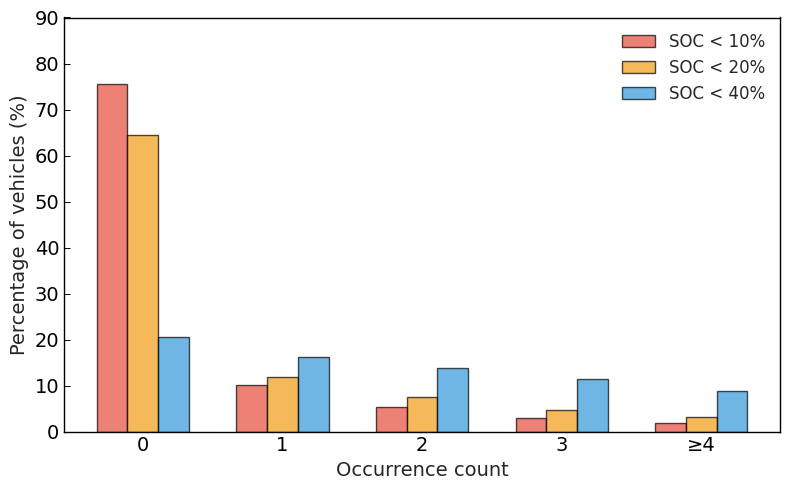


Summary (Total vehicles: 15853):

SOC < 10%:
  Vehicles with low SOC: 3863 (24.4%)
  Vehicles never low: 11990 (75.6%)
  Average occurrences (among those with low SOC): 2.79

SOC < 20%:
  Vehicles with low SOC: 5619 (35.4%)
  Vehicles never low: 10234 (64.6%)
  Average occurrences (among those with low SOC): 3.36

SOC < 40%:
  Vehicles with low SOC: 12585 (79.4%)
  Vehicles never low: 3268 (20.6%)
  Average occurrences (among those with low SOC): 4.57


In [81]:
# 1. 读取数据
df = battery_trace_output.copy()

# 2. 定义阈值
thresholds = [10, 20, 40]
colors = ['#e74c3c', '#f39c12', '#3498db']  # 红、橙、蓝
labels = ['SOC < 10%', 'SOC < 20%', 'SOC < 40%']

# 3. 统计每个阈值下的分布
total_vehicles = df['taxiid'].nunique()
all_distributions = {}

for threshold in thresholds:
    # 筛选SOC低于阈值的记录
    low_soc_events = df[df['SOC_before_pct'] < threshold].copy()

    # 统计每辆车出现的次数
    low_soc_counts = low_soc_events.groupby('taxiid').size().reset_index(name='count')
    vehicles_with_low_soc = len(low_soc_counts)
    vehicles_never_low = total_vehicles - vehicles_with_low_soc

    # 创建完整的分布
    count_distribution = low_soc_counts['count'].value_counts().sort_index()

    # 合并>5的情况
    count_distribution_merged = count_distribution[count_distribution.index <= 5].copy()
    if len(count_distribution[count_distribution.index > 5]) > 0:
        count_distribution_merged[6] = count_distribution[count_distribution.index > 5].sum()

    # 添加0次的情况
    if 0 not in count_distribution_merged.index:
        count_distribution_merged[0] = vehicles_never_low
    count_distribution_merged = count_distribution_merged.sort_index()

    # 计算百分比
    count_distribution_pct = (count_distribution_merged / total_vehicles * 100).sort_index()
    all_distributions[threshold] = count_distribution_pct

# 4. 绘图
plt.figure(figsize=(8, 5), facecolor='white')
ax = plt.gca()
ax.set_facecolor('white')

# 横坐标位置和标签
x_positions = [0, 1, 2, 3, 4]
x_labels = ['0', '1', '2', '3', '≥4']

# 设置柱状图宽度和位置
width = 0.22
x_base = np.array(x_positions)

# 绘制三个阈值的柱状图
for i, threshold in enumerate(thresholds):
    dist = all_distributions[threshold]
    # 确保所有位置都有值（如果没有则补0）
    values = [dist.get(x, 0) for x in x_positions]
    plt.bar(x_base + i * width, values, width=width,
            label=labels[i], color=colors[i], edgecolor='black', alpha=0.7)

plt.xlabel('Occurrence count', fontsize=14)
plt.ylabel('Percentage of vehicles (%)', fontsize=14)
plt.xticks(x_base + width, x_labels,fontsize=14)  # 刻度居中
plt.yticks(range(0, 100, 10),fontsize=14)
plt.legend(fontsize=12, frameon=False)
plt.grid(False)

# 移除顶部和右侧边框
#ax.spines['top'].set_visible(False)
#ax.spines['right'].set_visible(False)
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(1)
ax.tick_params(axis='both', which='major', direction='in', length=4, width=0.7, colors='black', left=True)
plt.tight_layout()
plt.show()

# 打印统计摘要
print(f"\nSummary (Total vehicles: {total_vehicles}):")
for i, threshold in enumerate(thresholds):
    low_soc_events = df[df['SOC_before_pct'] < threshold].copy()
    low_soc_counts = low_soc_events.groupby('taxiid').size().reset_index(name='count')
    vehicles_with_low_soc = len(low_soc_counts)
    vehicles_never_low = total_vehicles - vehicles_with_low_soc
    avg_count = low_soc_counts['count'].mean() if len(low_soc_counts) > 0 else 0

    print(f"\nSOC < {threshold}%:")
    print(f"  Vehicles with low SOC: {vehicles_with_low_soc} ({vehicles_with_low_soc/total_vehicles*100:.1f}%)")
    print(f"  Vehicles never low: {vehicles_never_low} ({vehicles_never_low/total_vehicles*100:.1f}%)")
    print(f"  Average occurrences (among those with low SOC): {avg_count:.2f}")

In [147]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. 数据预处理
df = battery_trace_output.copy()
df['start_time'] = pd.to_datetime(df['start_time'])
df['end_time'] = pd.to_datetime(df['end_time'])
df['date'] = df['start_time'].dt.date

# 2. 定义 SOC 区间
bins = [0, 20, 50, 80, 100]
labels = ['0-20%', '20-50%', '50-80%', '>80%']
colors = ['#e74c3c', '#f39c12', '#3498db', '#2ecc71']

# 3. 计算放电段的时长占比
results = []
for tid, group in df.groupby('taxiid'):
    group = group.sort_values('start_time').reset_index(drop=True)
    for i in range(1, len(group)):
        prev_end = group.iloc[i-1]['end_time']
        curr_start = group.iloc[i]['start_time']
        duration = (curr_start - prev_end).total_seconds()

        # 过滤掉异常间隔（如跨度太大或负值）
        if duration <= 0 or duration > 86400: continue

        s_high = group.iloc[i-1]['SOC_after_pct']
        s_low = group.iloc[i]['SOC_before_pct']

        # 线性插值计算各区间时长
        if s_high <= s_low: continue

        bin_times = {}
        for j in range(len(bins)-1):
            L, H = bins[j], bins[j+1]
            overlap_low, overlap_high = max(s_low, L), min(s_high, H)
            if overlap_low < overlap_high:
                bin_times[labels[j]] = (overlap_high - overlap_low) / (s_high - s_low) * duration
            else:
                bin_times[labels[j]] = 0

        results.append({'date': prev_end.date(), 'taxiid': tid, **bin_times, 'total_discharge_time': duration})

# 4. 统计每日平均占比
res_df = pd.DataFrame(results)
daily_taxi_stats = res_df.groupby(['date', 'taxiid']).sum().reset_index()

for label in labels:
    daily_taxi_stats[label] = (daily_taxi_stats[label] / daily_taxi_stats['total_discharge_time']) * 100

daily_avg = daily_taxi_stats.groupby('date')[labels].mean()



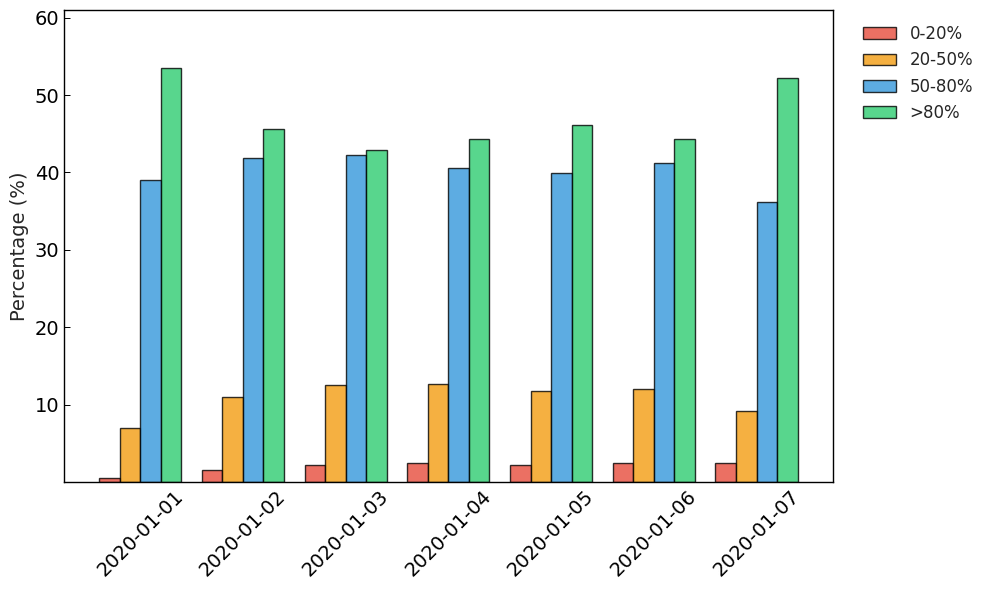

In [148]:
# ... 前面计算 daily_avg 的代码保持不变 ...
import datetime
target_date_to_remove = datetime.date(2020, 1, 8)
# 只有当日期不在要删除的列表中时才保留
daily_avg = daily_avg[daily_avg.index != target_date_to_remove]

# --- 2.
# 5. 绘制分组柱状图 (对数坐标)
plt.figure(figsize=(10, 6), facecolor='white')
ax = plt.gca()
ax.set_facecolor('white')
x = np.arange(len(daily_avg))
width = 0.2  # 柱子宽度

for i, label in enumerate(labels):
    # 使用对数轴，0.1% 也能看得清清楚楚
    plt.bar(x + i*width, daily_avg[label], width=width, label=label,
            color=colors[i], edgecolor='black', alpha=0.8)

# 设置 Y 轴为对数刻度
#plt.yscale('log')
# 设置 Y 轴范围，从 0.05% 开始显示，上限 100%
plt.ylim(0.0005, 61)
ax.tick_params(axis='both', which='major', direction='in', length=4, width=0.7, colors='black', left=True)
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(1)

# 修改坐标轴标签
plt.xticks(x + width*1.5, [str(d) for d in daily_avg.index], rotation=45,fontsize=14)
plt.yticks(fontsize=14)
plt.ylabel('Percentage (%)', fontsize=14)
#plt.title('Comparison of SOC Range Durations (Log Scale)', fontsize=14)
plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1), frameon=False,fontsize=12)

# 设置对数坐标下的网格线
plt.grid(True, which="both", ls=":", alpha=0.5)

plt.tight_layout()
plt.show()

## Leaving station

In [ ]:

MAX_TRACKING_MINUTES = 30  # Only track 30 minutes after leaving
MAX_TRACKING_SECONDS = MAX_TRACKING_MINUTES * 60

# Time bins for distribution (in seconds)
TIME_BINS = [0, 300, 600, 1200, 1800, float('inf')]  # 0-5min, 5-10min, 10-20min, 20-30min, >30min
TIME_LABELS = ['0-5min', '5-10min', '10-20min', '20-30min', '>30min']

def get_pickup_time_after_charging(taxiid, charging_events, tracks_dir):
    """
    For each charging event, find the first pickup (passenger > 0) after leaving the station.
    Only track for MAX_TRACKING_MINUTES minutes.

    Returns: List of dicts with charge_type and pickup_delay_seconds
    """
    try:
        if charging_events.empty:
            return []

        # Load trajectory data for this vehicle
        track_path = Path(tracks_dir) / f'taxiid={taxiid}'
        if not track_path.exists():
            return []

        track_files = list(track_path.glob('*.parquet'))
        if not track_files:
            return []

        # Read and concatenate all trajectory files
        track_parts = []
        for f in track_files:
            try:
                df = pd.read_parquet(f, columns=['time', 'passenger'])
                if not df.empty:
                    track_parts.append(df)
            except Exception as e:
                logging.warning(f"{taxiid}: Failed to read {f.name}: {e}")
                continue

        if not track_parts:
            return []

        track_df = pd.concat(track_parts, ignore_index=True)

        # Ensure time is datetime - handle both datetime and numeric timestamps
        if not pd.api.types.is_datetime64_any_dtype(track_df['time']):
            # If time is numeric (Unix timestamp), convert to datetime
            if track_df['time'].dtype in [np.int64, np.int32, np.float64, np.float32]:
                track_df['time'] = pd.to_datetime(track_df['time'], unit='s', errors='coerce')
            else:
                track_df['time'] = pd.to_datetime(track_df['time'], errors='coerce')

        # Remove any invalid timestamps
        track_df = track_df[track_df['time'].notna()].copy()
        if track_df.empty:
            return []

        track_df = track_df.sort_values('time').reset_index(drop=True)

        # Find all pickup times (passenger > 0)
        pickup_mask = track_df['passenger'] > 0
        pickup_times = track_df.loc[pickup_mask, 'time'].values

        if len(pickup_times) == 0:
            # No pickups found, return None for all events
            return [{
                'taxiid': taxiid,
                'charge_type': row['charge_type'],
                'pickup_delay_seconds': None
            } for _, row in charging_events.iterrows()]

        # Ensure pickup_times is datetime64 array
        if not pd.api.types.is_datetime64_any_dtype(pd.Series(pickup_times)):
            pickup_times = pd.to_datetime(pickup_times, errors='coerce')
            pickup_times = pickup_times[pd.notna(pickup_times)]

        results = []
        for _, event in charging_events.iterrows():
            end_time = event['end_time']
            charge_type = event['charge_type']

            # Ensure end_time is datetime
            if not isinstance(end_time, pd.Timestamp):
                if pd.api.types.is_numeric_dtype(type(end_time)) or isinstance(end_time, (int, float)):
                    end_time = pd.to_datetime(end_time, unit='s', errors='coerce')
                else:
                    end_time = pd.to_datetime(end_time, errors='coerce')

            if pd.isna(end_time):
                results.append({
                    'taxiid': taxiid,
                    'charge_type': charge_type,
                    'pickup_delay_seconds': None
                })
                continue

            # Find first pickup after end_time using pandas operations (more robust)
            # Filter pickups after end_time
            after_mask = pickup_times > end_time
            if not after_mask.any():
                # No pickup found after this charging event
                results.append({
                    'taxiid': taxiid,
                    'charge_type': charge_type,
                    'pickup_delay_seconds': None
                })
                continue

            # Get the first pickup time after end_time
            pickup_time = pickup_times[after_mask][0]
            delay_seconds = (pickup_time - end_time).total_seconds()

            # Only count if within tracking window
            if delay_seconds <= MAX_TRACKING_SECONDS:
                results.append({
                    'taxiid': taxiid,
                    'charge_type': charge_type,
                    'pickup_delay_seconds': delay_seconds
                })
            else:
                # Pickup is beyond tracking window
                results.append({
                    'taxiid': taxiid,
                    'charge_type': charge_type,
                    'pickup_delay_seconds': None  # Beyond 30 minutes
                })

        return results

    except Exception as e:
        logging.error(f"{taxiid}: Error processing: {e}")
        import traceback
        logging.error(traceback.format_exc())
        return []


# Main analysis
print("=" * 60)
print("Analyzing pickup times after leaving charging stations")
print("=" * 60)

# Load charging events
if Path(BATTERY_TRACE_FILE).exists():
    battery_trace = pd.read_parquet(BATTERY_TRACE_FILE)
    #battery_trace = battery_trace[:2].copy()
    print(f"Loaded battery_trace: {len(battery_trace)} events")

    # Extract charging events with end_time and charge_type
    charging_events = battery_trace[['taxiid', 'end_time', 'charge_type']].copy()

    # Ensure end_time is datetime
    if not pd.api.types.is_datetime64_any_dtype(charging_events['end_time']):
        # Try to convert - handle both datetime strings and numeric timestamps
        if charging_events['end_time'].dtype in [np.int64, np.int32, np.float64, np.float32]:
            charging_events['end_time'] = pd.to_datetime(charging_events['end_time'], unit='s', errors='coerce')
        else:
            charging_events['end_time'] = pd.to_datetime(charging_events['end_time'], errors='coerce')

    # Remove rows with invalid end_time
    charging_events = charging_events[charging_events['end_time'].notna()].copy()

    print(f"Processing {charging_events['taxiid'].nunique()} vehicles")

    # Process each vehicle
    all_results = []
    grouped = charging_events.groupby('taxiid')

    with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
        futures = {
            executor.submit(get_pickup_time_after_charging, taxiid, group, TRACKS_DIR): taxiid
            for taxiid, group in grouped
        }

        for future in tqdm(as_completed(futures), total=len(futures), desc="Processing vehicles"):
            taxiid = futures[future]
            try:
                results = future.result()
                if results:
                    all_results.extend(results)
            except Exception as e:
                logging.error(f"{taxiid}: Task failed: {e}")

    # Convert to DataFrame
    results_df = pd.DataFrame(all_results)

    print(f"\nTotal events processed: {len(results_df)}")
    print(f"Events with pickup within 30min: {results_df['pickup_delay_seconds'].notna().sum()}")
    print(f"Events without pickup or beyond 30min: {results_df['pickup_delay_seconds'].isna().sum()}")

    # Categorize delays
    # For None values (no pickup or >30min), assign to '>30min' category
    results_df['delay_category'] = pd.cut(
        results_df['pickup_delay_seconds'].fillna(MAX_TRACKING_SECONDS + 1),
        bins=TIME_BINS,
        labels=TIME_LABELS,
        include_lowest=True
    )

    # Replace category for None values
    results_df.loc[results_df['pickup_delay_seconds'].isna(), 'delay_category'] = '>30min'

    # Count distribution by charge_type
    distribution = results_df.groupby(['charge_type', 'delay_category']).size().unstack(fill_value=0)
    distribution_pct = distribution.div(distribution.sum(axis=1), axis=0) * 100

    print("\n" + "=" * 60)
    print("Distribution of pickup times after leaving charging stations")
    print("=" * 60)
    print("\nCount:")
    print(distribution)
    print("\nPercentage:")
    print(distribution_pct.round(2))

    # Summary statistics
    print("\n" + "=" * 60)
    print("Summary Statistics (only for pickups within 30 minutes)")
    print("=" * 60)

    valid_delays = results_df[results_df['pickup_delay_seconds'].notna()]

    if len(valid_delays) > 0:
        for charge_type in ['distributed', 'centralized']:
            type_data = valid_delays[valid_delays['charge_type'] == charge_type]['pickup_delay_seconds']
            if len(type_data) > 0:
                print(f"\n{charge_type.capitalize()} charging:")
                print(f"  Count: {len(type_data)}")
                print(f"  Mean: {type_data.mean()/60:.2f} minutes")
                print(f"  Median: {type_data.median()/60:.2f} minutes")
                print(f"  Std: {type_data.std()/60:.2f} minutes")

    # Save results
    output_file = Path(OUTPUT_DIR) / 'pickup_delay_analysis.parquet'
    results_df.to_parquet(output_file, index=False)
    print(f"\nResults saved to: {output_file}")

    # Save distribution summary
    summary_file = Path(OUTPUT_DIR) / 'pickup_delay_distribution.csv'
    distribution.to_csv(summary_file)
    print(f"Distribution summary saved to: {summary_file}")

else:
    print(f"Error: {BATTERY_TRACE_FILE} not found")

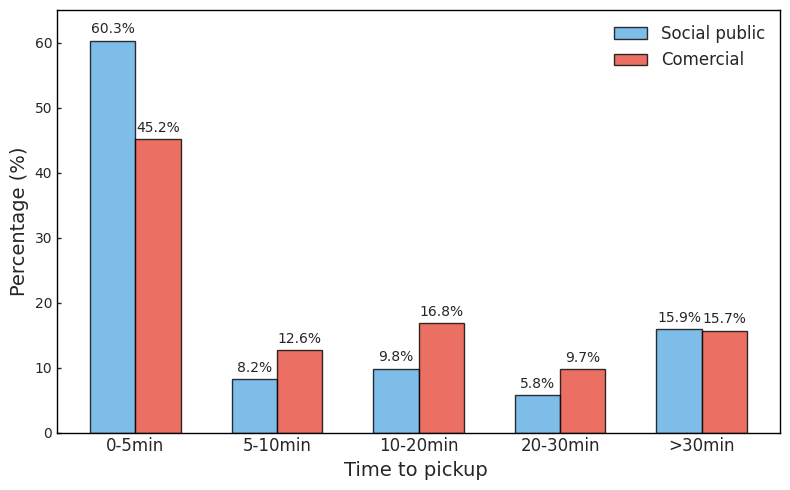

In [152]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. 加载数据
results_df = pd.read_parquet('output_v5/pickup_delay_analysis.parquet')

# 2. 数据处理
distribution = results_df.groupby(['charge_type', 'delay_category'], observed=True).size().unstack(fill_value=0)
TIME_LABELS = ['0-5min', '5-10min', '10-20min', '20-30min', '>30min']

# 计算百分比
distribution_pct = distribution.div(distribution.sum(axis=1), axis=0) * 100

# 3. 绘图设置
fig, ax = plt.subplots(figsize=(8, 5), facecolor='white')
ax.set_facecolor('white')

x = np.arange(len(TIME_LABELS))
width = 0.32  # 柱子宽度

# 提取数据
dist_vals = distribution_pct.loc['distributed', TIME_LABELS].values
cent_vals = distribution_pct.loc['centralized', TIME_LABELS].values

# 4. 绘制分组柱状图
rects1 = ax.bar(x - width/2, dist_vals, width, label='Social public',
                color='#5DADE2', edgecolor='black', alpha=0.8)
rects2 = ax.bar(x + width/2, cent_vals, width, label='Comercial',
                color='#E74C3C', edgecolor='black', alpha=0.8)

# 5. 添加百分比标签
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.1f}%',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3点纵向偏移
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=10)

autolabel(rects1)
autolabel(rects2)

# 6. 装饰与美化
ax.set_ylabel('Percentage (%)', fontsize=14)
ax.set_xlabel('Time to pickup ', fontsize=14)
# ax.set_title('Comparison of Pickup Delay: Distributed vs Centralized', fontsize=16, pad=20)
ax.set_xticks(x)
ax.set_xticklabels(TIME_LABELS, fontsize=12)
ax.set_ylim(0,65)
ax.legend(fontsize=12, frameon=False)
#ax.tick_params(axis='both', which='major', direction='in', length=4, width=0.7, colors='black', left=True)

# 移除网格和调整边框
ax.grid(False)
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(1.0)

# 显式设置刻度线
ax.tick_params(axis='both', which='major', direction='in', length=3, width=1.0, left =True)

plt.tight_layout()
plt.show()

## POI analysis


In [44]:
import pandas as pd
import numpy as np
from scipy.spatial.distance import cdist

cent_charging_events_merge= cent_charging_events.copy()

# 提取合并前站的经纬度
old_station_coords = sz_stations_df[['lon', 'lat']].values
# 提取合并后站的经纬度
new_station_coords = merged_stations[['lon', 'lat']].values

# 计算距离矩阵
distances = cdist(old_station_coords, new_station_coords, metric='euclidean')

# 找到每个旧站对应的最近新站
nearest_new_indices = np.argmin(distances, axis=1)
station_mapping = dict(zip(
    sz_stations_df['station_id'].values,
    merged_stations.iloc[nearest_new_indices]['station_id'].values
))

print(f"\n站ID映射关系: {len(station_mapping)} 个")

# 3. 映射cent充电事件的站ID
cent_charging_events_merge['merged_station_id'] = cent_charging_events_merge['nearest_station_id'].map(station_mapping)

# 检查是否有未映射的
unmapped = cent_charging_events_merge['merged_station_id'].isna().sum()
if unmapped > 0:
    print(f"警告: {unmapped} 个充电事件无法映射到合并后的站")
    # 可以选择删除或保留
    cent_charging_events_merge = cent_charging_events_merge[cent_charging_events_merge['merged_station_id'].notna()]

# # 更新nearest_station_id为合并后的ID
cent_charging_events_merge['nearest_station_id'] = cent_charging_events_merge['merged_station_id']
# cent_charging_events['charge_type'] = 'centralized'
# dist_charging_events['charge_type'] = 'distributed'


站ID映射关系: 1791 个


In [24]:
cent_charging_events_merge['merged_station_id'].nunique()

682

In [26]:
cent_charging_events_merge.head()

,taxiid,start_time,end_time,duration_s,start_lon,start_lat,in_sz,nearest_station_id,distance_to_station_m,is_cent_char,merged_station_id
0,UUUB0C0M7,2020-01-01 04:17:29,2020-01-01 05:48:13,5444.0,114.143974,22.557758,True,3383,177.351840,True,3383
1,UUUB0C0M7,2020-01-01 16:18:31,2020-01-01 17:47:47,5356.0,114.143753,22.557638,True,3383,152.227049,True,3383
2,UUUB0C0M7,2020-01-02 04:16:24,2020-01-02 05:41:39,5115.0,114.143974,22.557781,True,3383,177.993366,True,3383
3,UUUB0C0M7,2020-01-02 16:09:34,2020-01-02 17:32:36,4982.0,114.143990,22.557774,True,3383,179.291552,True,3383
4,UUUB0C0M7,2020-01-03 04:33:40,2020-01-03 05:44:59,4279.0,114.143890,22.557579,True,3383,165.006212,True,3383


In [51]:
cent_charging_events_merge.to_parquet(f'{OUTPUT_DIR}/commercial_charging_events_mergestat.parquet')

=== 不同POI类型下两种充电的分布分析 ===

--- 1. 不同POI类型下两种充电的次数分布 ---

各POI类型下的充电次数统计（前15个）:
             poi_type  centralized_count  distributed_count  total_count  \
0        life_service             454952             247528       702480   
1  company_enterprise             184682              75412       260094   
4         real_estate              40346              19130        59476   
2        auto_service              33216              19352        52568   
3  tourist_attraction              34234              10064        44298   
5     natural_feature               2046               4502         6548   

   centralized_ratio  distributed_ratio  station_count  
0           0.647637           0.352363           3830  
1           0.710059           0.289941           1282  
4           0.678358           0.321642            386  
2           0.631867           0.368133            272  
3           0.772811           0.227189            206  
5           0.312462           0.687538       

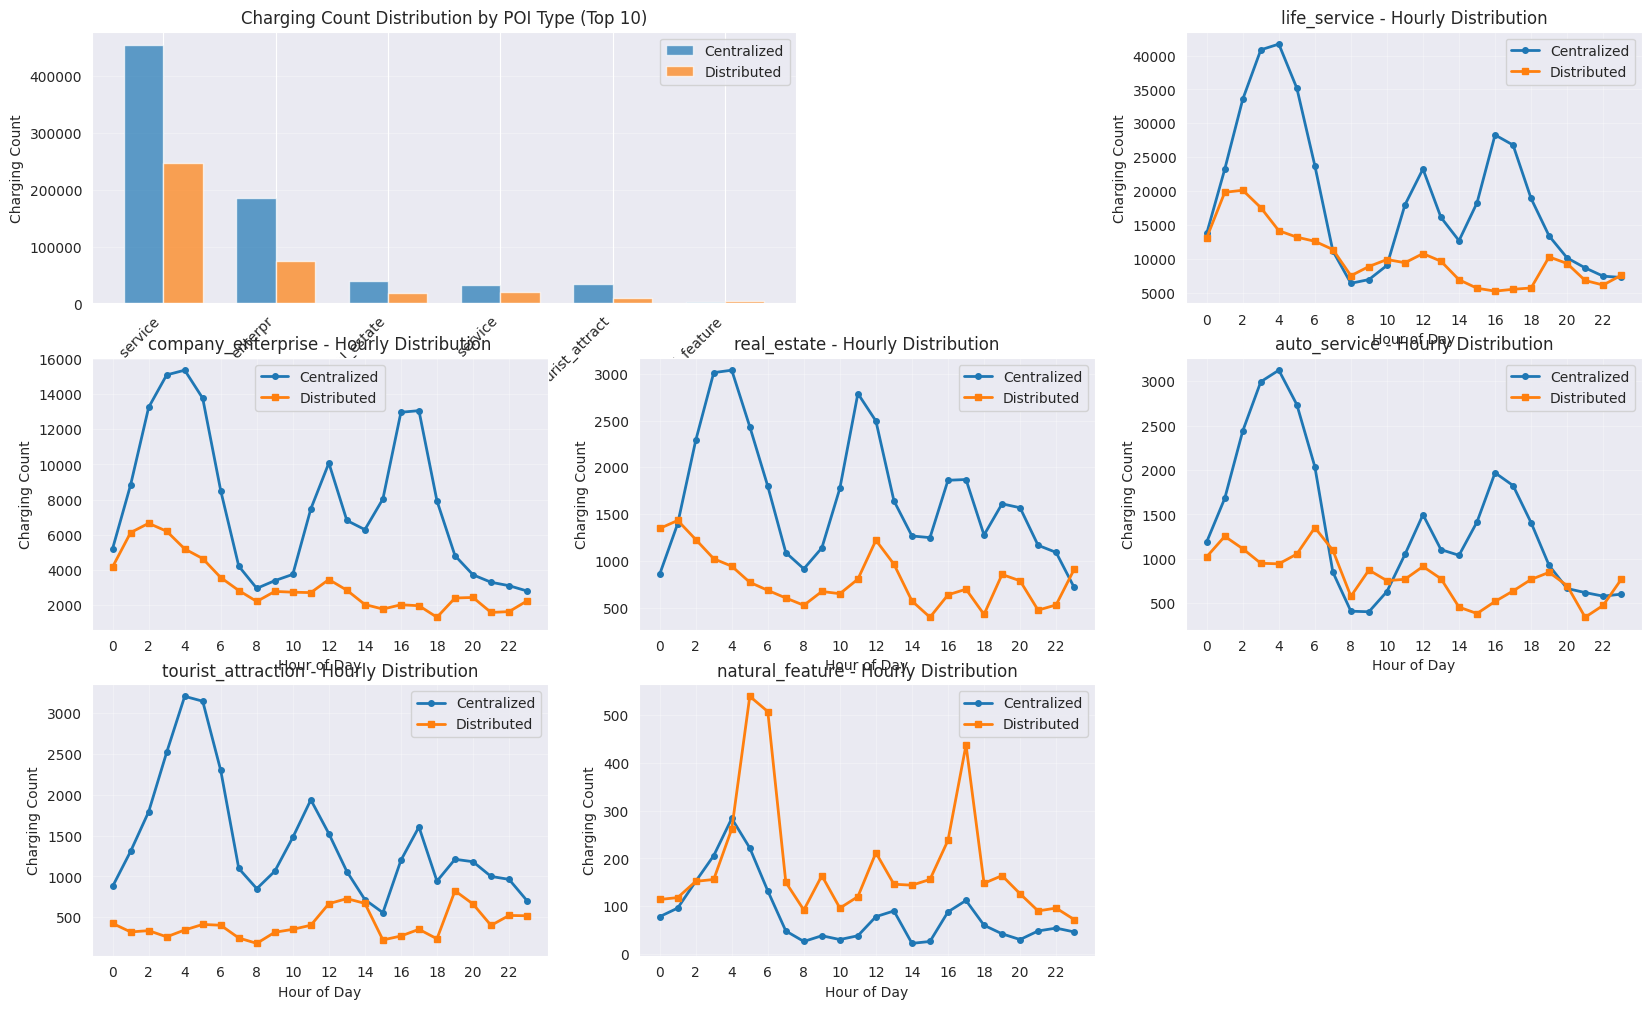

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import rcParams

# 设置中文字体（如果需要）
# plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS']
# plt.rcParams['axes.unicode_minus'] = False

# 1. 加载数据
poi_result = pd.read_csv('POI_result.csv')
poi_type_cols = [col for col in poi_result.columns if col != 'station_id']



cent_charging_events_merge['charge_type'] = 'centralized'
dist_charging_events['charge_type'] = 'distributed'
all_charging = pd.concat([cent_charging_events_merge, dist_charging_events], ignore_index=True)

# 提取小时
all_charging['hour'] = pd.to_datetime(all_charging['start_time']).dt.hour

print("=== 不同POI类型下两种充电的分布分析 ===\n")

# 2. 合并POI数据
charging_with_poi = all_charging.merge(
    poi_result,
    left_on='nearest_station_id',
    right_on='station_id',
    how='left'
)

# 3. 统计不同POI类型下两种充电的次数分布
print("--- 1. 不同POI类型下两种充电的次数分布 ---\n")

poi_charging_stats = []

for poi_type in poi_type_cols:
    # 筛选有该POI类型的充电站
    stations_with_poi = poi_result[poi_result[poi_type] > 0]['station_id'].values

    # 统计这些充电站的充电事件
    charging_in_poi = charging_with_poi[charging_with_poi['nearest_station_id'].isin(stations_with_poi)]

    if len(charging_in_poi) > 0:
        centralized_count = len(charging_in_poi[charging_in_poi['charge_type'] == 'centralized'])
        distributed_count = len(charging_in_poi[charging_in_poi['charge_type'] == 'distributed'])
        total_count = len(charging_in_poi)

        poi_charging_stats.append({
            'poi_type': poi_type,
            'centralized_count': centralized_count,
            'distributed_count': distributed_count,
            'total_count': total_count,
            'centralized_ratio': centralized_count / total_count if total_count > 0 else 0,
            'distributed_ratio': distributed_count / total_count if total_count > 0 else 0,
            'station_count': len(stations_with_poi),
            'avg_poi_count': poi_result[poi_result[poi_type] > 0][poi_type].mean()
        })

poi_stats_df = pd.DataFrame(poi_charging_stats).sort_values('total_count', ascending=False)

print("各POI类型下的充电次数统计（前15个）:")
print(poi_stats_df.head(15)[['poi_type', 'centralized_count', 'distributed_count',
                              'total_count', 'centralized_ratio', 'distributed_ratio', 'station_count']])

# 4. 统计不同POI类型下两种充电的时间分布
print("\n--- 2. 不同POI类型下两种充电的时间分布（按小时）---\n")

# 选择出现频率较高的POI类型进行分析
top_poi_types = poi_stats_df.head(10)['poi_type'].values

time_distribution = []

for poi_type in top_poi_types:
    stations_with_poi = poi_result[poi_result[poi_type] > 0]['station_id'].values
    charging_in_poi = charging_with_poi[charging_with_poi['nearest_station_id'].isin(stations_with_poi)]

    if len(charging_in_poi) > 0:
        # 按小时和充电类型统计
        hourly = charging_in_poi.groupby(['hour', 'charge_type']).size().unstack(fill_value=0)

        for hour in range(24):
            centralized_hour = hourly.get('centralized', pd.Series()).get(hour, 0)
            distributed_hour = hourly.get('distributed', pd.Series()).get(hour, 0)

            time_distribution.append({
                'poi_type': poi_type,
                'hour': hour,
                'centralized_count': centralized_hour,
                'distributed_count': distributed_hour,
                'total_count': centralized_hour + distributed_hour
            })

time_dist_df = pd.DataFrame(time_distribution)

# 5. 可视化
fig = plt.figure(figsize=(20, 12))

# 5.1 充电次数分布（前10个POI类型）
ax1 = plt.subplot(3, 2, 1)
top_10 = poi_stats_df.head(10)
x_pos = np.arange(len(top_10))
width = 0.35
ax1.bar(x_pos - width/2, top_10['centralized_count'], width, label='Centralized', alpha=0.7)
ax1.bar(x_pos + width/2, top_10['distributed_count'], width, label='Distributed', alpha=0.7)
ax1.set_xlabel('POI Type')
ax1.set_ylabel('Charging Count')
ax1.set_title('Charging Count Distribution by POI Type (Top 10)')
ax1.set_xticks(x_pos)
ax1.set_xticklabels([col[:15] for col in top_10['poi_type'].values], rotation=45, ha='right')
ax1.legend()
ax1.grid(True, alpha=0.3, axis='y')

# 5.2 充电比例分布
# ax2 = plt.subplot(3, 2, 2)
# ax2.bar(x_pos - width/2, top_10['centralized_ratio'], width, label='Centralized', alpha=0.7)
# ax2.bar(x_pos + width/2, top_10['distributed_ratio'], width, label='Distributed', alpha=0.7)
# ax2.set_xlabel('POI Type')
# ax2.set_ylabel('Charging Ratio')
# ax2.set_title('Charging Ratio Distribution by POI Type (Top 10)')
# ax2.set_xticks(x_pos)
# ax2.set_xticklabels([col[:15] for col in top_10['poi_type'].values], rotation=45, ha='right')
# ax2.legend()
# ax2.set_ylim(0, 1)
# ax2.grid(True, alpha=0.3, axis='y')

# 5.3-5.6 时间分布（选择6个主要POI类型）
top_6_poi = top_poi_types[:6]
for idx, poi_type in enumerate(top_6_poi):
    ax = plt.subplot(3, 3, 3 + idx)

    poi_time = time_dist_df[time_dist_df['poi_type'] == poi_type]

    ax.plot(poi_time['hour'], poi_time['centralized_count'],
            marker='o', label='Centralized', linewidth=2, markersize=4)
    ax.plot(poi_time['hour'], poi_time['distributed_count'],
            marker='s', label='Distributed', linewidth=2, markersize=4)

    ax.set_xlabel('Hour of Day')
    ax.set_ylabel('Charging Count')
    ax.set_title(f'{poi_type[:20]} - Hourly Distribution')
    ax.set_xticks(range(0, 24, 2))
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
# plt.savefig('poi_charging_distribution.png', dpi=150, bbox_inches='tight')
# print("图表已保存为 poi_charging_distribution.png")

# 6. 详细时间分布表格
print("\n--- 详细时间分布（前5个POI类型，按小时）---\n")

for poi_type in top_poi_types[:5]:
    print(f"\n{poi_type}:")
    poi_time = time_dist_df[time_dist_df['poi_type'] == poi_type]

    # 创建透视表
    pivot_table = poi_time.pivot_table(
        index='hour',
        values=['centralized_count', 'distributed_count', 'total_count'],
        aggfunc='sum'
    )

    print(pivot_table.head(12))  # 显示前12小时

# 7. 统计摘要
print("\n=== 统计摘要 ===")
print(f"\n1. 总充电事件数:")
print(f"   集中式: {len(all_charging[all_charging['charge_type'] == 'centralized'])}")
print(f"   分布式: {len(all_charging[all_charging['charge_type'] == 'distributed'])}")

print(f"\n2. 有POI数据的充电站数: {len(poi_result)}")
print(f"   有充电事件的充电站数: {charging_with_poi['nearest_station_id'].nunique()}")

print(f"\n3. 各POI类型覆盖的充电站数:")
print(poi_stats_df[['poi_type', 'station_count', 'total_count']].head(10))

print(f"\n4. 充电比例:")
print(f"   集中式平均比例: {poi_stats_df['centralized_ratio'].mean():.4f}")
print(f"   分布式平均比例: {poi_stats_df['distributed_ratio'].mean():.4f}")

# 8. 时间分布统计
print(f"\n5. 时间分布特征:")
for poi_type in top_poi_types[:4]:
    poi_time = time_dist_df[time_dist_df['poi_type'] == poi_type]
    cent_peak_hour = poi_time.loc[poi_time['centralized_count'].idxmax(), 'hour']
    dist_peak_hour = poi_time.loc[poi_time['distributed_count'].idxmax(), 'hour']

    print(f"\n   {poi_type}:")
    print(f"     集中式充电高峰时段: {cent_peak_hour}:00")
    print(f"     分布式充电高峰时段: {dist_peak_hour}:00")

In [43]:
import pandas as pd
import numpy as np
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


station_attraction = all_charging.groupby('nearest_station_id').agg(
    total_events=('taxiid', 'count')
).reset_index().rename(columns={'nearest_station_id': 'station_id'})

station_poi_attraction = poi_result.merge(station_attraction, on='station_id', how='inner')

print(f"分析样本数: {len(station_poi_attraction)} 个充电站\n")
print(f"充电总次数: {station_poi_attraction['total_events'].sum()}")
print(f"每站平均充电次数: {station_poi_attraction['total_events'].mean():.1f}")
print(f"每站充电次数中位数: {station_poi_attraction['total_events'].median():.1f}\n")

# =============================================
# 2. 逐个POI类型计算与充电次数的相关性
# =============================================
print("=" * 70)
print("逐个POI类型与充电吸引次数的相关性分析")
print("=" * 70)

correlation_results = []

for poi_col in poi_type_cols:
    x = station_poi_attraction[poi_col].values
    y = station_poi_attraction['total_events'].values

    if x.std() == 0:
        continue

    # Pearson相关系数
    r_pearson, p_pearson = stats.pearsonr(x, y)
    # Spearman秩相关系数（对非线性也敏感）
    r_spearman, p_spearman = stats.spearmanr(x, y)

    correlation_results.append({
        'poi_type': poi_col,
        'pearson_r': r_pearson,
        'pearson_p': p_pearson,
        'spearman_r': r_spearman,
        'spearman_p': p_spearman,
        'abs_pearson_r': abs(r_pearson),
        'abs_spearman_r': abs(r_spearman),
        'station_with_poi': (x > 0).sum(),
        'poi_mean': x.mean(),
    })

corr_df = pd.DataFrame(correlation_results).sort_values('abs_spearman_r', ascending=False)

print("\n所有POI类型与充电次数的相关性（按Spearman |r| 降序）:\n")
display_cols = ['poi_type', 'pearson_r', 'pearson_p', 'spearman_r', 'spearman_p', 'station_with_poi']
print(corr_df[display_cols].to_string(index=False, float_format=lambda x: f'{x:.4f}'))

# =============================================
# 3. 筛选显著相关的POI类型
# =============================================
SIGNIFICANCE = 0.05
MIN_ABS_R = 0.05  # Spearman |r| 阈值

sig_corr = corr_df[
    (corr_df['spearman_p'] < SIGNIFICANCE) &
    (corr_df['abs_spearman_r'] >= MIN_ABS_R)
].copy()

print(f"\n{'=' * 70}")
print(f"显著相关的POI类型 (p < {SIGNIFICANCE} 且 |Spearman r| >= {MIN_ABS_R}): {len(sig_corr)} 个")
print(f"{'=' * 70}\n")

if len(sig_corr) > 0:
    for _, row in sig_corr.iterrows():
        direction = "正相关" if row['spearman_r'] > 0 else "负相关"
        strength = "强" if abs(row['spearman_r']) > 0.3 else "中等" if abs(row['spearman_r']) > 0.1 else "弱"
        print(f"  {row['poi_type']:30s} | Spearman r={row['spearman_r']:+.4f} (p={row['spearman_p']:.2e}) | {strength}{direction}")
else:
    print("  没有找到显著相关的POI类型。")

# =============================================
# 4. 仅对相关性较强的POI类型画回归曲线
# =============================================
STRONG_R_THRESHOLD = 0.08  # 只画 |r| 较大的

strong_corr = sig_corr[sig_corr['abs_spearman_r'] >= STRONG_R_THRESHOLD].copy()

if len(strong_corr) == 0:
    strong_corr = sig_corr.head(6)
    print(f"\n没有 |r| >= {STRONG_R_THRESHOLD} 的POI类型，取Top 6 显著相关的类型画图。")

n_plots = min(len(strong_corr), 12)
strong_corr = strong_corr.head(n_plots)

if n_plots > 0:
    ncols = min(3, n_plots)
    nrows = int(np.ceil(n_plots / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows))
    if n_plots == 1:
        axes = np.array([axes])
    axes = axes.flatten()

    for idx, (_, row) in enumerate(strong_corr.iterrows()):
        ax = axes[idx]
        poi_col = row['poi_type']
        x = station_poi_attraction[poi_col].values
        y = station_poi_attraction['total_events'].values

        ax.scatter(x, y, alpha=0.25, s=15, color='steelblue', edgecolors='none')

        # OLS回归线
        mask = np.isfinite(x) & np.isfinite(y)
        slope, intercept, r_val, p_val, std_err = stats.linregress(x[mask], y[mask])
        x_line = np.linspace(x.min(), x.max(), 200)
        y_line = slope * x_line + intercept
        ax.plot(x_line, y_line, color='red', linewidth=2,
                label=f'OLS: y={slope:.2f}x+{intercept:.1f}')

        # LOWESS平滑曲线（捕捉非线性趋势）
        try:
            from statsmodels.nonparametric.smoothers_lowess import lowess
            sorted_idx = np.argsort(x)
            x_sorted, y_sorted = x[sorted_idx], y[sorted_idx]
            lowess_result = lowess(y_sorted, x_sorted, frac=0.3)
            ax.plot(lowess_result[:, 0], lowess_result[:, 1],
                    color='orange', linewidth=2, linestyle='--', label='LOWESS')
        except Exception:
            pass

        ax.set_xlabel(poi_col, fontsize=11)
        ax.set_ylabel('Charging Events', fontsize=11)
        ax.set_title(
            f'{poi_col}\nSpearman r={row["spearman_r"]:.4f}, p={row["spearman_p"]:.2e}',
            fontsize=11
        )
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)

    for idx in range(n_plots, len(axes)):
        axes[idx].set_visible(False)

    plt.tight_layout()
    plt.savefig('poi_charging_correlation_regression.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("\n图表已保存为 poi_charging_correlation_regression.png")

# =============================================
# 5. 相关性热力图（所有显著POI + 充电次数）
# =============================================
if len(sig_corr) > 0:
    heatmap_cols = sig_corr['poi_type'].tolist() + ['total_events']
    heatmap_data = station_poi_attraction[heatmap_cols]

    corr_matrix = heatmap_data.corr(method='spearman')

    fig, ax = plt.subplots(figsize=(max(8, len(heatmap_cols) * 0.6), max(6, len(heatmap_cols) * 0.5)))
    sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
                vmin=-0.3, vmax=0.3, ax=ax, linewidths=0.5,
                xticklabels=[c[:18] for c in corr_matrix.columns],
                yticklabels=[c[:18] for c in corr_matrix.index])
    ax.set_title('Spearman Correlation: Significant POI Types & Charging Events', fontsize=13)
    plt.tight_layout()
    plt.savefig('poi_charging_correlation_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("热力图已保存为 poi_charging_correlation_heatmap.png")

# =============================================
# 6. 总结
# =============================================
print("\n" + "=" * 70)
print("分析总结")
print("=" * 70)
print(f"\n分析了 {len(poi_type_cols)} 种POI类型与 {len(station_poi_attraction)} 个站的充电吸引次数的关系。\n")

if len(sig_corr) > 0:
    print(f"有 {len(sig_corr)} 种POI类型与充电次数显著相关 (p<{SIGNIFICANCE}, |r|>={MIN_ABS_R}):")
    for _, row in sig_corr.iterrows():
        direction = "↑ 正相关" if row['spearman_r'] > 0 else "↓ 负相关"
        print(f"  • {row['poi_type']:30s} Spearman r = {row['spearman_r']:+.4f}  {direction}")

    best = sig_corr.iloc[0]
    print(f"\n最强相关: {best['poi_type']} (r={best['spearman_r']:.4f})")
else:
    print("没有发现显著相关的POI类型，充电站的吸引力可能主要受其他因素影响（如地理位置、费用、充电桩数量等）。")

分析样本数: 3212 个充电站

充电总次数: 817234
每站平均充电次数: 254.4
每站充电次数中位数: 27.0

逐个POI类型与充电吸引次数的相关性分析

所有POI类型与充电次数的相关性（按Spearman |r| 降序）:

          poi_type  pearson_r  pearson_p  spearman_r  spearman_p  station_with_poi
   natural_feature    -0.0195     0.2687     -0.0359      0.0419                56
      life_service    -0.0375     0.0335      0.0349      0.0482              3000
      auto_service     0.0051     0.7744      0.0302      0.0870               206
tourist_attraction    -0.0140     0.4274     -0.0291      0.0994               154
       real_estate    -0.0215     0.2235     -0.0165      0.3489               296
company_enterprise    -0.0138     0.4329     -0.0013      0.9415               954

显著相关的POI类型 (p < 0.05 且 |Spearman r| >= 0.05): 0 个

  没有找到显著相关的POI类型。

没有 |r| >= 0.08 的POI类型，取Top 6 显著相关的类型画图。

分析总结

分析了 26 种POI类型与 3212 个站的充电吸引次数的关系。

没有发现显著相关的POI类型，充电站的吸引力可能主要受其他因素影响（如地理位置、费用、充电桩数量等）。


数量最多的6类POI: ['life_service', 'company_enterprise', 'real_estate', 'tourist_attraction', 'auto_service', 'natural_feature']


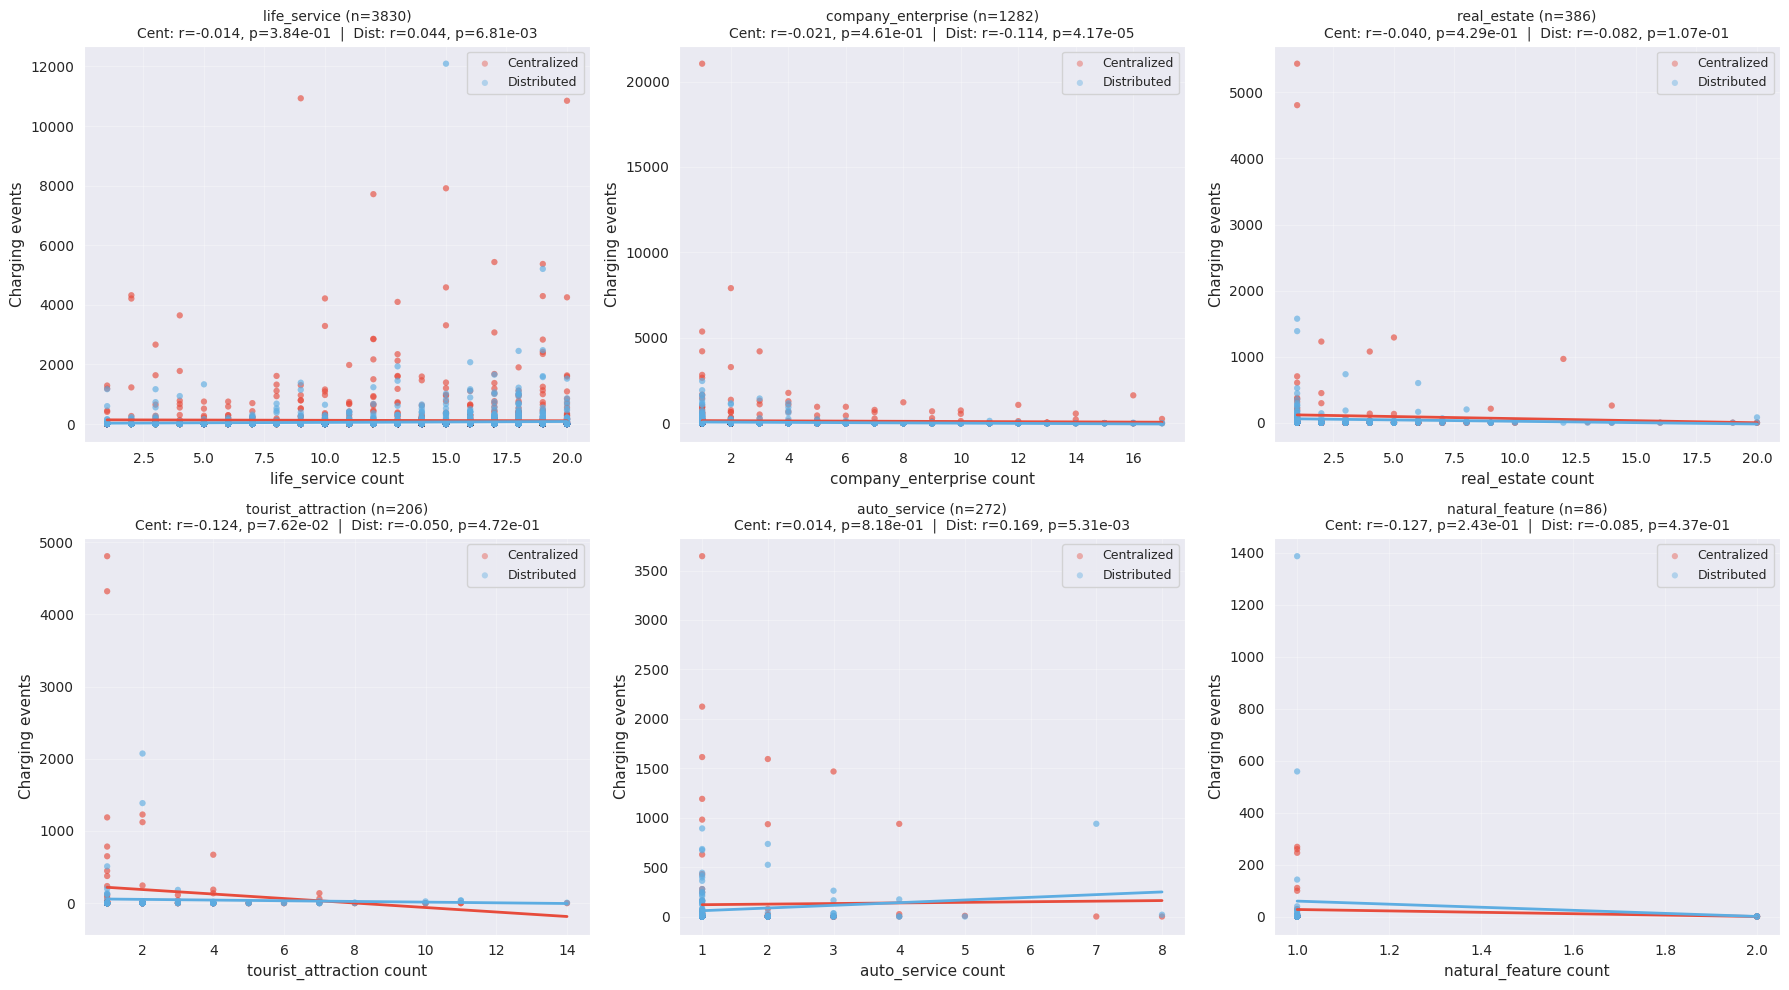

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# 1. 加载数据


# 2. 分别统计每站两类充电次数
cent_counts = cent_charging_events_merge.groupby('nearest_station_id').size().reset_index()
cent_counts.columns = ['station_id', 'centralized_events']

dist_counts = dist_charging_events.groupby('nearest_station_id').size().reset_index()
dist_counts.columns = ['station_id', 'distributed_events']

# 3. 合并
merged = poi_result.merge(cent_counts, on='station_id', how='left') \
                   .merge(dist_counts, on='station_id', how='left')
merged['centralized_events'] = merged['centralized_events'].fillna(0).astype(int)
merged['distributed_events'] = merged['distributed_events'].fillna(0).astype(int)

# 4. 选出数量最多的6类POI
poi_sums = merged[poi_type_cols].sum().sort_values(ascending=False)
top6 = poi_sums.head(6).index.tolist()
print("数量最多的6类POI:", top6)

# 5. 画图：每类一个子图，两类充电用不同颜色
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, poi_col in enumerate(top6):
    ax = axes[idx]
    data = merged[merged[poi_col] > 0]

    x = data[poi_col].values
    y_cent = data['centralized_events'].values
    y_dist = data['distributed_events'].values

    ax.scatter(x, y_cent, alpha=0.4, s=20, color='#E74C3C', edgecolors='none', label='Centralized')
    ax.scatter(x, y_dist, alpha=0.4, s=20, color='#5DADE2', edgecolors='none', label='Distributed')

    # 回归线
    x_line = np.linspace(x.min(), x.max(), 200)

    slope_c, intercept_c, r_c, p_c, _ = stats.linregress(x, y_cent)
    ax.plot(x_line, slope_c * x_line + intercept_c, color='#E74C3C', linewidth=2)

    slope_d, intercept_d, r_d, p_d, _ = stats.linregress(x, y_dist)
    ax.plot(x_line, slope_d * x_line + intercept_d, color='#5DADE2', linewidth=2)

    ax.set_xlabel(f'{poi_col} count', fontsize=11)
    ax.set_ylabel('Charging events', fontsize=11)
    ax.set_title(
        f'{poi_col} (n={len(data)})\n'
        f'Cent: r={r_c:.3f}, p={p_c:.2e}  |  Dist: r={r_d:.3f}, p={p_d:.2e}',
        fontsize=10
    )
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

数量最多的6类POI: ['life_service', 'company_enterprise', 'real_estate', 'tourist_attraction', 'auto_service', 'natural_feature']


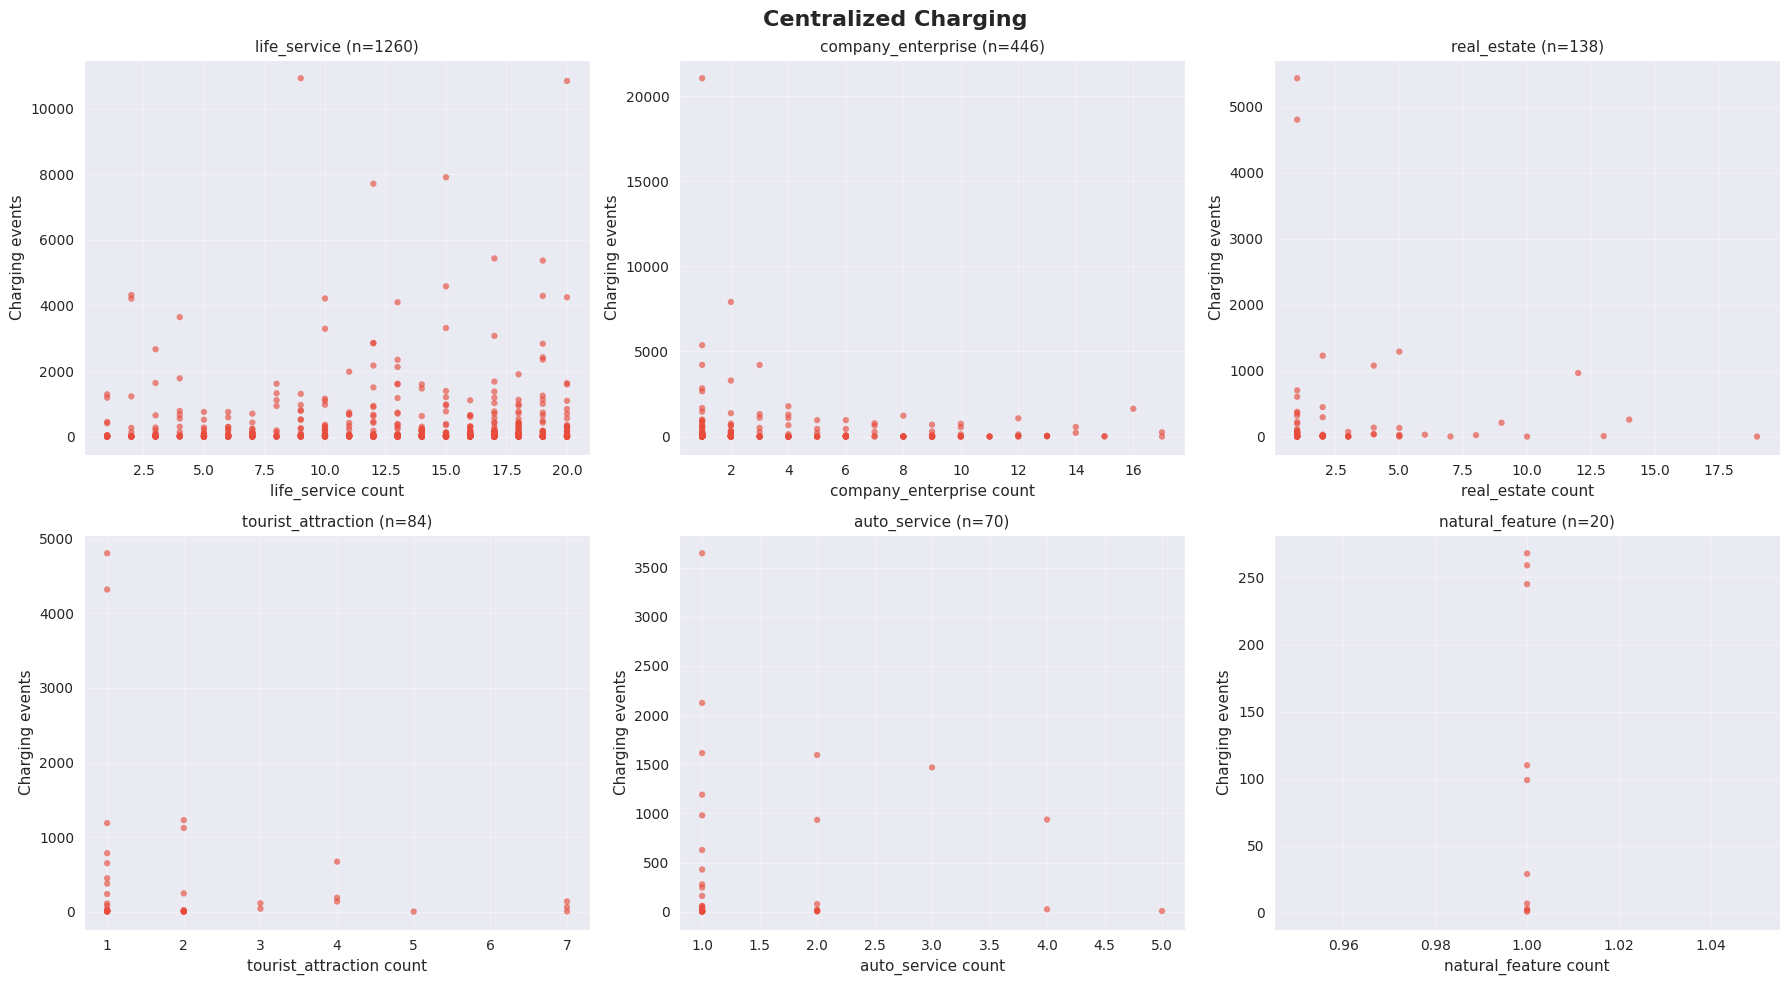

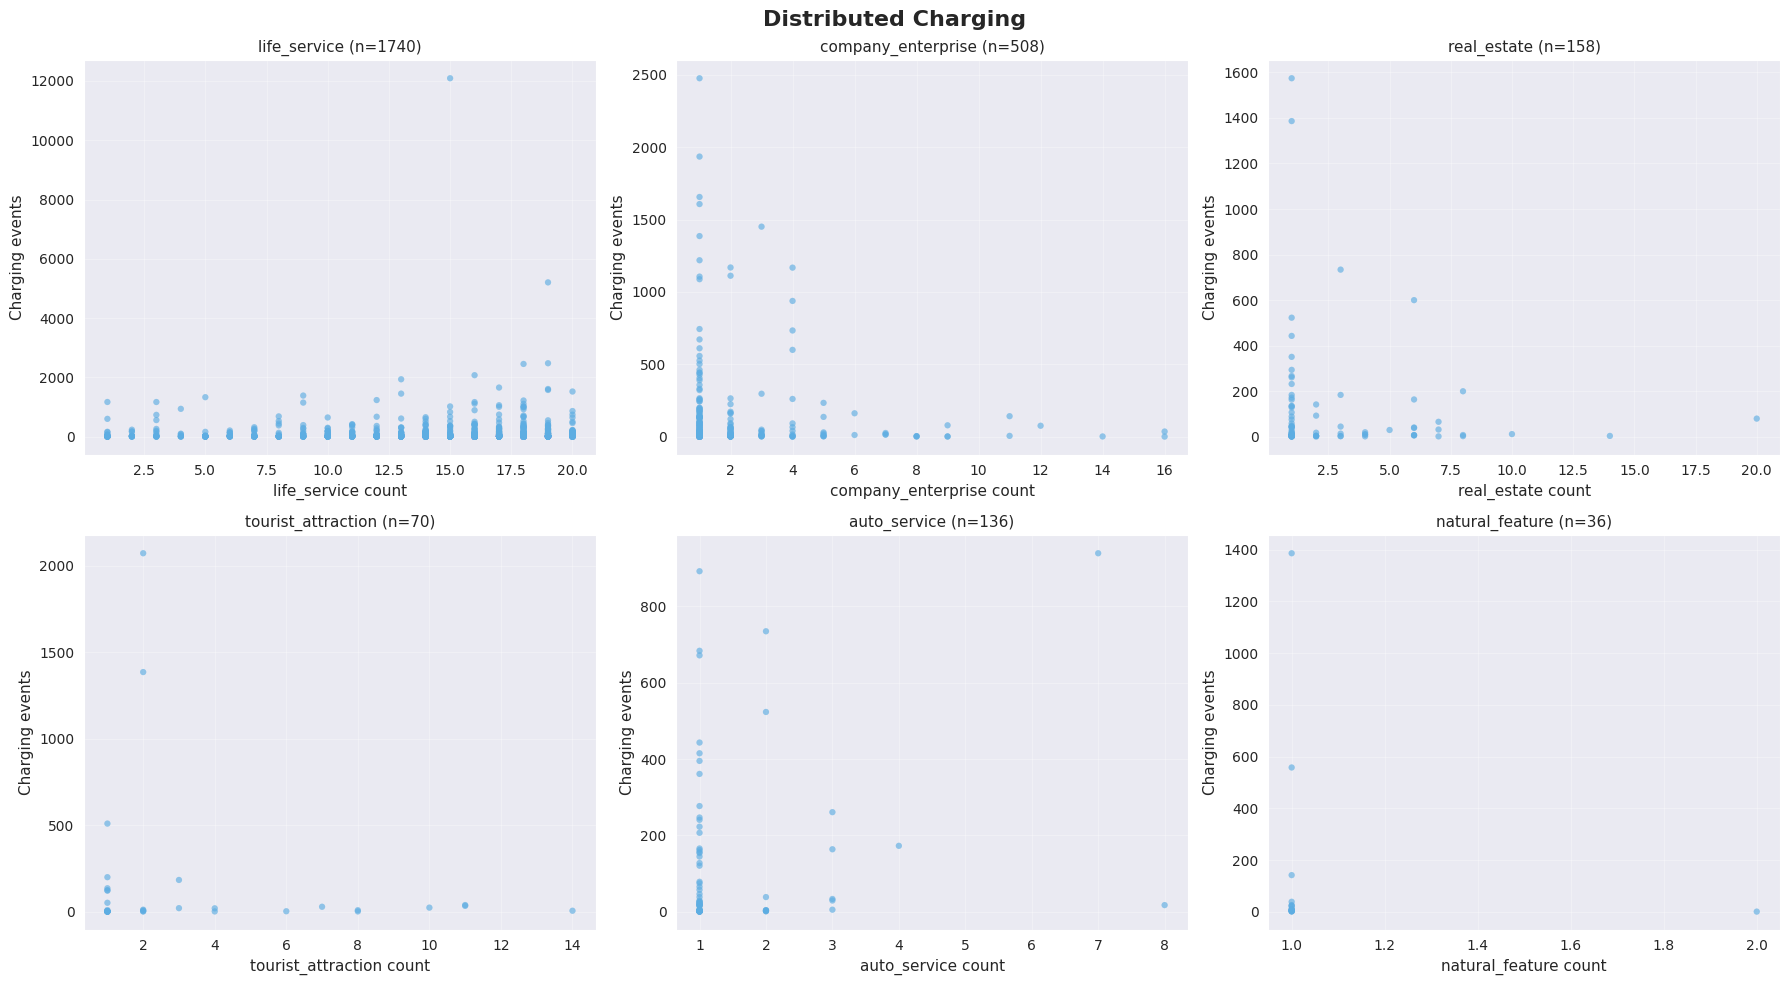

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# 2. 分别统计每站两类充电次数
cent_counts = cent_charging_events_merge.groupby('nearest_station_id').size().reset_index()
cent_counts.columns = ['station_id', 'charging_events']

dist_counts = dist_charging_events.groupby('nearest_station_id').size().reset_index()
dist_counts.columns = ['station_id', 'charging_events']

# 3. 合并POI
cent_merged = poi_result.merge(cent_counts, on='station_id', how='inner')
dist_merged = poi_result.merge(dist_counts, on='station_id', how='inner')

# 4. 选出数量最多的6类POI
poi_sums = poi_result[poi_type_cols].sum().sort_values(ascending=False)
top6 = poi_sums.head(6).index.tolist()
print("数量最多的6类POI:", top6)

# 5. 集中式充电散点图
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Centralized Charging', fontsize=16, fontweight='bold')
axes = axes.flatten()

for idx, poi_col in enumerate(top6):
    ax = axes[idx]
    data = cent_merged[cent_merged[poi_col] > 0]
    ax.scatter(data[poi_col], data['charging_events'],
               alpha=0.4, s=20, color='#E74C3C', edgecolors='none')
    ax.set_xlabel(f'{poi_col} count', fontsize=11)
    ax.set_ylabel('Charging events', fontsize=11)
    ax.set_title(f'{poi_col} (n={len(data)})', fontsize=11)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 6. 分布式充电散点图
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Distributed Charging', fontsize=16, fontweight='bold')
axes = axes.flatten()

for idx, poi_col in enumerate(top6):
    ax = axes[idx]
    data = dist_merged[dist_merged[poi_col] > 0]
    ax.scatter(data[poi_col], data['charging_events'],
               alpha=0.4, s=20, color='#5DADE2', edgecolors='none')
    ax.set_xlabel(f'{poi_col} count', fontsize=11)
    ax.set_ylabel('Charging events', fontsize=11)
    ax.set_title(f'{poi_col} (n={len(data)})', fontsize=11)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

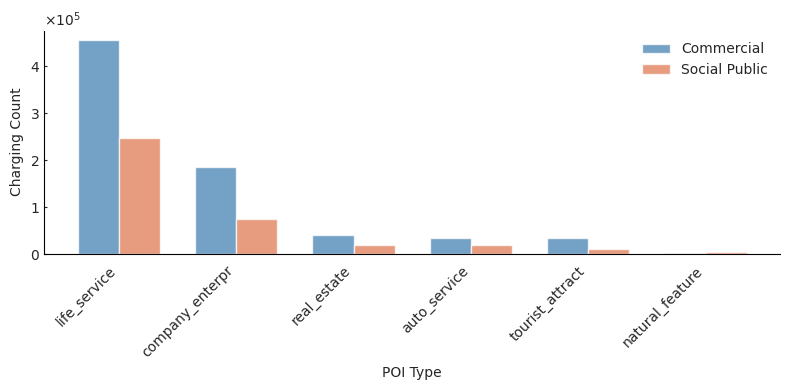

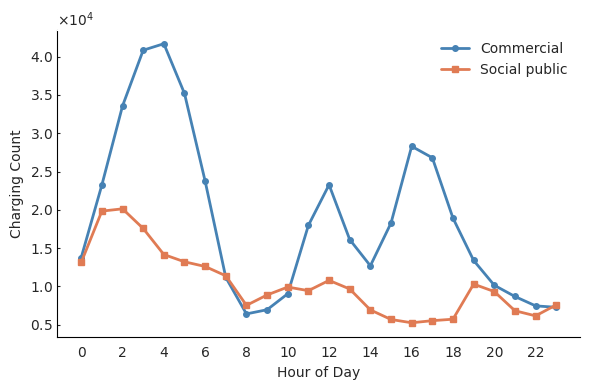

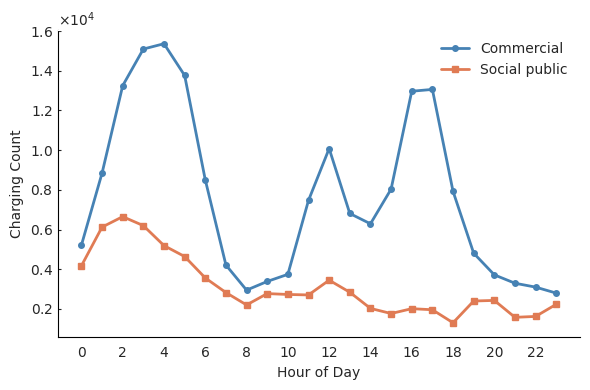

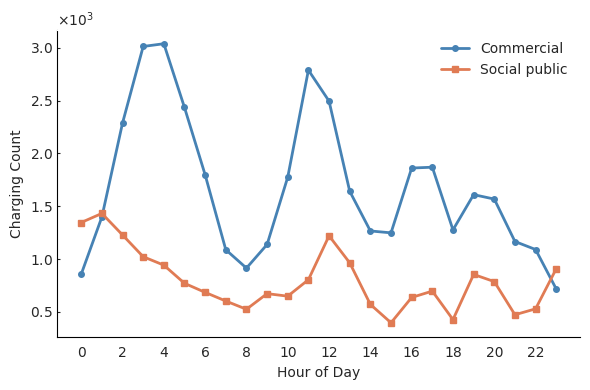

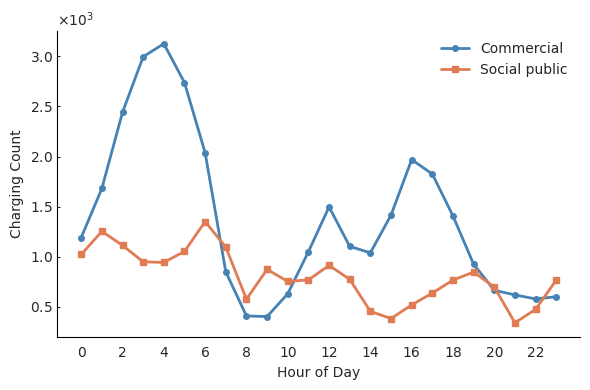

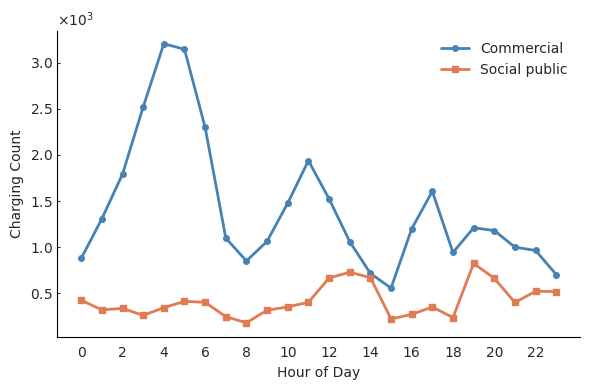

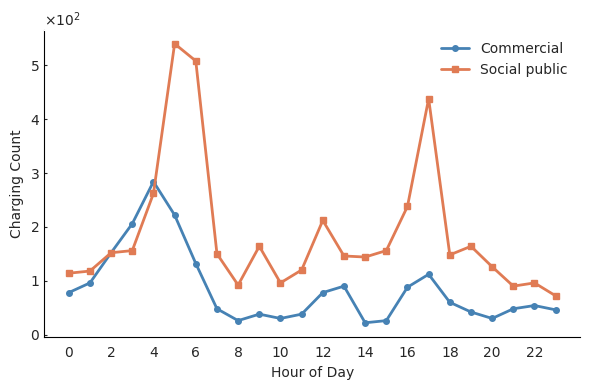

In [157]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# 1. 加载数据
poi_result = pd.read_csv('POI_result.csv')
poi_type_cols = [col for col in poi_result.columns if col != 'station_id']

cent_charging_events_merge['charge_type'] = 'centralized'
dist_charging_events['charge_type'] = 'distributed'
all_charging = pd.concat([cent_charging_events_merge, dist_charging_events], ignore_index=True)

all_charging['hour'] = pd.to_datetime(all_charging['start_time']).dt.hour

# 2. 合并POI数据
charging_with_poi = all_charging.merge(
    poi_result,
    left_on='nearest_station_id',
    right_on='station_id',
    how='left'
)

# 3. 统计不同POI类型下两种充电的次数分布
poi_charging_stats = []

for poi_type in poi_type_cols:
    stations_with_poi = poi_result[poi_result[poi_type] > 0]['station_id'].values
    charging_in_poi = charging_with_poi[charging_with_poi['nearest_station_id'].isin(stations_with_poi)]

    if len(charging_in_poi) > 0:
        centralized_count = len(charging_in_poi[charging_in_poi['charge_type'] == 'centralized'])
        distributed_count = len(charging_in_poi[charging_in_poi['charge_type'] == 'distributed'])
        total_count = len(charging_in_poi)

        poi_charging_stats.append({
            'poi_type': poi_type,
            'centralized_count': centralized_count,
            'distributed_count': distributed_count,
            'total_count': total_count,
            'centralized_ratio': centralized_count / total_count if total_count > 0 else 0,
            'distributed_ratio': distributed_count / total_count if total_count > 0 else 0,
            'station_count': len(stations_with_poi),
            'avg_poi_count': poi_result[poi_result[poi_type] > 0][poi_type].mean()
        })

poi_stats_df = pd.DataFrame(poi_charging_stats).sort_values('total_count', ascending=False)

# 4. 统计时间分布
top_poi_types = poi_stats_df.head(6)['poi_type'].values

time_distribution = []
for poi_type in top_poi_types:
    stations_with_poi = poi_result[poi_result[poi_type] > 0]['station_id'].values
    charging_in_poi = charging_with_poi[charging_with_poi['nearest_station_id'].isin(stations_with_poi)]

    if len(charging_in_poi) > 0:
        hourly = charging_in_poi.groupby(['hour', 'charge_type']).size().unstack(fill_value=0)
        for hour in range(24):
            centralized_hour = hourly.get('centralized', pd.Series()).get(hour, 0)
            distributed_hour = hourly.get('distributed', pd.Series()).get(hour, 0)
            time_distribution.append({
                'poi_type': poi_type,
                'hour': hour,
                'centralized_count': centralized_hour,
                'distributed_count': distributed_hour,
                'total_count': centralized_hour + distributed_hour
            })

time_dist_df = pd.DataFrame(time_distribution)

# ============================================================
# 统一绘图风格
# ============================================================
LABEL_SIZE = 10
TICK_SIZE  = 10
LEG_SIZE   = 10

def style_ax(ax):
    ax.set_facecolor('white')
    ax.grid(False)
    ax.spines['top'].set_visible(True)
    ax.spines['right'].set_visible(True)
    ax.spines['left'].set_linewidth(0.8)
    ax.spines['bottom'].set_linewidth(0.8)
    ax.spines['left'].set_color('black')
    ax.spines['bottom'].set_color('black')
    ax.tick_params(axis='y', which='both', direction='in',
                   length=2, width=0.8, labelsize=TICK_SIZE,left=True)
    ax.yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
    ax.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
    ax.yaxis.get_offset_text().set_fontsize(TICK_SIZE)

# ============================================================
# 图1：充电次数分布（前10个POI类型）
# ============================================================
top_10 = poi_stats_df.head(10)
x_pos = np.arange(len(top_10))
width = 0.35

fig1, ax1 = plt.subplots(figsize=(8, 4), facecolor='white')
ax1.bar(x_pos - width/2, top_10['centralized_count'], width,
        label='Commercial', color='steelblue', alpha=0.75)
ax1.bar(x_pos + width/2, top_10['distributed_count'], width,
        label='Social Public', color='#e07b54', alpha=0.75)
ax1.set_xlabel('POI Type', fontsize=LABEL_SIZE)
ax1.set_ylabel('Charging Count', fontsize=LABEL_SIZE)
ax1.set_xticks(x_pos)
ax1.set_xticklabels([col[:15] for col in top_10['poi_type'].values],
                     rotation=45, ha='right')
ax1.legend(loc='upper right', fontsize=LEG_SIZE, frameon=False)
style_ax(ax1)
plt.tight_layout()
plt.show()

# ============================================================
# 图2-7：每个POI类型的时间分布（各自独立）
# ============================================================
top_6_poi = top_poi_types[:6]

for poi_type in top_6_poi:
    poi_time = time_dist_df[time_dist_df['poi_type'] == poi_type]

    fig, ax = plt.subplots(figsize=(6, 4), facecolor='white')

    ax.plot(poi_time['hour'], poi_time['centralized_count'],
            marker='o', label='Commercial', color='steelblue',
            linewidth=2, markersize=4)
    ax.plot(poi_time['hour'], poi_time['distributed_count'],
            marker='s', label='Social public', color='#e07b54',
            linewidth=2, markersize=4)

    ax.set_xlabel('Hour of Day', fontsize=LABEL_SIZE)
    ax.set_ylabel('Charging Count', fontsize=LABEL_SIZE)
    ax.set_xticks(range(0, 24, 2))
    ax.legend(loc='upper right', fontsize=LEG_SIZE, frameon=False)
    style_ax(ax)
    plt.tight_layout()
    plt.show()

/home/lxhep/miniconda3/envs/rapids-env/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:4842: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(


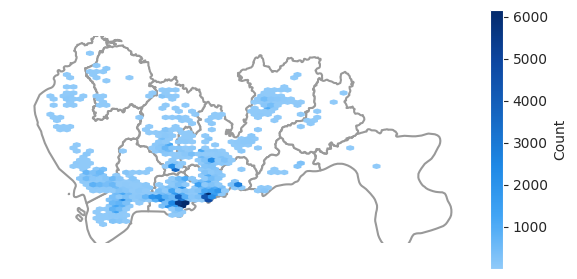

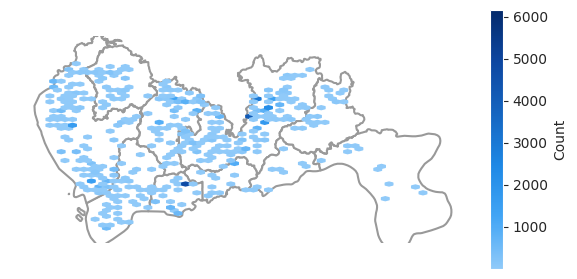

In [29]:
import matplotlib.pyplot as plt
import numpy as np
import geopandas as gpd
from matplotlib.colors import LinearSegmentedColormap

# 深圳边界
boundary_file = 'shenzhen_full.json'
url = 'https://geo.datav.aliyun.com/areas_v3/bound/440300_full.json'
if not os.path.exists(boundary_file):
    try:
        import requests
        r = requests.get(url, timeout=15)
        if r.status_code == 200:
            with open(boundary_file, 'wb') as f:
                f.write(r.content)
    except Exception:
        pass

dist_lon = dist_charging_events['stay_lon'].values
dist_lat = dist_charging_events['stay_lat'].values

com_stations = pd.read_csv(COM_STATION_CSV)
lon_col = [c for c in com_stations.columns if 'lon' in c.lower() or '经度' in c][0]
lat_col = [c for c in com_stations.columns if 'lat' in c.lower() or '纬度' in c][0]
id_col = [c for c in com_stations.columns if 'station' in c.lower() or c == 'id'][0]
cent_merged = cent_charging_events.merge(
    com_stations[[id_col, lon_col, lat_col]],
    left_on='nearest_station_id', right_on=id_col, how='left'
)
cent_lon = cent_merged[lon_col].dropna().values
cent_lat = cent_merged[lat_col].dropna().values

all_lon = np.concatenate([dist_lon, cent_lon])
all_lat = np.concatenate([dist_lat, cent_lat])
_, _, _, pc = plt.hist2d(all_lon, all_lat, bins=50, range=[[113.70, 114.65], [22.45, 22.85]])
counts = pc.get_array()
vmin, vmax = 1, np.percentile(counts[counts > 0], 99)
plt.close()

# 从浅蓝开始，小数值也明显区别于白底
cmap = LinearSegmentedColormap.from_list(
    'heat', [ '#90caf9', '#42a5f5', '#1e88e5', '#1565c0', '#0d47a1', '#042a6b'], N=256
)

extent = [113.70, 114.65, 22.45, 22.85]
aspect = (114.65 - 113.70) / (22.85 - 22.45)

def plot_one(ax, lon, lat):
    ax.set_xlim(extent[0], extent[1])
    ax.set_ylim(extent[2], extent[3])
    ax.set_aspect(aspect)
    ax.set_facecolor('white')
    if os.path.exists(boundary_file):
        sz_map = gpd.read_file(boundary_file)
        sz_map.plot(ax=ax, color='white', edgecolor='#999999', linewidth=1.5, zorder=1)
    else:
        ax.set_facecolor('white')
    h = ax.hexbin(lon, lat, gridsize=50, cmap=cmap, alpha=1, mincnt=1, vmin=vmin, vmax=vmax, zorder=2)
    #ax.set_title(title)
    ax.set_axis_off()
    return h

# 图1：分布式充电
fig1, ax1 = plt.subplots(figsize=(6, 4), facecolor='white')
h1 = plot_one(ax1, dist_lon, dist_lat)
cbar1 = fig1.colorbar(h1, ax=ax1, shrink=0.7, label='Count')
plt.tight_layout()
plt.show()

# 图2：集中式充电
fig2, ax2 = plt.subplots(figsize=(6, 4), facecolor='white')
h2 = plot_one(ax2, cent_lon, cent_lat)
cbar2 = fig2.colorbar(h2, ax=ax2, shrink=0.7, label='Count')
plt.tight_layout()
plt.show()

In [32]:
# 加载POI并选取6列
poi_result = pd.read_csv('POI_result.csv')
poi_cols = ['life_service', 'company_enterprise', 'real_estate',
            'tourist_attraction', 'auto_service', 'natural_feature']
poi_subset = poi_result[['station_id'] + poi_cols]

# 合并到两条充电数据
cent_charging_events_merge = cent_charging_events_merge.merge(
    poi_subset,
    left_on='merged_station_id',
    right_on='station_id',
    how='left'
).drop(columns=['station_id'], errors='ignore')

dist_charging_events = dist_charging_events.merge(
    poi_subset,
    left_on='nearest_station_id',
    right_on='station_id',
    how='left'
).drop(columns=['station_id'], errors='ignore')

In [35]:
dist_charging_events.head()

,taxiid,nearest_station_id,start_time,end_time,duration_s,stay_lon,stay_lat,num_points,life_service,company_enterprise,real_estate,tourist_attraction,auto_service,natural_feature
0,UUUB0C0M7,2266,2020-01-02 01:21:09,2020-01-02 01:35:24,855.0,114.129456,22.547155,17,8.0,0.0,0.0,0.0,0.0,0.0
1,UUUB0C0M7,2266,2020-01-02 01:21:09,2020-01-02 01:35:24,855.0,114.129456,22.547155,17,8.0,0.0,0.0,0.0,0.0,0.0
2,UUUB0C0M7,2205,2020-01-03 02:02:20,2020-01-03 02:13:40,680.0,114.121628,22.543396,20,15.0,1.0,0.0,0.0,0.0,0.0
3,UUUB0C0M7,2205,2020-01-03 02:02:20,2020-01-03 02:13:40,680.0,114.121628,22.543396,20,15.0,1.0,0.0,0.0,0.0,0.0
4,UUUB0C0M7,2330,2020-01-04 04:33:45,2020-01-04 04:57:53,1448.0,114.142906,22.556120,57,11.0,0.0,0.0,0.0,0.0,0.0


In [33]:
# 保存到本地（可放在 merge 之后）
OUTPUT_DIR = 'output_v6'  # 与 notebook 中一致

# 保存 commercial 充电事件（带 POI）
cent_charging_events_merge.to_parquet(
    f'{OUTPUT_DIR}/commercial_charging_events_with_poi.parquet',
    index=False
)

# 保存 distributed 充电事件（带 POI）
dist_charging_events.to_parquet(
    f'{OUTPUT_DIR}/distributed_charging_events_with_poi.parquet',
    index=False
)

# 若需要 CSV 格式：
# cent_charging_events_merge.to_csv(f'{OUTPUT_DIR}/commercial_charging_events_with_poi.csv', index=False)
# dist_charging_events.to_csv(f'{OUTPUT_DIR}/distributed_charging_events_with_poi.csv', index=False)# 保存到本地（可放在 merge 之后）
OUTPUT_DIR = 'output_v6'  # 与 notebook 中一致

# 保存 commercial 充电事件（带 POI）
cent_charging_events_merge.to_parquet(
    f'{OUTPUT_DIR}/commercial_charging_events_with_poi.parquet',
    index=False
)

# 保存 distributed 充电事件（带 POI）
dist_charging_events.to_parquet(
    f'{OUTPUT_DIR}/distributed_charging_events_with_poi.parquet',
    index=False
)

# 若需要 CSV 格式：
# cent_charging_events_merge.to_csv(f'{OUTPUT_DIR}/commercial_charging_events_with_poi.csv', index=False)
# dist_charging_events.to_csv(f'{OUTPUT_DIR}/distributed_charging_events_with_poi.csv', index=False)

In [42]:
from sklearn.metrics.pairwise import haversine_distances
import numpy as np

R_earth = 6371  # km

def avg_inter_dist(df, lon_col, lat_col):
    X = np.radians(df[[lat_col, lon_col]].values)
    d = haversine_distances(X) * R_earth
    return d[np.triu_indices(len(X), k=1)].mean()

# 非商用站：station_df
avg_dist_noncom = avg_inter_dist(stations_df, 'longitude', 'latitude')

# 商用站：merged_stations
avg_dist_com = avg_inter_dist(merged_stations, 'lon', 'lat')

print(f"非商用站平均站间距离: {avg_dist_noncom:.2f} km")
print(f"商用站平均站间距离: {avg_dist_com:.2f} km")

非商用站平均站间距离: 19.52 km
商用站平均站间距离: 24.03 km


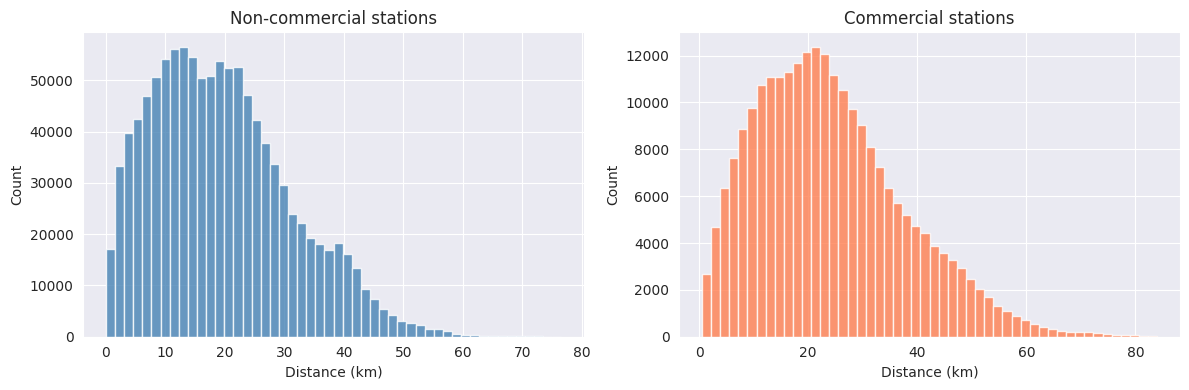

In [43]:
from sklearn.metrics.pairwise import haversine_distances
import numpy as np
import matplotlib.pyplot as plt

R_earth = 6371  # km

def get_inter_distances(df, lon_col, lat_col):
    X = np.radians(df[[lat_col, lon_col]].values)
    d = haversine_distances(X) * R_earth
    return d[np.triu_indices(len(X), k=1)]

dist_noncom = get_inter_distances(stations_df, 'longitude', 'latitude')
dist_com = get_inter_distances(merged_stations, 'lon', 'lat')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(dist_noncom, bins=50, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_xlabel('Distance (km)')
axes[0].set_ylabel('Count')
axes[0].set_title('Non-commercial stations')

axes[1].hist(dist_com, bins=50, color='coral', edgecolor='white', alpha=0.8)
axes[1].set_xlabel('Distance (km)')
axes[1].set_ylabel('Count')
axes[1].set_title('Commercial stations')

plt.tight_layout()
plt.show()

In [44]:
from sklearn.metrics.pairwise import haversine_distances
import numpy as np

R_earth = 6371

def get_coords(df, lon_col, lat_col):
    c = df[[lon_col, lat_col]].drop_duplicates()
    return np.radians(c[[lat_col, lon_col]].values)

def nn_mean_distance(X_rad):  # 每站到最近邻的平均距离 (km)
    d = haversine_distances(X_rad) * R_earth
    np.fill_diagonal(d, np.inf)
    return np.min(d, axis=1).mean()

def all_pairs_mean_distance(X_rad):
    d = haversine_distances(X_rad) * R_earth
    return d[np.triu_indices(len(X_rad), k=1)].mean()

X_nc = get_coords(stations_df, 'longitude', 'latitude')
X_com = get_coords(merged_stations, 'lon', 'lat')

print("非商用站:")
print(f"  最近邻平均距离: {nn_mean_distance(X_nc):.2f} km")
print(f"  全站对平均距离: {all_pairs_mean_distance(X_nc):.2f} km")
print("商用站:")
print(f"  最近邻平均距离: {nn_mean_distance(X_com):.2f} km")
print(f"  全站对平均距离: {all_pairs_mean_distance(X_com):.2f} km")

非商用站:
  最近邻平均距离: 0.29 km
  全站对平均距离: 19.49 km
商用站:
  最近邻平均距离: 0.86 km
  全站对平均距离: 24.03 km


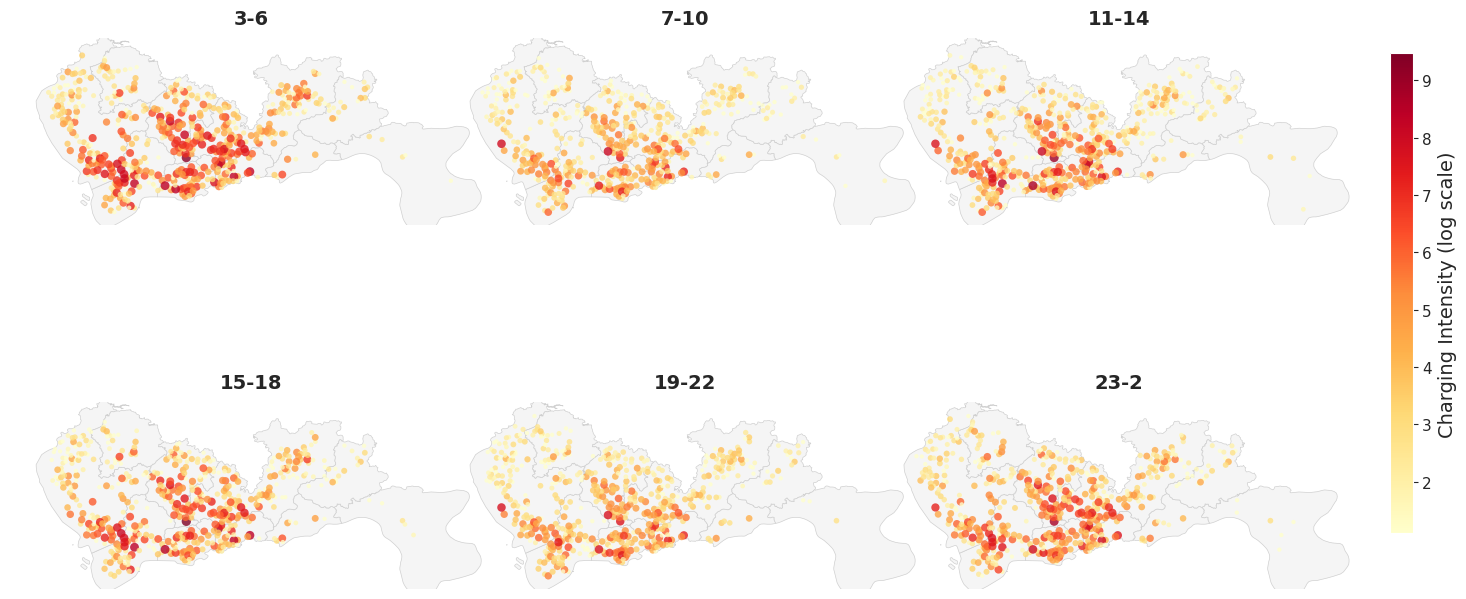

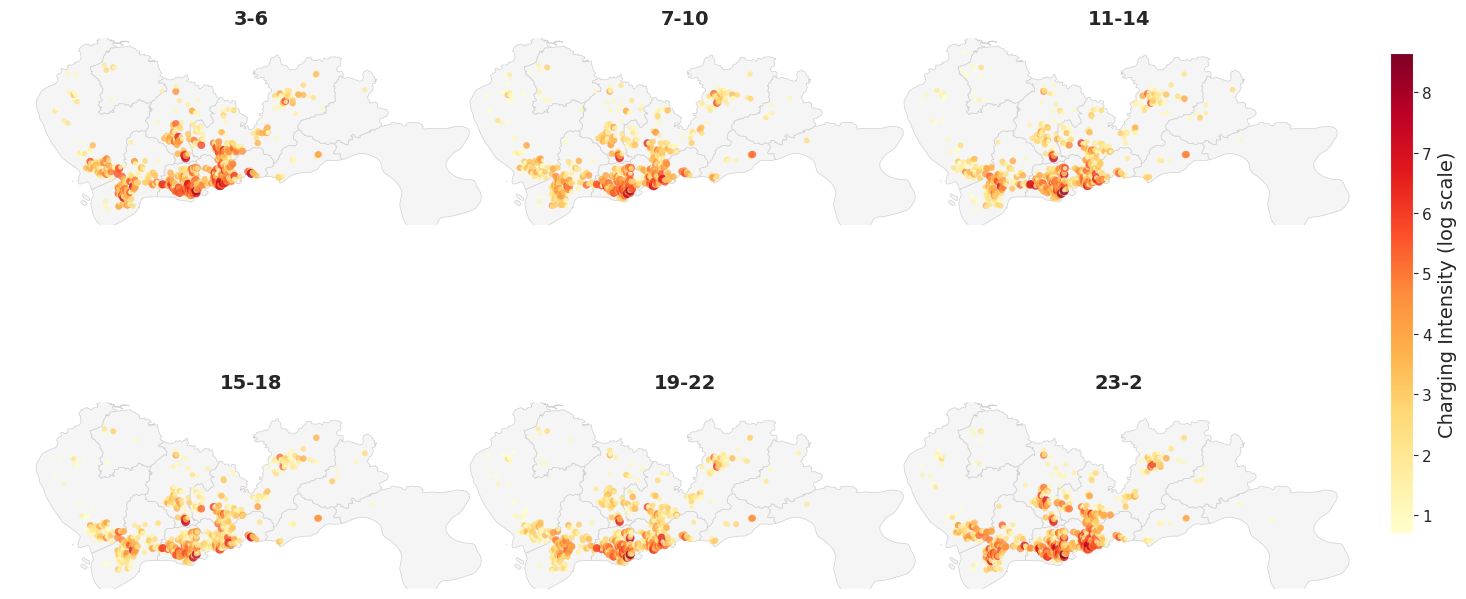

In [63]:
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import pandas as pd
import os

# 1. 时段定义 (hour)
TIME_SLOTS = [
    ([3, 4, 5, 6], '3-6'),
    ([7, 8, 9, 10], '7-10'),
    ([11, 12, 13, 14], '11-14'),
    ([15, 16, 17, 18], '15-18'),
    ([19, 20, 21, 22], '19-22'),
    ([23, 0, 1, 2], '23-2'),
]

# 2. 深圳底图
boundary_file = 'shenzhen_full.json'
if os.path.exists(boundary_file):
    sz_map = gpd.read_file(boundary_file)
else:
    import requests
    url = 'https://geo.datav.aliyun.com/areas_v3/bound/440300_full.json'
    try:
        r = requests.get(url, timeout=15)
        if r.status_code == 200:
            with open(boundary_file, 'wb') as f:
                f.write(r.content)
            sz_map = gpd.read_file(boundary_file)
    except Exception as e:
        print(f"Failed to load boundary: {e}")
        sz_map = None

aspect = np.cos(np.radians(22.65))
xlim, ylim = (113.70, 114.65), (22.45, 22.85)


def plot_heatmap_figure(events_df, stations_df, lon_col, lat_col, id_col, cmap='YlOrRd'):
    events = events_df.copy()
    events['hour'] = pd.to_datetime(events['start_time']).dt.hour

    # 预计算全局 vmin/vmax 以统一色标
    all_log_counts = []
    for hours, _ in TIME_SLOTS:
        sub = events[events['hour'].isin(hours)]
        if sub.empty: continue
        cnt = sub.groupby('nearest_station_id').size()
        all_log_counts.extend(np.log1p(cnt.values))

    vmin = min(all_log_counts) if all_log_counts else 0
    vmax = max(all_log_counts) if all_log_counts else 1
    norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)

    # 调整画布比例，使其更扁平以适应深圳东西狭长的地形
    fig, axes = plt.subplots(2, 3, figsize=(15, 8), facecolor='white')
    axes = axes.flatten()

    for idx, (hours, slot_name) in enumerate(TIME_SLOTS):
        ax = axes[idx]

        # 数据过滤与聚合
        sub = events[events['hour'].isin(hours)]
        cnt = sub.groupby('nearest_station_id').size().reset_index(name='count')
        df_plot = cnt.merge(stations_df[[id_col, lon_col, lat_col]],
                            left_on='nearest_station_id', right_on=id_col, how='inner')

        # 绘制背景
        if sz_map is not None:
            sz_map.plot(ax=ax, color='#f5f5f5', edgecolor='#d0d0d0', linewidth=0.5, zorder=1)

        if not df_plot.empty:
            lon = df_plot[lon_col].values
            lat = df_plot[lat_col].values
            c = np.log1p(df_plot['count'].values)
            # 动态调整点的大小：数据量越大点越小，避免重叠严重
            s = 5 + (c / vmax) * 40

            sc = ax.scatter(lon, lat, c=c, s=s, cmap=cmap, norm=norm,
                           alpha=0.8, edgecolors='none', zorder=2)

        # 核心：布局优化
        ax.set_xlim(*xlim)
        ax.set_ylim(*ylim)
        ax.set_aspect(aspect)

        # 统一使用 title，并加粗加大
        ax.set_title(f"{slot_name}", fontsize=14, fontweight='bold', pad=10)

        # 关闭坐标轴但保留标题
        ax.set_axis_off()

    # 压缩子图间距：wspace和hspace设为负数或极小值以抵消地理坐标产生的空白
    plt.subplots_adjust(left=0.02, right=0.92, top=0.9, bottom=0.05, wspace=-0.1, hspace=0.15)

    # 颜色条优化
    cbar_ax = fig.add_axes([0.94, 0.2, 0.015, 0.6])
    cbar_ax.tick_params(labelsize=11)   # 把 9 改成你想要的值，如 11、12
    sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
    fig.colorbar(sm, cax=cbar_ax).set_label('Charging Intensity (log scale)', fontsize=14)

    plt.show()


# 3. 商业充电
plot_heatmap_figure(
    cent_charging_events_merge,
    merged_stations,
    lon_col='lon', lat_col='lat', id_col='station_id',
    cmap='YlOrRd'
)

# 4. 分布式充电
plot_heatmap_figure(
    dist_charging_events,
    stations_df,
    lon_col='longitude', lat_col='latitude', id_col='station_id',
    cmap='YlOrRd'
)

# station clasifficatn

  social_public
共 1478 站 | 有POI: 1319 | 无POI: 159
自动截断值: 0.4229 → 有POI站分为 6 类
加上 no_poi 类，共 7 类



/tmp/ipykernel_334342/2991536769.py:52: UserWarning: Glyph 25130 (\N{CJK UNIFIED IDEOGRAPH-622A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_334342/2991536769.py:52: UserWarning: Glyph 26029 (\N{CJK UNIFIED IDEOGRAPH-65AD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/lxhep/miniconda3/envs/rapids-env/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 25130 (\N{CJK UNIFIED IDEOGRAPH-622A}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/lxhep/miniconda3/envs/rapids-env/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 26029 (\N{CJK UNIFIED IDEOGRAPH-65AD}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


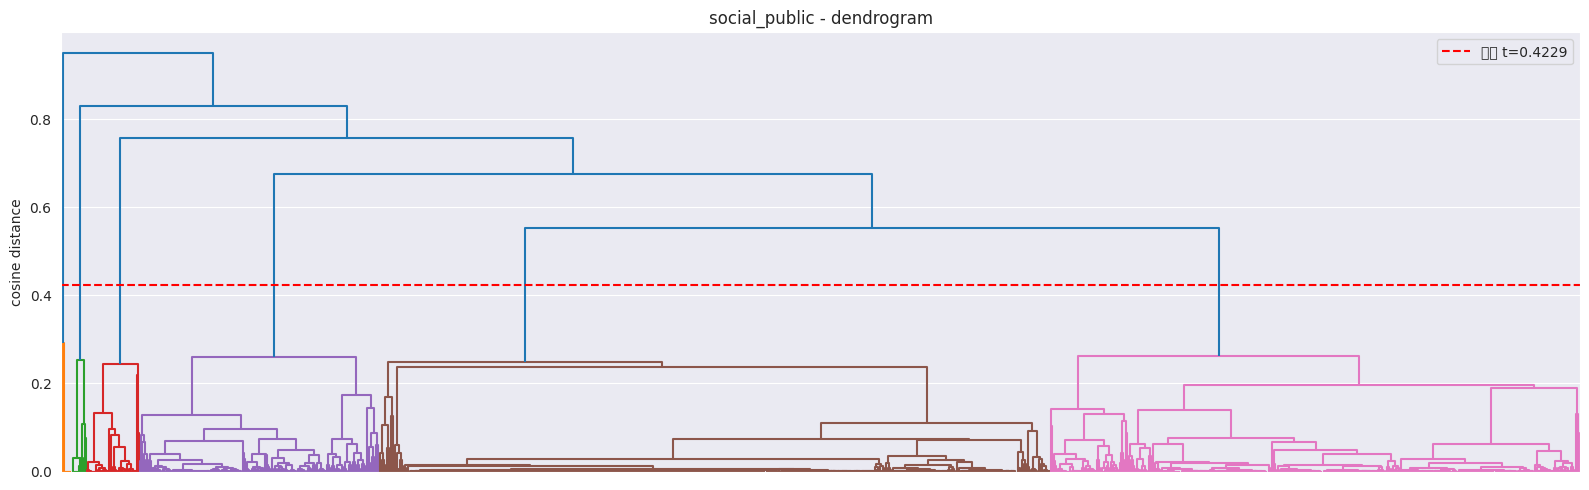

----------------------------------------
各簇特征（POI类型平均占比，只显示 top 5）
----------------------------------------

【簇 0 - no_poi】159 站，无任何 POI

【簇 1】9 站
    natural_land: 94.44%
    dailylife_service: 5.56%
    shopping_service: 0.00%
    sports_leisure_service: 0.00%
    medical_service: 0.00%

【簇 2】13 站
    automotive_service: 74.61%
    business: 16.69%
    residence: 4.63%
    dailylife_service: 4.08%
    shopping_service: 0.00%

【簇 3】46 站
    tourist_attraction: 70.34%
    dailylife_service: 23.65%
    residence: 1.84%
    natural_land: 1.70%
    business: 1.38%

【簇 4】208 站
    residence: 65.40%
    dailylife_service: 15.72%
    business: 13.85%
    tourist_attraction: 3.19%
    automotive_service: 1.85%

【簇 5】583 站
    dailylife_service: 88.14%
    business: 7.84%
    tourist_attraction: 1.74%
    residence: 1.18%
    automotive_service: 1.06%

【簇 6】460 站
    business: 62.84%
    dailylife_service: 25.74%
    residence: 8.97%
    automotive_service: 1.38%
    tourist_attraction: 0.94%


,簇1,簇2,簇3,簇4,簇5,簇6
簇1,0.0000,0.9969,0.9584,0.9866,0.9410,0.9760
簇2,0.9969,0.0000,0.9633,0.8605,0.9154,0.7530
簇3,0.9584,0.9633,0.0000,0.8555,0.6622,0.8468
簇4,0.9866,0.8605,0.8555,0.0000,0.7407,0.6038
簇5,0.9410,0.9154,0.6622,0.7407,0.0000,0.5425
簇6,0.9760,0.7530,0.8468,0.6038,0.5425,0.0000


  cent_stat_summary
共 595 站 | 有POI: 515 | 无POI: 80
自动截断值: 0.4699 → 有POI站分为 6 类
加上 no_poi 类，共 7 类



/tmp/ipykernel_334342/2991536769.py:52: UserWarning: Glyph 25130 (\N{CJK UNIFIED IDEOGRAPH-622A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_334342/2991536769.py:52: UserWarning: Glyph 26029 (\N{CJK UNIFIED IDEOGRAPH-65AD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/lxhep/miniconda3/envs/rapids-env/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 25130 (\N{CJK UNIFIED IDEOGRAPH-622A}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/lxhep/miniconda3/envs/rapids-env/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 26029 (\N{CJK UNIFIED IDEOGRAPH-65AD}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


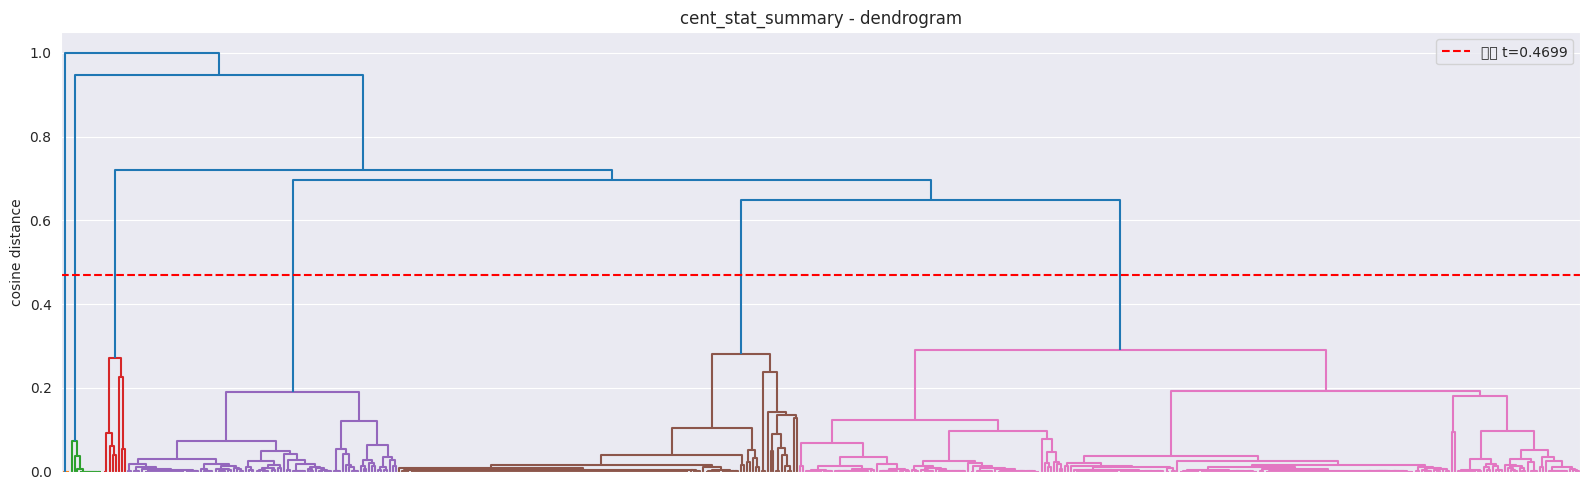

----------------------------------------
各簇特征（POI类型平均占比，只显示 top 5）
----------------------------------------

【簇 0 - no_poi】80 站，无任何 POI

【簇 1】3 站
    natural_land: 100.00%
    catering_service: 0.00%
    dailylife_service: 0.00%
    sports_leisure_service: 0.00%
    medical_service: 0.00%

【簇 2】11 站
    tourist_attraction: 93.46%
    dailylife_service: 4.73%
    automotive_service: 1.30%
    residence: 0.51%
    shopping_service: 0.00%

【簇 3】8 站
    automotive_service: 62.17%
    dailylife_service: 14.61%
    business: 13.01%
    residence: 9.17%
    tourist_attraction: 1.04%

【簇 4】92 站
    residence: 70.22%
    dailylife_service: 14.03%
    business: 13.12%
    automotive_service: 1.42%
    tourist_attraction: 1.20%

【簇 5】136 站
    dailylife_service: 90.05%
    business: 3.58%
    tourist_attraction: 3.45%
    residence: 2.06%
    automotive_service: 0.72%

【簇 6】265 站
    business: 67.95%
    dailylife_service: 23.13%
    residence: 7.44%
    automotive_service: 1.01%
    tourist_attr

,簇1,簇2,簇3,簇4,簇5,簇6
簇1,0.0000,1.0000,1.0000,1.0000,0.9984,0.9994
簇2,1.0000,0.0000,0.9591,0.9683,0.9111,0.9773
簇3,1.0000,0.9591,0.0000,0.7686,0.7593,0.7151
簇4,1.0000,0.9683,0.7686,0.0000,0.7777,0.6687
簇5,0.9984,0.9111,0.7593,0.7777,0.0000,0.6400
簇6,0.9994,0.9773,0.7151,0.6687,0.6400,0.0000


In [72]:
import pandas as pd
import numpy as np
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform
from sklearn.metrics.pairwise import cosine_distances
import matplotlib.pyplot as plt

def find_best_cutoff(link):
    merge_dists = link[:, 2]
    gaps = np.diff(merge_dists)
    best_idx = np.argmax(gaps)
    cutoff = (merge_dists[best_idx] + merge_dists[best_idx + 1]) / 2
    n_clusters = len(merge_dists) - best_idx
    return cutoff, n_clusters


def cluster_and_report(filepath, title=''):
    print("=" * 60)
    print(f"  {title}")
    print("=" * 60)

    # ---------- 读取 & 向量构建 ----------
    df = pd.read_csv(filepath).set_index('station_id')
    poi_cols = df.columns.tolist()
    row_totals = df.sum(axis=1)

    no_poi = row_totals[row_totals == 0].index.tolist()
    has_poi = row_totals[row_totals > 0].index.tolist()
    print(f"共 {len(df)} 站 | 有POI: {len(has_poi)} | 无POI: {len(no_poi)}")

    df_poi = df.loc[has_poi]
    matrix = df_poi.div(row_totals.loc[has_poi], axis=0).values

    # ---------- 聚类 ----------
    dist = cosine_distances(matrix)
    condensed = squareform(dist, checks=False)
    link = linkage(condensed, method='average')
    cutoff, n_clusters = find_best_cutoff(link)
    clusters = fcluster(link, t=cutoff, criterion='distance')

    print(f"自动截断值: {cutoff:.4f} → 有POI站分为 {n_clusters} 类")
    print(f"加上 no_poi 类，共 {n_clusters + 1} 类\n")

    # ---------- dendrogram ----------
    plt.figure(figsize=(16, 5))
    dendrogram(link, no_labels=True, color_threshold=cutoff)
    plt.axhline(y=cutoff, color='red', linestyle='--',
                label=f'截断 t={cutoff:.4f}')
    plt.title(f'{title} - dendrogram')
    plt.ylabel('cosine distance')
    plt.legend()
    plt.tight_layout()
    plt.show()

    # ---------- 构建结果表 ----------
    df_poi['cluster'] = clusters.astype(int)
    if no_poi:
        df_no = df.loc[no_poi].copy()
        df_no['cluster'] = 0  # 0 号簇 = 无POI
        df_all = pd.concat([df_poi, df_no])
    else:
        df_all = df_poi.copy()

    # ---------- 每个簇的特征 ----------
    print("-" * 40)
    print("各簇特征（POI类型平均占比，只显示 top 5）")
    print("-" * 40)

    all_labels = sorted(df_all['cluster'].unique())
    for c in all_labels:
        sub = df_all[df_all['cluster'] == c]
        if c == 0:
            print(f"\n【簇 0 - no_poi】{len(sub)} 站，无任何 POI")
            continue
        proportions = sub[poi_cols].div(sub[poi_cols].sum(axis=1), axis=0).mean()
        top5 = proportions.sort_values(ascending=False).head(5)
        print(f"\n【簇 {c}】{len(sub)} 站")
        for poi_name, pct in top5.items():
            print(f"    {poi_name}: {pct:.2%}")

    # ---------- 簇间距离（各簇质心之间的余弦距离） ----------
    print("\n" + "-" * 40)
    print("簇间余弦距离（基于各簇平均占比向量）")
    print("-" * 40)

    poi_labels = [c for c in all_labels if c != 0]
    if len(poi_labels) > 1:
        centroids = []
        for c in poi_labels:
            sub = df_all[df_all['cluster'] == c]
            vec = sub[poi_cols].div(sub[poi_cols].sum(axis=1), axis=0).mean().values
            centroids.append(vec)
        centroids = np.array(centroids)
        inter_dist = cosine_distances(centroids)
        dist_df = pd.DataFrame(inter_dist,
                               index=[f'簇{c}' for c in poi_labels],
                               columns=[f'簇{c}' for c in poi_labels])
        display(dist_df.round(4))
    else:
        print("  只有 1 个有POI的簇，无法计算簇间距离")

    # ---------- 返回结果 ----------
    result = df_all[['cluster']].reset_index()
    return result


# ==================== 执行 ====================
result_1 = cluster_and_report(
    'poi_social_public_station_merged_result.csv',
    title='social_public'
)

result_2 = cluster_and_report(
    'poi_cent_stat_summary_merged_result.csv',
    title='cent_stat_summary'
)

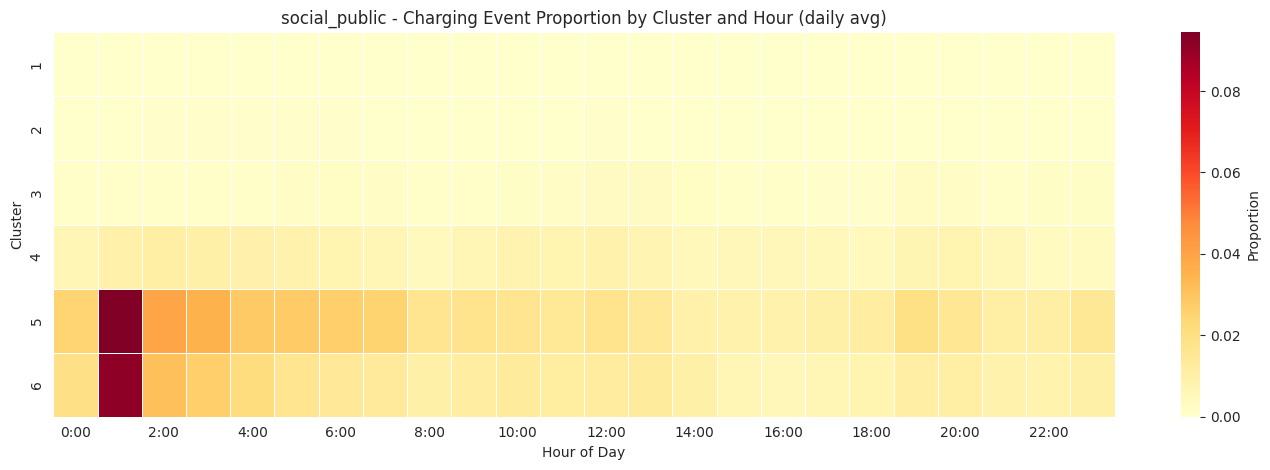


social_public proportion sum per cluster:
cluster
1    0.0020
2    0.0074
3    0.0397
4    0.1615
5    0.5177
6    0.3889
dtype: float64



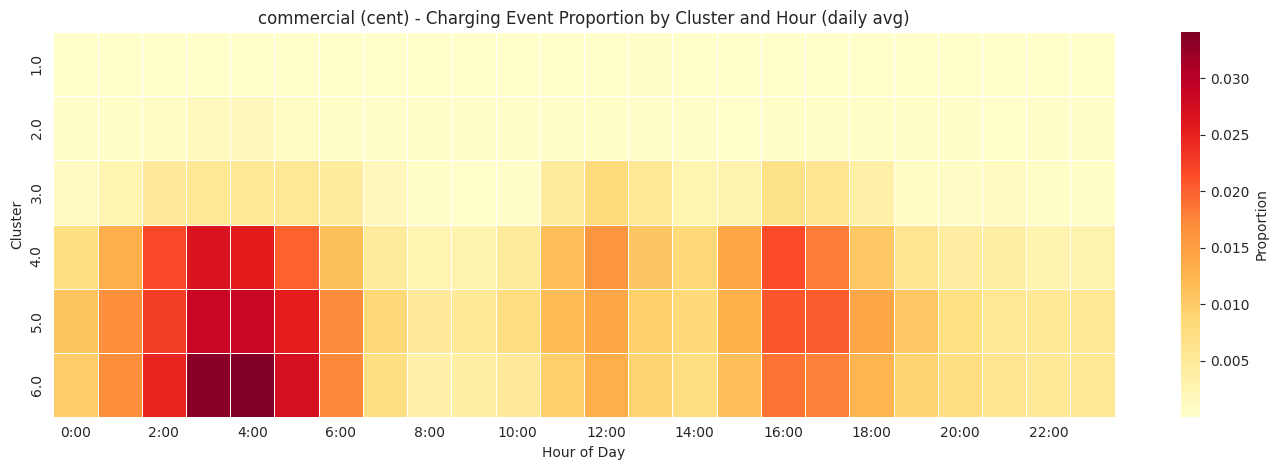


commercial (cent) proportion sum per cluster:
cluster
1.0    0.0022
2.0    0.0110
3.0    0.0770
4.0    0.2722
5.0    0.3225
6.0    0.3157
dtype: float64



In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns

matplotlib.rcParams['font.sans-serif'] = ['SimHei', 'WenQuanYi Micro Hei', 'Noto Sans CJK SC', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False

def charging_heatmap(charging_df, cluster_result, station_col_in_events='nearest_station_id', title=''):
    df = charging_df.copy()
    df['start_time'] = pd.to_datetime(df['start_time'])
    df['hour'] = df['start_time'].dt.hour
    df['date'] = df['start_time'].dt.date

    cluster_map = cluster_result.set_index('station_id')['cluster']
    df['cluster'] = df[station_col_in_events].map(cluster_map)
    df = df.dropna(subset=['cluster'])
    df['cluster'] = df['cluster'].astype(str)

    df = df[~df['cluster'].isin(['no_poi', '0', '0.0'])]
    if df.empty:
        print(f"  {title}: no data after filtering")
        return None

    daily = df.groupby(['date', 'cluster', 'hour']).size().reset_index(name='count')
    daily_total = daily.groupby('date')['count'].transform('sum')
    daily['proportion'] = daily['count'] / daily_total

    avg = daily.groupby(['cluster', 'hour'])['proportion'].mean().reset_index()
    pivot = avg.pivot(index='cluster', columns='hour', values='proportion').fillna(0)

    for h in range(24):
        if h not in pivot.columns:
            pivot[h] = 0.0
    pivot = pivot[sorted(pivot.columns)]
    pivot = pivot.loc[sorted(pivot.index, key=lambda x: float(x))]

    fig, ax = plt.subplots(figsize=(14, max(3, len(pivot) * 0.8)))
    sns.heatmap(pivot, annot=False, cmap='YlOrRd', linewidths=0.5, ax=ax,
                cbar_kws={'label': 'Proportion'})

    ax.set_xticks([h + 0.5 for h in range(0, 24, 2)])
    ax.set_xticklabels([f'{h}:00' for h in range(0, 24, 2)])
    ax.set_xlabel('Hour of Day')
    ax.set_ylabel('Cluster')
    ax.set_title(f'{title} - Charging Event Proportion by Cluster and Hour (daily avg)')
    plt.tight_layout()
    plt.show()

    print(f"\n{title} proportion sum per cluster:")
    print(pivot.sum(axis=1).round(4))
    print()

    return pivot

# ==================== social_public ====================
pivot_1 = charging_heatmap(
    dist_charging_events,
    result_1,
    station_col_in_events='nearest_station_id',
    title='social_public'
)

# ==================== commercial (cent) ====================
pivot_2 = charging_heatmap(
    cent_charging_events_merge,
    result_2,
    station_col_in_events='nearest_station_id',
    title='commercial (cent)'
)


social_public: 8 days
  Cluster 1: 9 stations, daily avg = 4.06 events/station/day
  Cluster 2: 13 stations, daily avg = 10.14 events/station/day
  Cluster 3: 46 stations, daily avg = 15.63 events/station/day
  Cluster 4: 208 stations, daily avg = 13.95 events/station/day
  Cluster 5: 583 stations, daily avg = 14.07 events/station/day
  Cluster 6: 460 stations, daily avg = 12.81 events/station/day


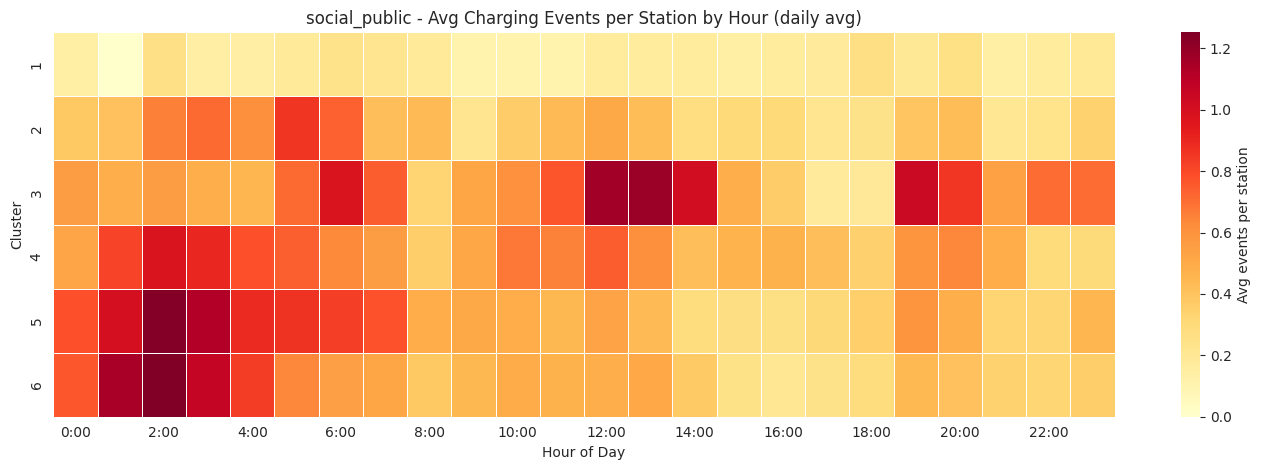


commercial (cent): 7 days
  Cluster 1: 3 stations, daily avg = 16.32 events/station/day
  Cluster 2: 11 stations, daily avg = 21.83 events/station/day
  Cluster 3: 8 stations, daily avg = 210.12 events/station/day
  Cluster 4: 92 stations, daily avg = 64.58 events/station/day
  Cluster 5: 136 stations, daily avg = 51.75 events/station/day
  Cluster 6: 265 stations, daily avg = 26.00 events/station/day


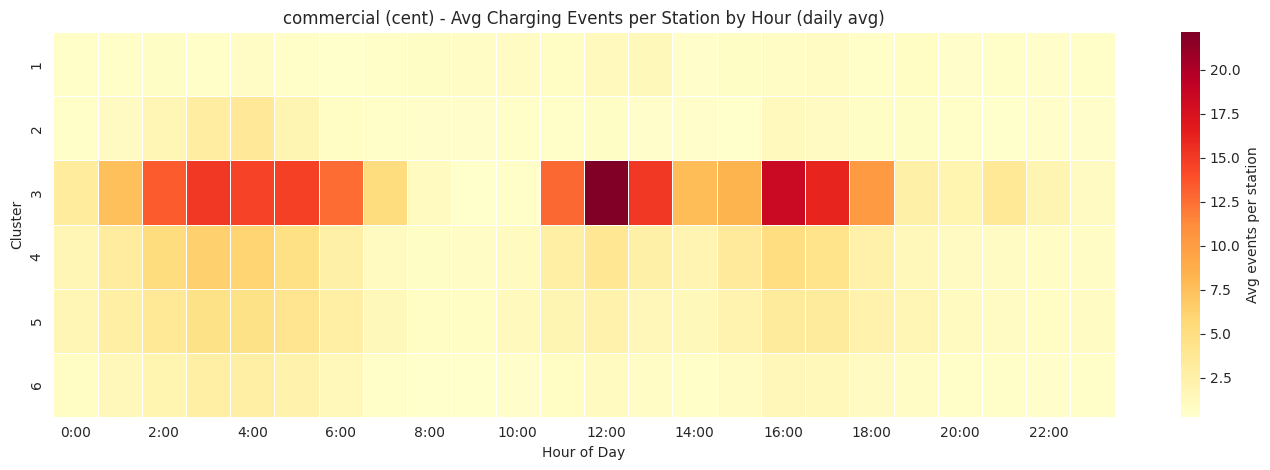

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns

matplotlib.rcParams['font.sans-serif'] = ['SimHei', 'WenQuanYi Micro Hei', 'Noto Sans CJK SC', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False

def charging_heatmap_per_station(charging_df, cluster_result,
                                  station_col_in_events='nearest_station_id', title=''):
    df = charging_df.copy()
    df['start_time'] = pd.to_datetime(df['start_time'])
    df['hour'] = df['start_time'].dt.hour
    df['date'] = df['start_time'].dt.date

    # merge 代替 map，避免类型问题
    cr = cluster_result.copy()
    cr['station_id'] = cr['station_id'].astype(float)
    cr['cluster'] = cr['cluster'].astype(int).astype(str)
    df[station_col_in_events] = df[station_col_in_events].astype(float)

    df = df.merge(cr, left_on=station_col_in_events, right_on='station_id', how='inner')
    df = df[~df['cluster'].isin(['0'])]

    if df.empty:
        print(f"  {title}: no data after filtering")
        return None

    # 每簇站数
    cr_valid = cr[~cr['cluster'].isin(['0'])]
    n_stations = cr_valid.groupby('cluster')['station_id'].nunique()

    n_days = df['date'].nunique()

    # 按 (date, cluster, hour) 计数，再除以站数
    daily = df.groupby(['date', 'cluster', 'hour']).size().reset_index(name='count')
    daily = daily.merge(n_stations.rename('n_stations'), left_on='cluster', right_index=True)
    daily['avg_per_station'] = daily['count'] / daily['n_stations']

    # 对所有天取平均
    avg = daily.groupby(['cluster', 'hour'])['avg_per_station'].mean().reset_index()
    pivot = avg.pivot(index='cluster', columns='hour', values='avg_per_station').fillna(0)

    for h in range(24):
        if h not in pivot.columns:
            pivot[h] = 0.0
    pivot = pivot[sorted(pivot.columns)]
    pivot = pivot.loc[sorted(pivot.index, key=lambda x: int(x))]

    print(f"\n{title}: {n_days} days")
    for c in pivot.index:
        print(f"  Cluster {c}: {n_stations.loc[c]} stations, "
              f"daily avg = {pivot.loc[c].sum():.2f} events/station/day")

    fig, ax = plt.subplots(figsize=(14, max(3, len(pivot) * 0.8)))
    sns.heatmap(pivot, annot=False, cmap='YlOrRd', linewidths=0.5, ax=ax,
                cbar_kws={'label': 'Avg events per station'})

    ax.set_xticks([h + 0.5 for h in range(0, 24, 2)])
    ax.set_xticklabels([f'{h}:00' for h in range(0, 24, 2)])
    ax.set_xlabel('Hour of Day')
    ax.set_ylabel('Cluster')
    ax.set_title(f'{title} - Avg Charging Events per Station by Hour (daily avg)')
    plt.tight_layout()
    plt.show()

    return pivot

# ==================== social_public ====================
pivot_1 = charging_heatmap_per_station(
    dist_charging_events,
    result_1,
    station_col_in_events='nearest_station_id',
    title='social_public'
)

# ==================== commercial (cent) ====================
pivot_2 = charging_heatmap_per_station(
    cent_charging_events_merge,
    result_2,
    station_col_in_events='nearest_station_id',
    title='commercial (cent)'
)


social_public: 8 days
  automotive_service: 13 stations, daily avg = 10.14 events/station/day
  business: 460 stations, daily avg = 12.81 events/station/day
  dailylife_service: 583 stations, daily avg = 14.07 events/station/day
  natural_land: 9 stations, daily avg = 4.06 events/station/day
  residence: 208 stations, daily avg = 13.95 events/station/day
  tourist_attraction: 46 stations, daily avg = 15.63 events/station/day


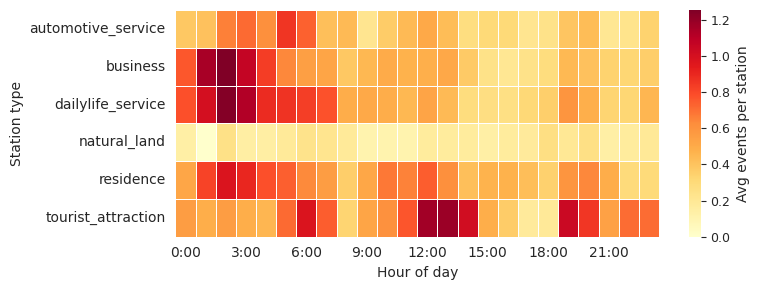


commercial (cent): 7 days
  automotive_service: 8 stations, daily avg = 210.12 events/station/day
  business: 265 stations, daily avg = 26.00 events/station/day
  dailylife_service: 136 stations, daily avg = 51.75 events/station/day
  natural_land: 3 stations, daily avg = 16.32 events/station/day
  residence: 92 stations, daily avg = 64.58 events/station/day
  tourist_attraction: 11 stations, daily avg = 21.83 events/station/day


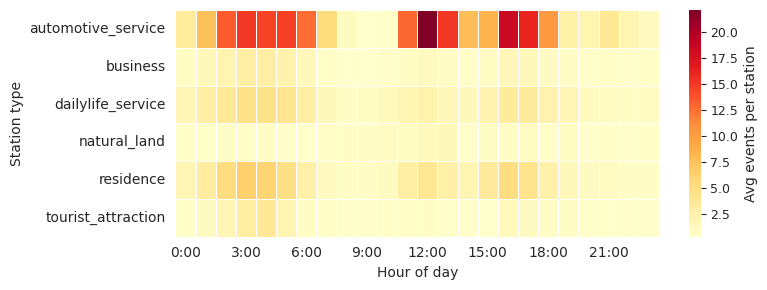

In [89]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns

matplotlib.rcParams['font.sans-serif'] = ['SimHei', 'WenQuanYi Micro Hei', 'Noto Sans CJK SC', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False

def get_cluster_names(poi_filepath, cluster_result):
    df = pd.read_csv(poi_filepath).set_index('station_id')
    poi_cols = df.columns.tolist()

    cr = cluster_result.copy()
    cr['station_id'] = cr['station_id'].astype(float)
    cr['cluster'] = cr['cluster'].astype(int).astype(str)
    cr = cr[cr['cluster'] != '0']

    df.index = df.index.astype(float)
    df = df.merge(cr.set_index('station_id'), left_index=True, right_index=True)

    cluster_names = {}
    for c in sorted(df['cluster'].unique(), key=int):
        sub = df[df['cluster'] == c][poi_cols]
        row_totals = sub.sum(axis=1)
        proportions = sub.div(row_totals, axis=0).mean()
        top_poi = proportions.idxmax()
        cluster_names[c] = top_poi

    return cluster_names

# 获取两类站的簇名
names_1 = get_cluster_names('poi_social_public_station_merged_result.csv', result_1)
names_2 = get_cluster_names('poi_cent_stat_summary_merged_result.csv', result_2)

# 统一纵轴顺序：所有类名的并集，排序
all_row_names = sorted(set(list(names_1.values()) + list(names_2.values())))


def charging_heatmap_per_station(charging_df, cluster_result, cluster_names,
                                  station_col_in_events='nearest_station_id', title=''):
    df = charging_df.copy()
    df['start_time'] = pd.to_datetime(df['start_time'])
    df['hour'] = df['start_time'].dt.hour
    df['date'] = df['start_time'].dt.date

    cr = cluster_result.copy()
    cr['station_id'] = cr['station_id'].astype(float)
    cr['cluster'] = cr['cluster'].astype(int).astype(str)
    df[station_col_in_events] = df[station_col_in_events].astype(float)

    df = df.merge(cr, left_on=station_col_in_events, right_on='station_id', how='inner')
    df = df[~df['cluster'].isin(['0'])]

    if df.empty:
        print(f"  {title}: no data after filtering")
        return None

    # 簇号 → 类名
    df['cluster_name'] = df['cluster'].map(cluster_names)

    cr_valid = cr[~cr['cluster'].isin(['0'])]
    n_stations = cr_valid.groupby('cluster')['station_id'].nunique()
    # 按类名统计站数
    n_stations_by_name = {cluster_names[c]: n for c, n in n_stations.items()}

    n_days = df['date'].nunique()

    daily = df.groupby(['date', 'cluster_name', 'hour']).size().reset_index(name='count')
    daily['n_stations'] = daily['cluster_name'].map(n_stations_by_name)
    daily['avg_per_station'] = daily['count'] / daily['n_stations']

    avg = daily.groupby(['cluster_name', 'hour'])['avg_per_station'].mean().reset_index()
    pivot = avg.pivot(index='cluster_name', columns='hour', values='avg_per_station').fillna(0)

    for h in range(24):
        if h not in pivot.columns:
            pivot[h] = 0.0
    pivot = pivot[sorted(pivot.columns)]

    # 统一行顺序
    pivot = pivot.reindex(all_row_names).fillna(0)
    # 去掉全为 0 的行（该类站中不存在的类型）
    pivot = pivot.loc[pivot.sum(axis=1) > 0]

    print(f"\n{title}: {n_days} days")
    for name in pivot.index:
        print(f"  {name}: {n_stations_by_name.get(name, 0)} stations, "
              f"daily avg = {pivot.loc[name].sum():.2f} events/station/day")

    fig, ax = plt.subplots(figsize=(8, max(0.9, len(pivot) * 0.5)))
    sns.heatmap(pivot, annot=False, cmap='YlOrRd', linewidths=0.5, ax=ax,
                cbar_kws={'label': 'Avg events per station'})

    ax.set_xticks([h + 0.5 for h in range(0, 24, 3)])
    ax.set_xticklabels([f'{h}:00' for h in range(0, 24,3)])
    ax.set_xlabel('Hour of day')
    ax.set_ylabel('Station type')
    ax.tick_params(axis='both',labelsize=10)
    cbar = ax.collections[0].colorbar
    cbar.set_label('Avg events per station', fontsize=10)
# 颜色条刻度数字大小
    cbar.ax.tick_params(labelsize=9)
    #ax.set_title(f'{title} - Avg Charging Events per Station by Hour (daily avg)')
    plt.tight_layout()
    plt.show()

    return pivot

# ==================== social_public ====================
pivot_1 = charging_heatmap_per_station(
    dist_charging_events,
    result_1,
    names_1,
    station_col_in_events='nearest_station_id',
    title='social_public'
)

# ==================== commercial (cent) ====================
pivot_2 = charging_heatmap_per_station(
    cent_charging_events_merge,
    result_2,
    names_2,
    station_col_in_events='nearest_station_id',
    title='commercial (cent)'
)

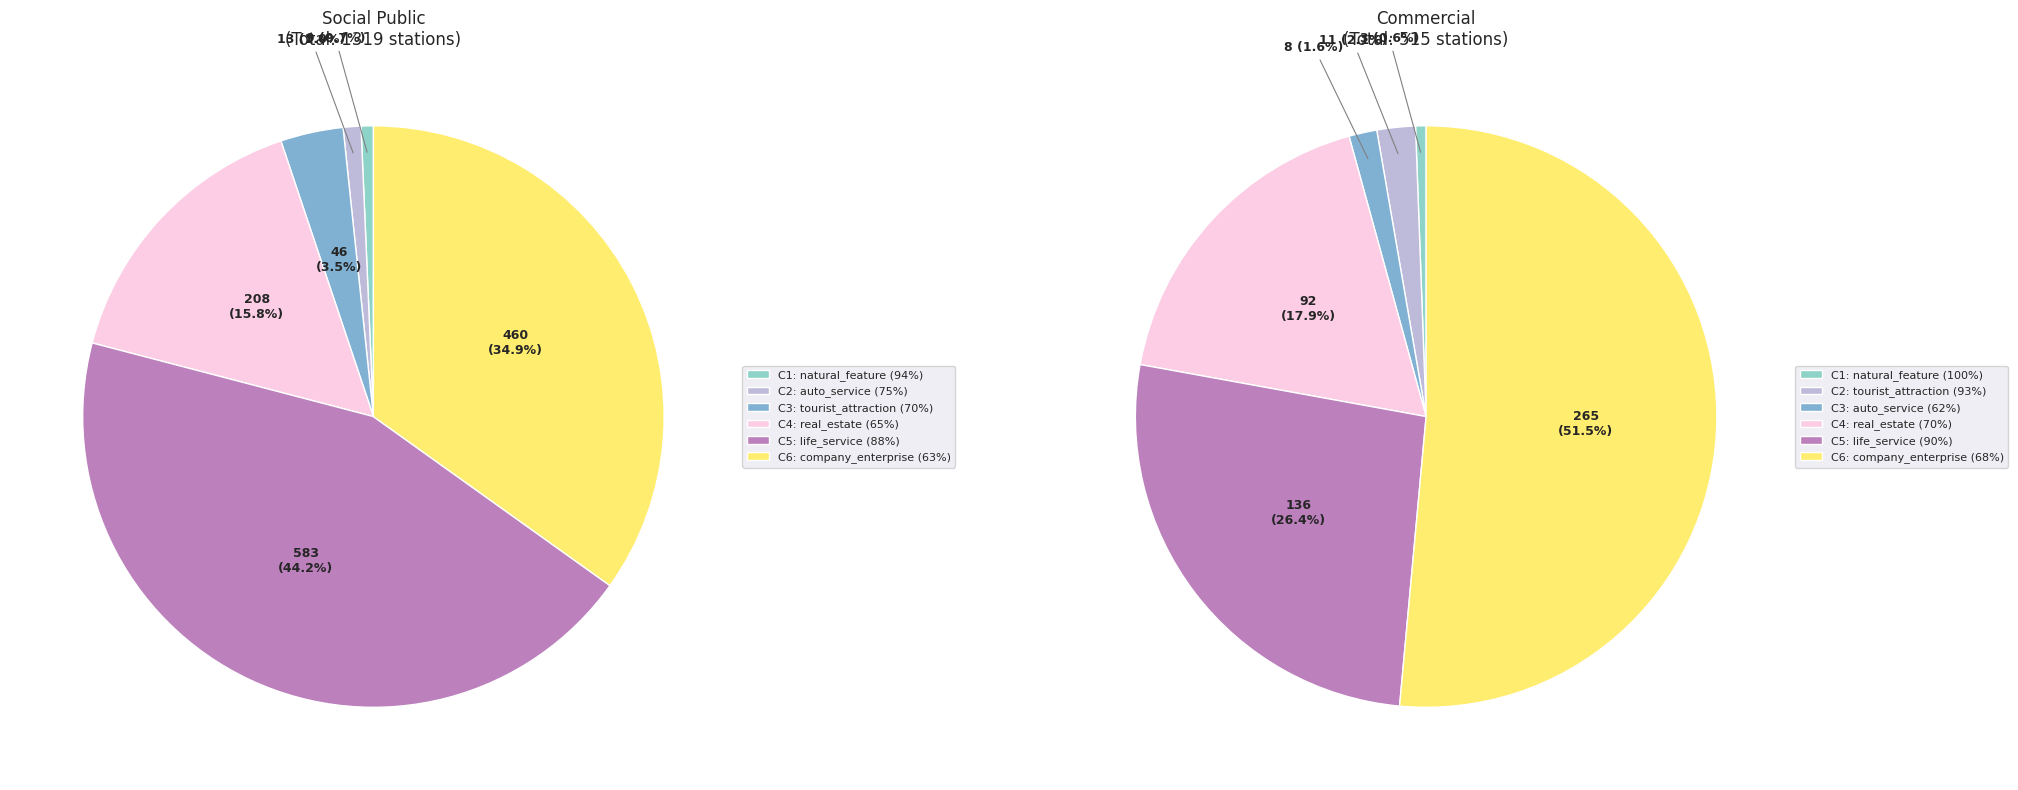


Social Public (1319 stations):
  Cluster 1 [natural_feature (94%)]: 9 stations (0.7%)
  Cluster 2 [auto_service (75%)]: 13 stations (1.0%)
  Cluster 3 [tourist_attraction (70%)]: 46 stations (3.5%)
  Cluster 4 [real_estate (65%)]: 208 stations (15.8%)
  Cluster 5 [life_service (88%)]: 583 stations (44.2%)
  Cluster 6 [company_enterprise (63%)]: 460 stations (34.9%)

Commercial (515 stations):
  Cluster 1 [natural_feature (100%)]: 3 stations (0.6%)
  Cluster 2 [tourist_attraction (93%)]: 11 stations (2.1%)
  Cluster 3 [auto_service (62%)]: 8 stations (1.6%)
  Cluster 4 [real_estate (70%)]: 92 stations (17.9%)
  Cluster 5 [life_service (90%)]: 136 stations (26.4%)
  Cluster 6 [company_enterprise (68%)]: 265 stations (51.5%)


In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['SimHei', 'WenQuanYi Micro Hei', 'Noto Sans CJK SC', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False

def get_cluster_names(poi_filepath, cluster_result):
    df = pd.read_csv(poi_filepath).set_index('station_id')
    poi_cols = df.columns.tolist()

    cr = cluster_result.copy()
    cr['station_id'] = cr['station_id'].astype(float)
    cr['cluster'] = cr['cluster'].astype(int).astype(str)
    cr = cr[cr['cluster'] != '0']

    df.index = df.index.astype(float)
    df = df.merge(cr.set_index('station_id'), left_index=True, right_index=True)

    cluster_names = {}
    for c in sorted(df['cluster'].unique(), key=int):
        sub = df[df['cluster'] == c][poi_cols]
        row_totals = sub.sum(axis=1)
        proportions = sub.div(row_totals, axis=0).mean()
        top_poi = proportions.idxmax()
        top_pct = proportions.max()
        cluster_names[c] = f"{top_poi} ({top_pct:.0%})"

    return cluster_names


def plot_composition(result, cluster_names, title, ax):
    cr = result.copy()
    cr['cluster'] = cr['cluster'].astype(int).astype(str)
    cr = cr[cr['cluster'] != '0']
    counts = cr['cluster'].value_counts()
    total = counts.sum()

    labels = []
    sizes = []
    for c in sorted(counts.index, key=int):
        name = cluster_names.get(c, f'Cluster {c}')
        labels.append(f"C{c}: {name}")
        sizes.append(counts[c])

    colors = plt.cm.Set3(np.linspace(0, 1, len(labels)))

    wedges, texts, autotexts = ax.pie(
        sizes, labels=None, autopct='', startangle=90, colors=colors,
        pctdistance=0.75)

    # 标注：小扇区用引线标在外面，大扇区标在里面
    for i, (wedge, size) in enumerate(zip(wedges, sizes)):
        pct = size / total * 100
        angle = (wedge.theta2 + wedge.theta1) / 2
        rad = np.radians(angle)

        if pct < 3:
            x = 1.3 * np.cos(rad)
            y = 1.3 * np.sin(rad)
            ha = 'left' if x > 0 else 'right'
            ax.annotate(f"{size} ({pct:.1f}%)",
                        xy=(0.9 * np.cos(rad), 0.9 * np.sin(rad)),
                        xytext=(x, y),
                        ha=ha, va='center', fontsize=9, fontweight='bold',
                        arrowprops=dict(arrowstyle='-', color='gray', lw=0.8))
        else:
            x = 0.55 * np.cos(rad)
            y = 0.55 * np.sin(rad)
            ax.annotate(f"{size}\n({pct:.1f}%)",
                        xy=(x, y), ha='center', va='center',
                        fontsize=9, fontweight='bold')

    ax.legend(wedges, labels, loc='center left', bbox_to_anchor=(1, 0.5), fontsize=8)
    ax.set_title(f'{title}\n(Total: {total} stations)', fontsize=12)


names_1 = get_cluster_names('poi_social_public_station_merged_result.csv', result_1)
names_2 = get_cluster_names('poi_cent_stat_summary_merged_result.csv', result_2)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 8))
plot_composition(result_1, names_1, 'Social Public', ax1)
plot_composition(result_2, names_2, 'Commercial', ax2)
plt.tight_layout()
plt.show()

for title, names, result in [('Social Public', names_1, result_1),
                              ('Commercial', names_2, result_2)]:
    cr = result.copy()
    cr['cluster'] = cr['cluster'].astype(int).astype(str)
    cr = cr[cr['cluster'] != '0']
    counts = cr['cluster'].value_counts().sort_index()
    total = counts.sum()
    print(f"\n{title} ({total} stations):")
    for c in sorted(counts.index, key=int):
        print(f"  Cluster {c} [{names[c]}]: {counts[c]} stations ({counts[c]/total:.1%})")

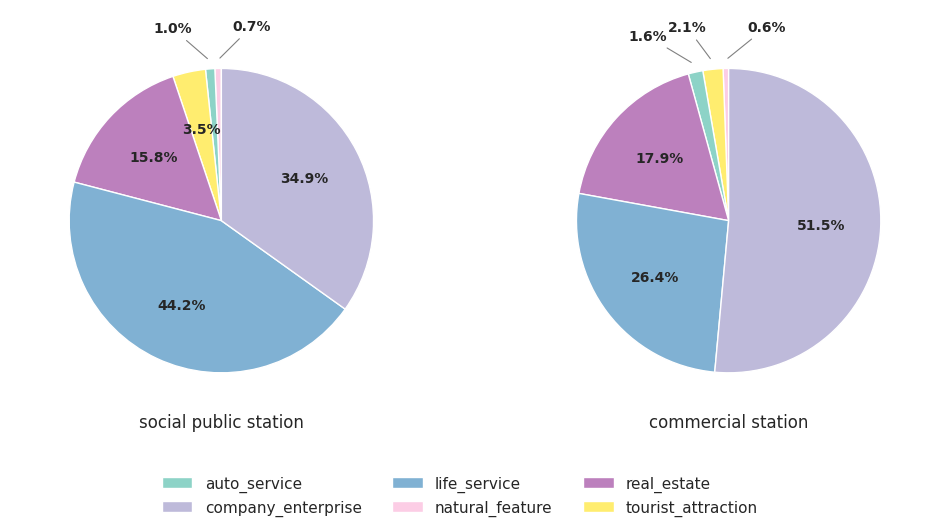


social public station (1319 stations):
  Cluster 1 [natural_feature]: 9 stations (0.7%)
  Cluster 2 [auto_service]: 13 stations (1.0%)
  Cluster 3 [tourist_attraction]: 46 stations (3.5%)
  Cluster 4 [real_estate]: 208 stations (15.8%)
  Cluster 5 [life_service]: 583 stations (44.2%)
  Cluster 6 [company_enterprise]: 460 stations (34.9%)

commercial station (515 stations):
  Cluster 1 [natural_feature]: 3 stations (0.6%)
  Cluster 2 [tourist_attraction]: 11 stations (2.1%)
  Cluster 3 [auto_service]: 8 stations (1.6%)
  Cluster 4 [real_estate]: 92 stations (17.9%)
  Cluster 5 [life_service]: 136 stations (26.4%)
  Cluster 6 [company_enterprise]: 265 stations (51.5%)


In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['SimHei', 'WenQuanYi Micro Hei', 'Noto Sans CJK SC', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False

def get_cluster_names(poi_filepath, cluster_result):
    df = pd.read_csv(poi_filepath).set_index('station_id')
    poi_cols = df.columns.tolist()

    cr = cluster_result.copy()
    cr['station_id'] = cr['station_id'].astype(float)
    cr['cluster'] = cr['cluster'].astype(int).astype(str)
    cr = cr[cr['cluster'] != '0']

    df.index = df.index.astype(float)
    df = df.merge(cr.set_index('station_id'), left_index=True, right_index=True)

    cluster_names = {}
    for c in sorted(df['cluster'].unique(), key=int):
        sub = df[df['cluster'] == c][poi_cols]
        row_totals = sub.sum(axis=1)
        proportions = sub.div(row_totals, axis=0).mean()
        top_poi = proportions.idxmax()
        cluster_names[c] = top_poi

    return cluster_names


names_1 = get_cluster_names('poi_social_public_station_merged_result.csv', result_1)
names_2 = get_cluster_names('poi_cent_stat_summary_merged_result.csv', result_2)

# 收集所有出现的类名，按名字统一分配颜色
all_names = sorted(set(list(names_1.values()) + list(names_2.values())))
cmap = plt.cm.Set3(np.linspace(0, 1, len(all_names)))
name_to_color = {name: cmap[i] for i, name in enumerate(all_names)}


def plot_pie(result, cluster_names, title, ax):
    cr = result.copy()
    cr['cluster'] = cr['cluster'].astype(int).astype(str)
    cr = cr[cr['cluster'] != '0']
    counts = cr['cluster'].value_counts()
    total = counts.sum()

    cluster_order = sorted(counts.index, key=int)
    sizes = [counts[c] for c in cluster_order]
    colors = [name_to_color[cluster_names[c]] for c in cluster_order]

    wedges, _, _ = ax.pie(
        sizes, labels=None, autopct='', startangle=90, colors=colors,radius=0.9)

    small_annotations = []
    for i, (wedge, size) in enumerate(zip(wedges, sizes)):
        pct = size / total * 100
        angle = (wedge.theta2 + wedge.theta1) / 2
        rad = np.radians(angle)
        if pct >= 3:
            x = 0.55 * np.cos(rad)
            y = 0.55 * np.sin(rad)
            ax.annotate(f"{pct:.1f}%",
                        xy=(x, y), ha='center', va='center',
                        fontsize=10, fontweight='bold')
        else:
            small_annotations.append((pct, angle, rad))
    # 小扇区统一用等间距引线标注
    if small_annotations:
        # 按角度排序
        small_annotations.sort(key=lambda x: x[1])
        n = len(small_annotations)
        # 以小扇区的平均角度为中心，上下错开
        avg_angle = np.mean([a[1] for a in small_annotations])
        spread = 12  # 错开角度
        offsets = np.linspace(-spread * (n - 1) / 2, spread * (n - 1) / 2, n)
        for idx, (pct, angle, rad) in enumerate(small_annotations):
            offset_angle = np.radians(avg_angle + offsets[idx])
            x_text = 1.15 * np.cos(offset_angle)
            y_text = 1.15 * np.sin(offset_angle)
            ha = 'left' if x_text > 0 else 'right'
            ax.annotate(f"{pct:.1f}%",
                        xy=(0.95 * np.cos(rad), 0.95 * np.sin(rad)),
                        xytext=(x_text, y_text),
                        ha=ha, va='center', fontsize=10, fontweight='bold',
                        arrowprops=dict(arrowstyle='-', color='gray', lw=0.8))


    ax.set_title(title, fontsize=12,y=-0.008)
    return wedges, [cluster_names[c] for c in cluster_order]


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
w1, _ = plot_pie(result_1, names_1, 'social public station', ax1)
w2, _ = plot_pie(result_2, names_2, 'commercial station', ax2)

# 统一图例：按类名
from matplotlib.patches import Patch
legend_handles = [Patch(facecolor=name_to_color[n], label=n) for n in all_names]
fig.legend(handles=legend_handles, loc='lower center',
           ncol=min(3, len(all_names)), fontsize=11, frameon=False,
           bbox_to_anchor=(0.5, -0.02))
#plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()

for title, names, result in [('social public station', names_1, result_1),
                              ('commercial station', names_2, result_2)]:
    cr = result.copy()
    cr['cluster'] = cr['cluster'].astype(int).astype(str)
    cr = cr[cr['cluster'] != '0']
    counts = cr['cluster'].value_counts().sort_index()
    total = counts.sum()
    print(f"\n{title} ({total} stations):")
    for c in sorted(counts.index, key=int):
        print(f"  Cluster {c} [{names[c]}]: {counts[c]} stations ({counts[c]/total:.1%})")

/home/lxhep/miniconda3/envs/rapids-env/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


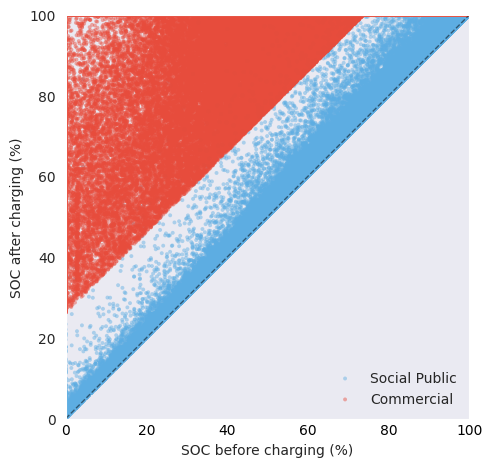

In [79]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['SimHei', 'WenQuanYi Micro Hei', 'Noto Sans CJK SC', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False

bt = battery_trace_output[battery_trace_output['charge_type'].isin(['distributed', 'centralized'])].copy()

fig, ax = plt.subplots(figsize=(5, 5))

for ctype, color, label in [('distributed', '#5DADE2', 'Social Public'),
                              ('centralized', '#E74C3C', 'Commercial')]:
    sub = bt[bt['charge_type'] == ctype]
    ax.scatter(sub['SOC_before_pct'], sub['SOC_after_pct'],
               c=color, alpha=0.45, s=8, label=label, edgecolors='none')

ax.plot([0, 100], [0, 100], 'k--', lw=1, alpha=0.5)
ax.set_xlim(0, 100)
ax.set_ylim(0, 100)
ax.set_xlabel('SOC before charging (%)')
ax.set_ylabel('SOC after charging (%)')
ax.tick_params(axis='x', which='major', direction='in', length=3, width=0.5, colors='black', left=True)
#ax.set_title('SOC Before vs After Charging')
ax.legend(frameon=False)
ax.grid(False)
ax.set_aspect('equal')
plt.tight_layout()
plt.show()